#### NLP Embeddings Clustering

##### Context

You are tasked with analyzing two datasets:

1. BBC News dataset: Contains text data grouped into 5 categories: Business, Entertainment, Politics, Sport, and Tech.
2. 20NewsGroups dataset: Contains text data grouped into 20 topics.

The goal is to transform the data into word embeddings, apply clustering techniques, and evaluate the results. Improve the results by using PCA for dimensionality reduction.

##### Problem Statement

Cluster the articles in both datasets using the following methods:

1. Feature extraction: Use TF-IDF, FastText, and Word2Vec to create embeddings.
2. Clustering algorithms: Implement K-Means, HDBSCAN, and Agglomerative Clustering.
3. Evaluation metrics: Evaluate the clustering results using NMI (Normalized Mutual Information), ARI (Adjusted Rand Index), AMI (Adjusted Mutual Information), and the Silhouette Score or Elbow Method.

##### Loading Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import emoji
import nltk
import spacy
import string
from nltk.corpus import stopwords
from collections import Counter
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.lda_model
from pyLDAvis import prepare

from gensim.models import Word2Vec 
from sklearn.feature_extraction.text import TfidfVectorizer 
from gensim.models import FastText 

import hdbscan
from hdbscan import HDBSCAN
from sklearn.metrics.pairwise import cosine_distances
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.cluster import AgglomerativeClustering #Agglomerative
from scipy.cluster.hierarchy import linkage, dendrogram #Agglomerative
from scipy.cluster.hierarchy import fcluster #Agglomerative
from collections import Counter #Agglomerative_points_to_clusters
from sklearn.metrics import silhouette_score
from scipy.sparse import issparse

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA,TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split 
from sklearn.datasets import make_blobs 
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score

###### Expanding column width to see the full sentences in dataframes

In [2]:
pd.set_option('display.max_colwidth', None)

###### Muting Pandas Slice Warnings

In [3]:
pd.options.mode.chained_assignment = None

***

#### Loading Datasets

###### Loading 20newsgroups dataset

In [4]:
#Loading good 10% of 20newsgroups
data_20newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
documents_20newsgroups = data_20newsgroups.data
labels_20newsgroups = data_20newsgroups.target
labels_names_20newsgroups = data_20newsgroups.target_names
news_dict = {
    'label': labels_20newsgroups,
    'comment': documents_20newsgroups,
}
news_df = pd.DataFrame(news_dict)
news_df['label_name'] = news_df['label'].apply(lambda x: labels_names_20newsgroups[x])

_, x_test_news, _, y_test_news = train_test_split(
    news_df,
    news_df['label'],
    test_size=0.1,
    random_state=42,
    stratify=news_df['label']
)

#Using the x_test_news
full_df_20newsgroups = x_test_news.copy()
#----------------------------------------------------------------------------

#Renaming columns for clarity of Column names
columns_mapping = {'label':'ground_truth_label','comment': 'sentence','label_name':'category'}
#Applying the renaming of Columns
full_df_20newsgroups = full_df_20newsgroups.rename(columns=columns_mapping)

#Cleaning Columns names (strip whitespace) & creating a relevant Columns list
full_df_20newsgroups.columns = full_df_20newsgroups.columns.str.strip()
full_df_20newsgroups_columns = list(full_df_20newsgroups.columns)
print("Cleaning Columns of 20newsgroups DataFrame & putting them in full_df_20newsgroups_columns list")
print(full_df_20newsgroups_columns)
print('\n')

#display(full_df_20newsgroups.head())

Cleaning Columns of 20newsgroups DataFrame & putting them in full_df_20newsgroups_columns list
['ground_truth_label', 'sentence', 'category']




###### Loading bbcnews dataset

In [5]:
#Loading all the bbc news dataset from relevant csv file
df_bbcnews_org = pd.read_csv("../data/bbc_news_test.csv")
#display(df_bbcnews.head())

full_df_bbcnews = df_bbcnews_org.copy()

#----------------------------------------------------------------------------

#Renaming columns for clarity of Column names
columns_mapping = {'ArticleId':'id', 'Text':'sentence','Category':'category'}

#Applying the renaming of Columns
full_df_bbcnews = full_df_bbcnews.rename(columns=columns_mapping)

#Cleaning Columns names (strip whitespace) & creating a relevant Columns list
full_df_bbcnews.columns = full_df_bbcnews.columns.str.strip()
full_df_bbcnews_columns = list(full_df_bbcnews.columns)
print("Cleaning Columns of bbc_news DataFrame & putting them in full_df_bbcnews_columns list")
print(full_df_bbcnews_columns)

#display(full_df_bbcnews.head())

Cleaning Columns of bbc_news DataFrame & putting them in full_df_bbcnews_columns list
['id', 'sentence', 'category']


***

#### Cleaning & EDA for Datasets

##### Cleaning & EDA for 20newsgroups dataframe

##### Selecting values from desired column "sentence" for text EDA of 20newsgroups

In [6]:
df_sentence_20newsgroups = full_df_20newsgroups[["sentence"]].copy()
df_sentence_20newsgroups["sentence"] = df_sentence_20newsgroups["sentence"].astype(str)
#display(full_df_20newsgroups.head())

#Creating the corpus for corpus_20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence"]

##### Visualizing Sentence Count for 20newsgroups

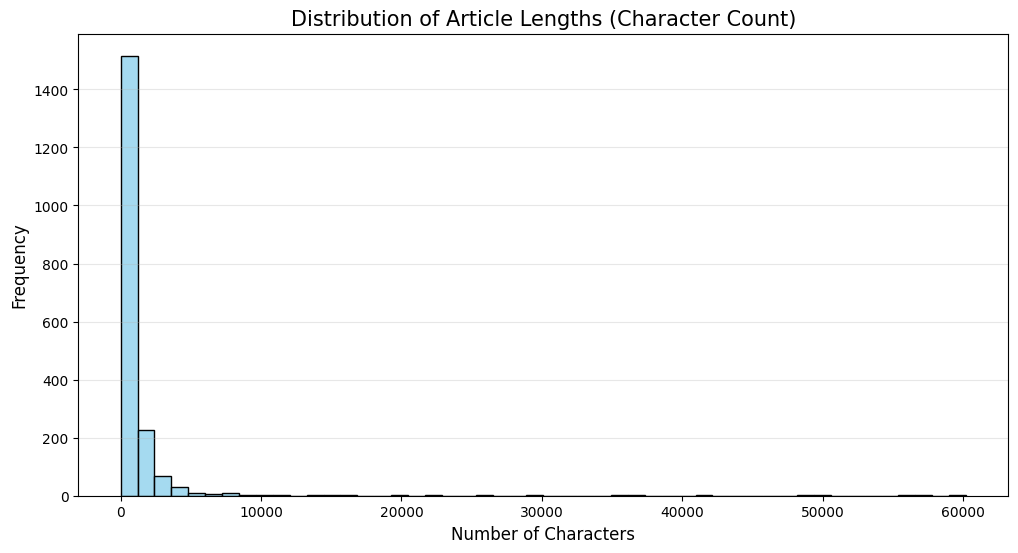

In [7]:
#Checking the number of characters present in each sentence to have a rough idea about the text headline length
#Calculating sentence lengths
df_sentence_20newsgroups["char_count"] = df_sentence_20newsgroups["sentence"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_sentence_20newsgroups["char_count"], bins=50, color="skyblue")
plt.title("Distribution of Article Lengths (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

##### Visualizing Word Count for 20newsgroups

Mean Word Count: 183.00
Median Word Count: 82.00


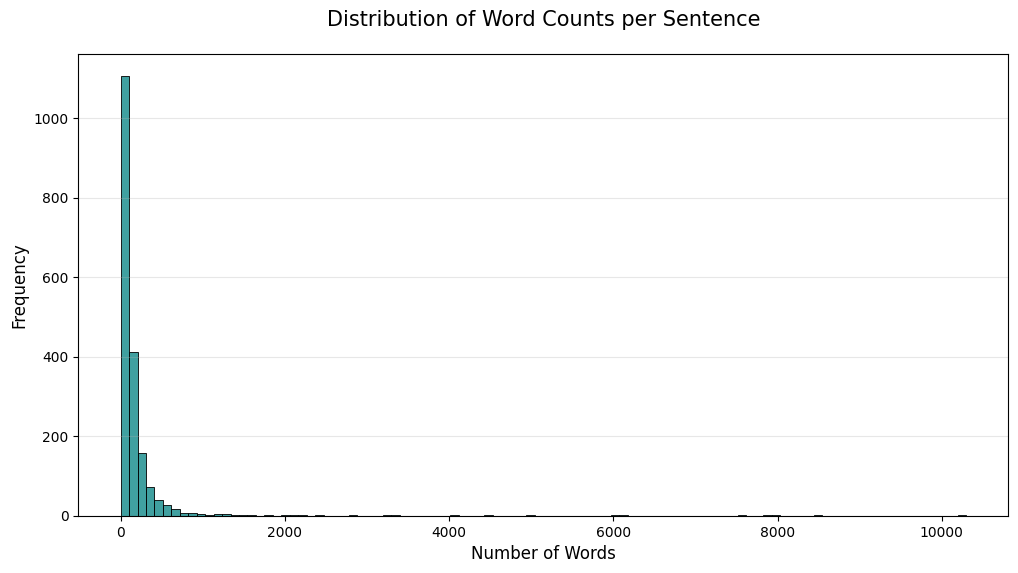

In [8]:
#Calculating word counts by splitting strings into lists
df_sentence_20newsgroups["word_count"] = df_sentence_20newsgroups["sentence"].str.split().str.len()

#Calculating key statistics
mean_words = df_sentence_20newsgroups["word_count"].mean().round()
median_words = df_sentence_20newsgroups["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_sentence_20newsgroups["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per Sentence", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Visualizing average word length in each Sentence for 20newsgroups

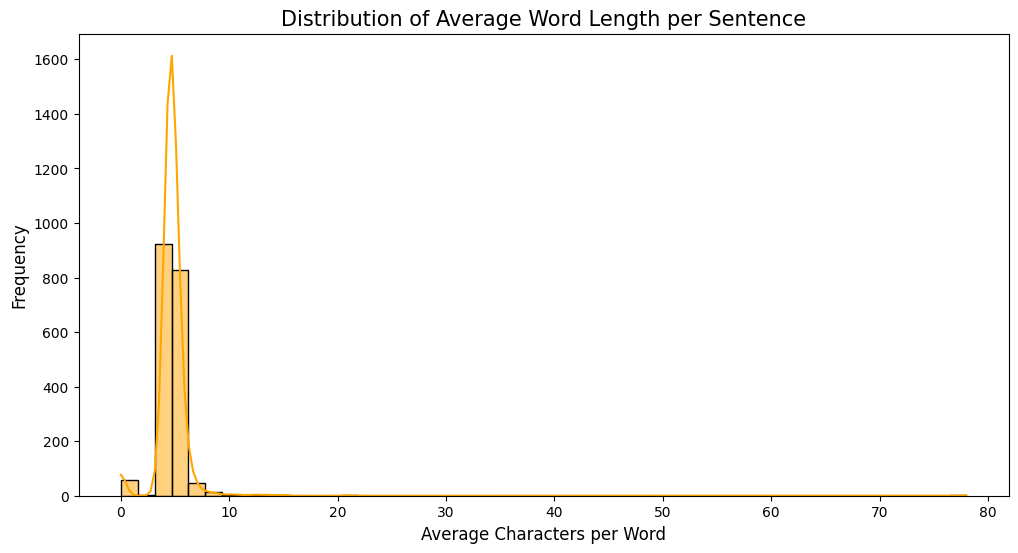

In [9]:
def get_avg_word_len(text):
    """Function to calculating average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df_sentence_20newsgroups['avg_word_len'] = df_sentence_20newsgroups['sentence'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_sentence_20newsgroups['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per Sentence", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

##### Ngram exploration for 20newsgroups

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

#Initializing the raw corpus
corpus = df_sentence_20newsgroups["sentence"]

#Extracting the top 10 for different n-gram ranges
top_unigrams = get_top_ngram(corpus, n=1)
top_bigrams = get_top_ngram(corpus, n=2)
top_trigrams = get_top_ngram(corpus, n=3)

print("Top 10 Unigrams (Raw):", top_unigrams)
print("Top 10 Bigrams (Raw):", top_bigrams)
print("Top 10 Trigrams (Raw):", top_trigrams)

Top 10 Unigrams (Raw): [('the', np.int64(17853)), ('to', np.int64(9048)), ('of', np.int64(7849)), ('and', np.int64(7177)), ('in', np.int64(5429)), ('is', np.int64(4716)), ('that', np.int64(4325)), ('it', np.int64(3873)), ('for', np.int64(3242)), ('you', np.int64(2938))]
Top 10 Bigrams (Raw): [('of the', np.int64(1898)), ('in the', np.int64(1431)), ('to the', np.int64(832)), ('on the', np.int64(713)), ('to be', np.int64(555)), ('for the', np.int64(516)), ('it is', np.int64(494)), ('and the', np.int64(483)), ('if you', np.int64(461)), ('that the', np.int64(424))]
Top 10 Trigrams (Raw): [('one of the', np.int64(104)), ('there is no', np.int64(80)), ('be able to', np.int64(75)), ('part of the', np.int64(64)), ('in order to', np.int64(60)), ('out of the', np.int64(57)), ('it would be', np.int64(55)), ('would like to', np.int64(54)), ('as well as', np.int64(53)), ('some of the', np.int64(53))]


##### Visualizing Top 10 Unigrams (Raw) for 20newsgroups

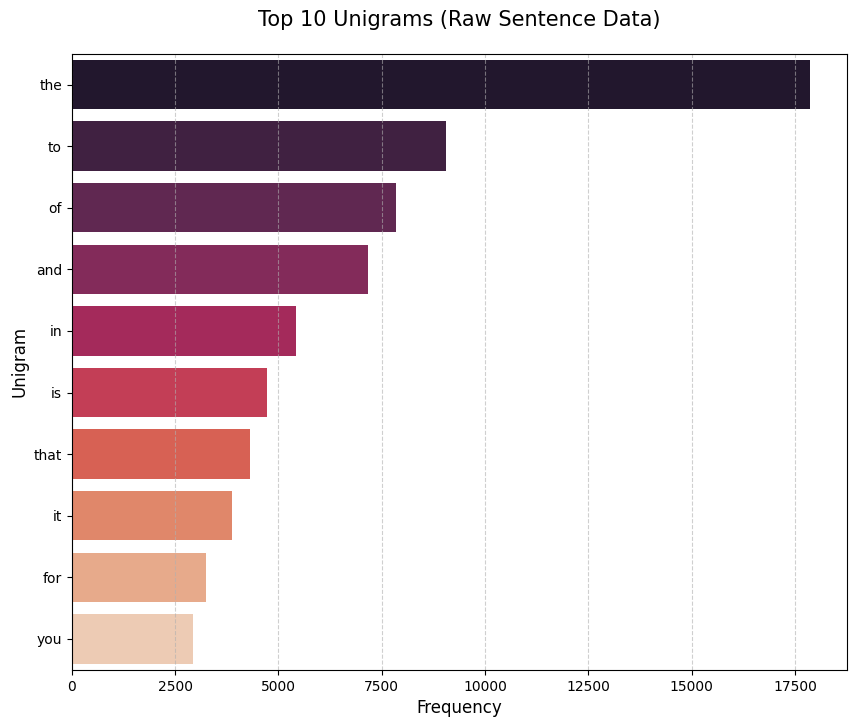

In [11]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_unigrams)

#Visualizing Top 10 Bigrams (Raw) for 20newsgroups
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Unigrams (Raw Sentence Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Unigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### Visualizing Top 10 Bigrams (Raw) for 20newsgroups

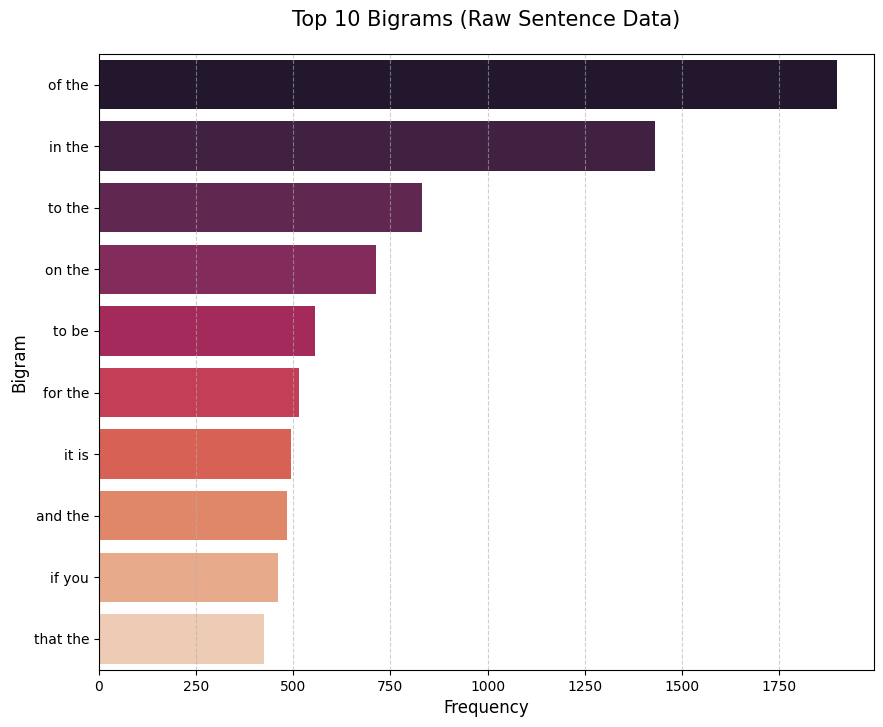

In [12]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_bigrams)

#Visualizing Top 10 Bigrams (Raw) for 20newsgroups
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Bigrams (Raw Sentence Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Bigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### Visualizing Top 10 Trigrams (Raw) for 20newsgroups

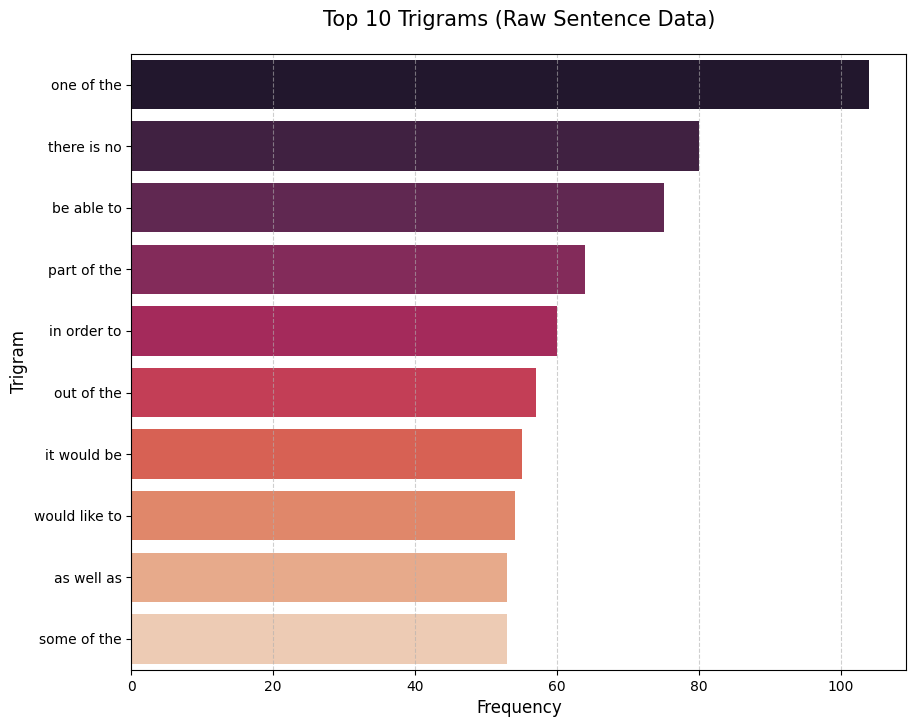

In [13]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_trigrams)

#Visualizing Top 10 Bigrams (Raw) for 20newsgroups
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Trigrams (Raw Sentence Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Trigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### Topic modeling exploration (Raw) for 20newsgroups

In [14]:
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model
from pyLDAvis import prepare

#Vectorizing the raw corpus
raw_corpus = df_sentence_20newsgroups["sentence"]
tf_vectorizer = CountVectorizer(stop_words=None)
tf = tf_vectorizer.fit_transform(raw_corpus)

#Initializing and fitting LDA
#Chose initial n_components=20 to have 20 broad topics,as ground truth is 20 categories 
lda_model = LatentDirichletAllocation(n_components=20, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Displaying the dashboard
pyLDAvis.display(panel)

##### Removal of HTML Tags like <'p> or <br'> & translating them into text in 20newsgroups raw text rows

In [15]:
from bs4 import BeautifulSoup

def remove_html_tags(text):
    """
    Removes HTML tags using BeautifulSoup. 
    If no tags are present, it returns the original text intact.
    """
    #check to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Parsing the text and extracting only the string content
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ", strip=True)

df_sentence_20newsgroups["sentence_no_html"] = df_sentence_20newsgroups["sentence"].apply(remove_html_tags)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_no_html"]

##### Removal of urls in 20newsgroups clean from htlml tags text rows

In [16]:
import re

def remove_urls(text):
    """
    Removes URLs from the text using regular expressions.
    If no URLs are present, it returns the original previous text intact.
    """
    #Checking to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Regex pattern to match http, https, and www URLs
    url_pattern = re.compile(r'http[s]?://\S+|www\.\S+')
    
    #Replacing the matched URLs with an empty string
    return url_pattern.sub(r'', text)

#Applying the URL removal to the text that just had HTML removed
df_sentence_20newsgroups["sentence_no_url"] = df_sentence_20newsgroups["sentence_no_html"].apply(remove_urls)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_no_url"]

##### Removal of Emoticons like :-) & translating them into text in 20newsgroups clean text rows

In [17]:
import re

#Creating a dictionary of common emoticons and their text translations
EMOTICON_DICT = {
    r':-\)': ' happy ', r':\)': ' happy ', r':-\]': ' happy ', r':\]': ' happy ',
    r':-\(': ' sad ', r':\(': ' sad ', r':-\[': ' sad ', r':\[': ' sad ',
    r':-D': ' laugh ', r':D': ' laugh ', r'XD': ' laugh ',
    r';-\)': ' wink ', r';\)': ' wink ',
    r':-P': ' playful ', r':P': ' playful '
}

def translate_emoticons(text):
    """Translates ASCII emoticons to words BEFORE punctuation is removed"""
    text = str(text)
    for emoticon, word in EMOTICON_DICT.items():
        text = re.sub(re.escape(emoticon), word, text, flags=re.IGNORECASE)
    return text

#Apply this to the raw text :
df_sentence_20newsgroups["after_emoticons_translation_sentence"] = df_sentence_20newsgroups["sentence_no_url"].apply(translate_emoticons)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["after_emoticons_translation_sentence"]

##### Removal of Emojis like 😀 & translating them into text in 20newsgroups clean text rows

In [18]:
import emoji

def translate_emoji_to_words(text):
    """Translates emojis into text aliases (e.g., 👍 becomes 'thumbs up')"""
    translated_text = emoji.demojize(str(text), delimiters=(" ", " "))
    
    #Replacing underscores with spaces so 'thumbs_up' for example becomes 'thumbs up'
    translated_text = translated_text.replace("_", " ")
    
    return translated_text

#Applying it to the latest cleaned text column
df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"] = df_sentence_20newsgroups["after_emoticons_translation_sentence"].apply(translate_emoji_to_words)

#Cleaning up any extra whitespace left behind
df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"] = df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"].str.replace(r'\s+', ' ', regex=True).str.strip()

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"]

# df_sentence_20newsgroups.head()

##### Removal of Punctuations & implementing lower casing in column "sentence" of 20newsgroups

- The string.punctuation in python contains the following punctuation symbols: !"#$%&\'()*+,-./:;<=>?@[\\]^_{|}~
- If needed we can add or remove more punctuations as per our need later.

In [19]:
PUNCT_TO_REMOVE = string.punctuation

def remove_punctuation_and_lower(text):
    """Custom function to remove punctuation and lowercase text"""
    return text.lower().translate(str.maketrans('', '', PUNCT_TO_REMOVE))

#Applying the function
df_sentence_20newsgroups["sentence_wo_punct_lower"] = df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"].apply(remove_punctuation_and_lower)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_wo_punct_lower"]

#display(df_sentence_20newsgroups.head())

##### Removal of stopwords in column "sentence_wo_punct_lower" of cleaned text of 20newsgroups

In [20]:
CHAT_WORDS_DICT = {
    "a3": "anytime anywhere anyplace", "adih": "another day in hell", "afk": "away from keyboard",
    "afaik": "as far as i know", "asap": "as soon as possible", "asl": "age sex location",
    "atk": "at the keyboard", "atm": "at the moment", "aka": "also known as", "approx": "approximately",
    "bae": "before anyone else", "bak": "back at keyboard", "bbl": "be back later", "bbs": "be back soon",
    "bfn": "bye for now", "b4n": "bye for now", "brb": "be right back", "bruh": "bro", 
    "brt": "be right there", "bsaaw": "big smile and a wink", "btw": "by the way", "b/c": "because",
    "bwl": "bursting with laughter", "csl": "can not stop laughing", "cu": "see you", 
    "cul8r": "see you later", "cya": "see you", "dm": "direct message", "eta": "estimated time of arrival",
    "eod": "end of day", "eow": "end of week", "faq": "frequently asked questions", 
    "fc": "fingers crossed", "fimh": "forever in my heart", "fomo": "fear of missing out", 
    "fr": "for real", "fwiw": "for what its worth", "fyp": "for you page", "fyi": "for your information", 
    "g9": "genius", "gal": "get a life", "gg": "good game", "gmta": "great minds think alike",
    "gn": "good night", "goat": "greatest of all time", "gr8": "great", "hbd": "happy birthday", 
    "hbu": "how about you", "ic": "i see", "icq": "i seek you", "idc": "i do not care",
    "idk": "i do not know", "iirc": "if i recall correctly", "ifyp": "i feel your pain", 
    "ilu": "i love you", "ily": "i love you", "imho": "in my humble opinion", "imu": "i miss you",
    "imo": "in my opinion", "iow": "in other words", "irl": "in real life",
    "iykyk": "if you know you know", "jk": "just kidding", "k": "okay", "kiss": "keep it simple stupid",
    "l": "loss", "l8r": "later", "ldr": "long distance relationship", "lmk": "let me know",
    "lmao": "laughing my ass off", "lol": "laughing out loud", "ltns": "long time no see",
    "m8": "mate", "mfw": "my face when", "mid": "mediocre", "mrw": "my reaction when",
    "mte": "my thoughts exactly", "n": "and", "nvm": "never mind", "nrn": "no reply necessary",
    "npc": "non player character", "oic": "oh i see", "op": "overpowered", "ootl": "out of the loop",
    "pita": "pain in the ass", "pov": "point of view", "prt": "party", "pls": "please", "plz": "please",
    "prw": "parents are watching", "r": "are", "rofl": "rolling on the floor laughing",
    "roflol": "rolling on the floor laughing out loud", 
    "rotflmao": "rolling on the floor laughing my ass off", "rn": "right now", 
    "sk8": "skate", "stats": "your sex and age", "sus": "suspicious", "tbh": "to be honest", 
    "tba": "to be announced", "tbd": "to be determined", "tbf": "to be fair",
    "tfw": "that feeling when", "thx": "thank you", 
    "tldr": "too long did not read", "tntl": "trying not to laugh", "ttfn": "ta ta for now", 
    "ttyl": "talk to you later", "u": "you", "u2": "you too", "u4e": "yours for ever", 
    "w": "win", "w8": "wait", "wb": "welcome back", "wbu": "what about you", "wtf": "what the fuck", 
    "wtg": "way to go", "wuf": "where are you from", "wyd": "what you doing", "w/": "with", 
    "w/o": "without", "wywh": "wish you were here", "y": "why", "zzz": "sleeping bored tired"
}

In [21]:
def chat_words_conversion(text):
    """
    Expands common abbreviations into full words.
    Checks each word against the dictionary.
    """
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    return " ".join([CHAT_WORDS_DICT.get(word, word) for word in text.split()])

df_sentence_20newsgroups["sentence_chat_wo_punct_lower"] = df_sentence_20newsgroups["sentence_wo_punct_lower"].apply(chat_words_conversion)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_chat_wo_punct_lower"]

##### Visualizing Top 15 Most Frequent Stopwords 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\roxan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


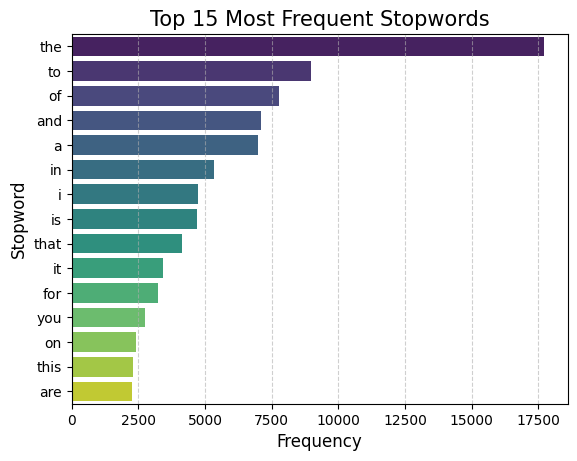

In [22]:
from nltk.corpus import stopwords
nltk.download('stopwords') #downloading list of English words
from collections import Counter

STOPWORDS = set(stopwords.words('english'))
manual_fixes = [word.replace("'", "") for word in STOPWORDS if "'" in word]
STOPWORDS.update(manual_fixes)

#Identifying which text column to analyze 
text_data = corpus_20newsgroups

#Extracting and count stopwords only
stopword_list = []
for text in text_data:
    words = str(text).split()
    stopword_list.extend([word for word in words if word in STOPWORDS])

#Getting the Top 15
stopword_counts = Counter(stopword_list).most_common(15)
words, counts = zip(*stopword_counts)

#Visualizing Top 15 Most Frequent Stopwords 
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)

plt.title("Top 15 Most Frequent Stopwords", fontsize=15)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Stopword", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

##### Removal of stopwords in column "sentence_wo_punct_lower" of 20newsgroups

In [23]:
def remove_stopwords(text):
    """custom function to remove the stopwords"""
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"] = df_sentence_20newsgroups["sentence_chat_wo_punct_lower"].apply(remove_stopwords)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"]

#display(df_sentence_20newsgroups.head())

##### Dropping not needed columns 

In [24]:
#Dropping the two previously created columns that are no longer needed 
df_sentence_20newsgroups.drop(["char_count","word_count","sentence_no_html","sentence_no_url","after_emoticons_translation_sentence","after_emojis_emoticons_translation_sentence","sentence_chat_wo_punct_lower"], axis=1, inplace=True)

##### Removal of Frequent words of 20newsgroups cleaned text rows

In [25]:
from collections import Counter
cnt = Counter()
for text in df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"].values:
    for word in text.split():
        cnt[word] += 1
        
print(cnt.most_common(10))

#print(' ')
#print('Alternative way to find the top_10_words using pandas:')
#top_10_words = df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"].str.split().explode().value_counts().head(10)
#print(top_10_words)

[('x', 1721), ('one', 1007), ('would', 974), ('get', 637), ('like', 617), ('people', 612), ('use', 567), ('also', 567), ('know', 531), ('time', 510)]


In [26]:
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
def remove_freqwords(text):
    """custom function to remove the frequent words"""
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

df_sentence_20newsgroups["sentence_wo_freq_stopwords_punct_lower"] = df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"].apply(lambda text: remove_freqwords(text))

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_wo_freq_stopwords_punct_lower"]

#display(df_sentence_20newsgroups.head())

##### Dropping not needed columns 

In [27]:
#Dropping the two previously created columns that are no longer needed 
df_sentence_20newsgroups.drop(["sentence_wo_punct_lower", "sentence_wo_stopwords_punct_lower"], axis=1, inplace=True)

##### Removal of Rare words of 20newsgroups cleaned text rows

In [28]:
#Defining the min_freq_threshold for removal of words appearing fewer than X times
min_freq_threshold = 2

#Identifying all words that don't meet the threshold
RAREWORDS = set([word for word, count in cnt.items() if count < min_freq_threshold])
print(f"Number of unique rare words to remove: {len(RAREWORDS)}")
print(f"Sample of words appearing only once (to be removed):")
for word in list(RAREWORDS)[:20]:
    print(f"{word}: {cnt[word]}")

#Defining the cleaning function
def remove_rarewords(text):
    """Removes words that appear fewer than the threshold frequency"""
    if pd.isna(text) or not isinstance(text, str):
        return text
    return " ".join([word for word in text.split() if word not in RAREWORDS])

df_sentence_20newsgroups["sentence_wo_rare_freq_stopwords_punct_lower"] = df_sentence_20newsgroups["sentence_wo_freq_stopwords_punct_lower"].apply(remove_rarewords)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_wo_rare_freq_stopwords_punct_lower"]

#display(df_sentence_20newsgroups.head())

Number of unique rare words to remove: 16185
Sample of words appearing only once (to be removed):
trademarked: 1
1281261642: 1
inputoutput: 1
validlooking: 1
fueling: 1
conceive: 1
resistorit: 1
8183547170: 1
ventura: 1
halfawake: 1
bitblits: 1
documentaries: 1
toggles: 1
han: 1
coustomers: 1
gerrard: 1
18003881896: 1
flicker: 1
tcl93csberkeleyedu: 1
volkoff: 1


##### Lemmatization in 20newsgroups cleaned text rows

In [29]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
#Downloading the required WordNet data
nltk.download('wordnet', quiet=True) 
nltk.download('omw-1.4', quiet=True) 
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """Custom function to lemmatize text """
    return " ".join([lemmatizer.lemmatize(word) for word in str(text).split()])

#Applying function to the fully cleaned column and creating a new column with lematized cleaned text data
df_sentence_20newsgroups["lemmatized_cleaned_sentence"] = df_sentence_20newsgroups["sentence_wo_rare_freq_stopwords_punct_lower"].apply(lemmatize_text)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["lemmatized_cleaned_sentence"]

#display(df_sentence_20newsgroups[["sentence_wo_rare_freq_stopwords_punct_lower", "lemmatized_cleaned_sentence"]].head())

##### Developping lemmatization of text in 20newsgroups cleaned text rows by using POS tagging

In [30]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

#Downloading the required wordnet data & POS tagger model
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

#Mapping nltk POS tags to WordNet POS tags
wordnet_map = {"N": wordnet.NOUN, "V": wordnet.VERB, "J": wordnet.ADJ, "R": wordnet.ADV}

def lemmatize_words(text):
    """Custom function to develop lemmatization of text by using POS tagging"""
    pos_tagged_text = nltk.pos_tag(str(text).split())
    return " ".join([lemmatizer.lemmatize(word, wordnet_map.get(pos[0], wordnet.NOUN)) for word, pos in pos_tagged_text])

df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"] = df_sentence_20newsgroups["sentence_wo_rare_freq_stopwords_punct_lower"].apply(lambda text: lemmatize_words(text))

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"]

#Display the before and after the POS tagging in lematization
#display(df_sentence_20newsgroups[["sentence_wo_rare_freq_stopwords_punct_lower", "final_lemmatized_cleaned_sentence"]].head())

#Checking all columns in df_sentence_20newsgroups
#df_sentence_20newsgroups

#Dropping not needed any more columns in df_sentence_20newsgroups
df_sentence_20newsgroups.drop(["sentence_wo_freq_stopwords_punct_lower", "sentence_wo_rare_freq_stopwords_punct_lower","lemmatized_cleaned_sentence"], axis=1, inplace=True)

#Checking updated columns in df_sentence_20newsgroups
#df_sentence_20newsgroups

##### Checking Nulls of final cleaned column "final_lemmatized_cleaned_sentence" of 20newsgroups & dropping cleaned text null rows

In [31]:
#Checking for null values
null_count = df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"].isna().sum()
print(f"Number of null values in finally cleaned text column : {null_count}")

#Initial rows before dropping null values
print(f"Rows before dropping null values in finally cleaned text column: {len(df_sentence_20newsgroups)}")

#Drupping null values
df_sentence_20newsgroups.dropna(subset=["final_lemmatized_cleaned_sentence"], inplace=True)

#Rows after dropping null values and before dropping duplicate values
print(f"Rows after dropping null values and before dropping duplicate values in finally cleaned text column: {len(df_sentence_20newsgroups)}")

#Keeping only rows where the cleaned text of column "final_lemmatized_cleaned_sentence" has length greater than 0
df_sentence_20newsgroups = df_sentence_20newsgroups[df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "final_lemmatized_cleaned_sentence"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_sentence_20newsgroups)}")

#Updating corpus
corpus_20newsgroups=df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"]

Number of null values in finally cleaned text column : 0
Rows before dropping null values in finally cleaned text column: 1885
Rows after dropping null values and before dropping duplicate values in finally cleaned text column: 1885
Rows after removing empty rows in finally cleaned text column: 1821


##### Visualizing updated Top 5 Most Frequent Stopwords (should be zero)

In [32]:
from nltk.corpus import stopwords
from collections import Counter

#Updating the standard set with de-punctuated versions
STOPWORDS = set(stopwords.words('english'))
manual_fixes = [word.replace("'", "") for word in STOPWORDS if "'" in word]
STOPWORDS.update(manual_fixes)

#Defining a robust cleaning function
def final_clean_check(text):
    #Ensuring string type, lowercase, and split on any whitespace
    return " ".join([word for word in str(text).lower().split() if word not in STOPWORDS])

#Re-applying to the dataframe and updating the corpus variable
df_sentence_20newsgroups["sentence_final_clean"] = df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"].apply(final_clean_check)

#Updating corpus
corpus_20newsgroups = df_sentence_20newsgroups["sentence_final_clean"]

#Running the counting logic on the updated final corpus
text_data = corpus_20newsgroups
stopword_list = []
for text in text_data:
    words = text.split()
    stopword_list.extend([word for word in words if word in STOPWORDS])

#Plotting the results if stopwords exist
if not stopword_list:
    print("Success! No standard stopwords detected.")
else:
    stopword_counts = Counter(stopword_list).most_common(15)
    words, counts = zip(*stopword_counts)
    plt.figure(figsize=(10, 8))
    sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)
    plt.title("Remaining Stopwords After Check", fontsize=15)
    plt.show()

Success! No standard stopwords detected.


##### Visualizing updated Top 15 Most Frequent Words 

In [33]:
top_15_words = df_sentence_20newsgroups["sentence_final_clean"].str.split().explode().value_counts().head(15)
print(top_15_words)

sentence_final_clean
make      702
say       685
go        652
think     630
use       572
see       534
work      487
may       486
come      483
take      476
could     455
good      445
want      427
system    425
file      422
Name: count, dtype: int64


##### Adding domain-specific noise words into the existing STOPWORDS set & removing them

In [34]:
#Defining domain-specific noise words
domain_stopwords = ['x', 'one', 'would', 'get', 'dont', 'like', 'people', 'use', 'also', 'eyes']

#Adding them into the existing STOPWORDS set
STOPWORDS.update(domain_stopwords)

#Removing those noise words from the corpus 
def remove_domain_noise(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df_sentence_20newsgroups["final_clean_corpus"] = df_sentence_20newsgroups["sentence_final_clean"].apply(remove_domain_noise)

#Updating corpus
corpus_20newsgroups = df_sentence_20newsgroups["final_clean_corpus"]

##### Visualizing again updated Top 15 Most Frequent Words 

In [35]:
top_15_words = df_sentence_20newsgroups["final_clean_corpus"].str.split().explode().value_counts().head(15)
print(top_15_words)

final_clean_corpus
make      702
say       685
go        652
think     630
see       534
work      487
may       486
come      483
take      476
could     455
good      445
want      427
system    425
file      422
way       416
Name: count, dtype: int64


##### Ngram exploration for Final cleaned corpus of 20newsgroups

In [36]:
#Extracting the top 10 for cleaned n-gram ranges
top_unigrams_clean = get_top_ngram(corpus_20newsgroups, n=1)
top_bigrams_clean = get_top_ngram(corpus_20newsgroups, n=2)
top_trigrams_clean = get_top_ngram(corpus_20newsgroups, n=3)

#Printing the results to see the shift in content
print("Top 10 Cleaned Unigrams:", top_unigrams_clean)
print("Top 10 Cleaned Bigrams:", top_bigrams_clean)
print("Top 10 Cleaned Trigrams:", top_trigrams_clean)

Top 10 Cleaned Unigrams: [('make', np.int64(702)), ('say', np.int64(685)), ('go', np.int64(652)), ('think', np.int64(630)), ('see', np.int64(534)), ('work', np.int64(487)), ('may', np.int64(486)), ('come', np.int64(483)), ('take', np.int64(476)), ('could', np.int64(455))]
Top 10 Cleaned Bigrams: [('ask question', np.int64(80)), ('frequently ask', np.int64(68)), ('new york', np.int64(53)), ('window manager', np.int64(46)), ('united state', np.int64(44)), ('send request', np.int64(42)), ('year ago', np.int64(41)), ('last year', np.int64(40)), ('hard drive', np.int64(40)), ('south georgia', np.int64(38))]
Top 10 Cleaned Trigrams: [('frequently ask question', np.int64(67)), ('south georgia island', np.int64(28)), ('25 mhz operational', np.int64(19)), ('professor history university', np.int64(18)), ('hicnet medical newsletter', np.int64(15)), ('medical newsletter page', np.int64(15)), ('volume number 10', np.int64(15)), ('number 10 april', np.int64(15)), ('10 april 20', np.int64(15)), ('apr

##### Visualizing Top 10 Unigrams (Final Cleaned corpus) for 20newsgroups

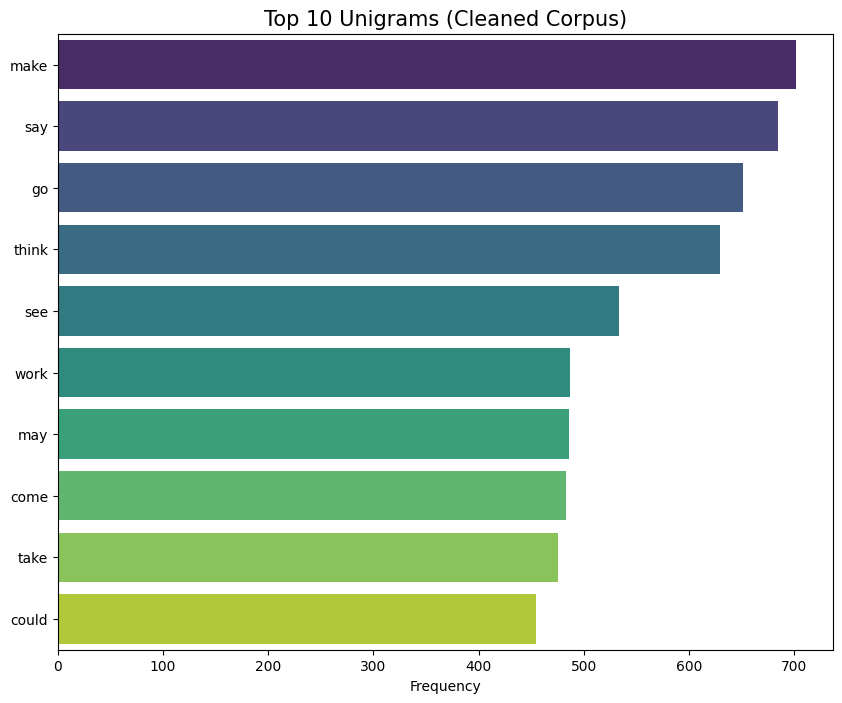

In [37]:
#Plotting Top 10 final cleaned corpus Unigrams
words, counts = zip(*top_unigrams_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)
plt.title("Top 10 Unigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Visualizing Top 10 Bigrams (Final Cleaned corpus) for 20newsgroups

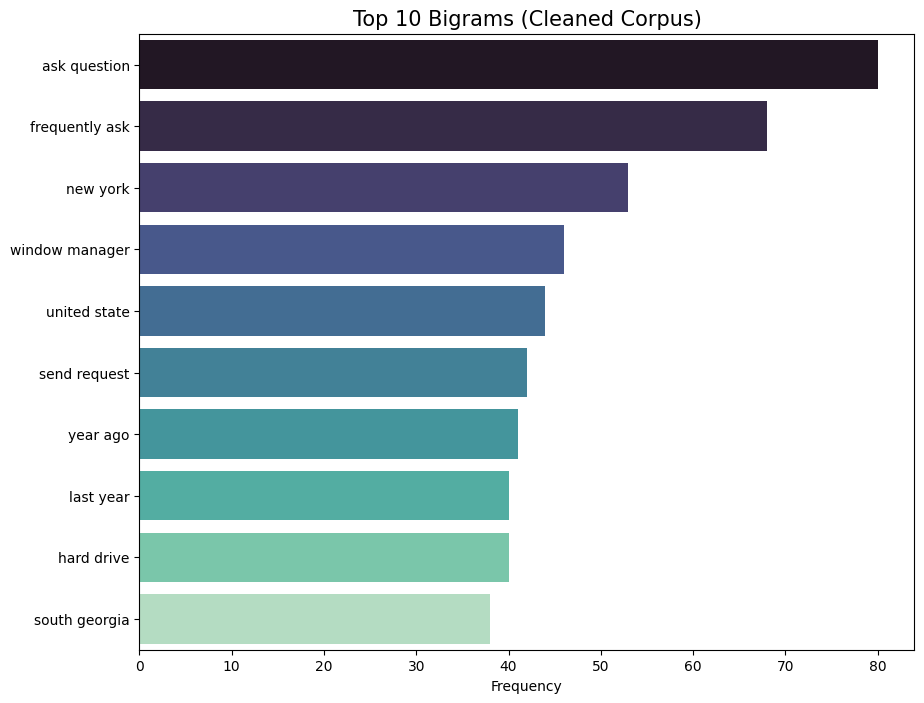

In [38]:
#Plotting Top 10 final cleaned corpus Bigrams
words, counts = zip(*top_bigrams_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="mako", legend=False)
plt.title("Top 10 Bigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Visualizing Top 10 Trigrams (Final Cleaned corpus) for 20newsgroups

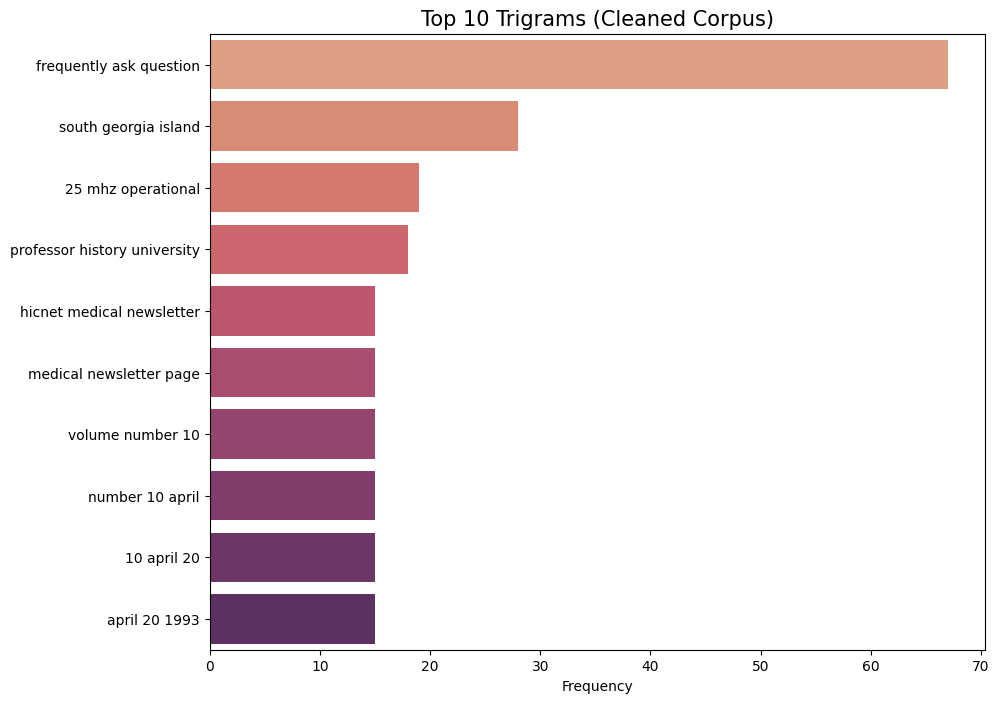

In [39]:
#Plotting Top 10 final cleaned corpus Trigrams
words, counts = zip(*top_trigrams_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="flare", legend=False)
plt.title("Top 10 Trigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### First Wordcloud for 20newsgroups

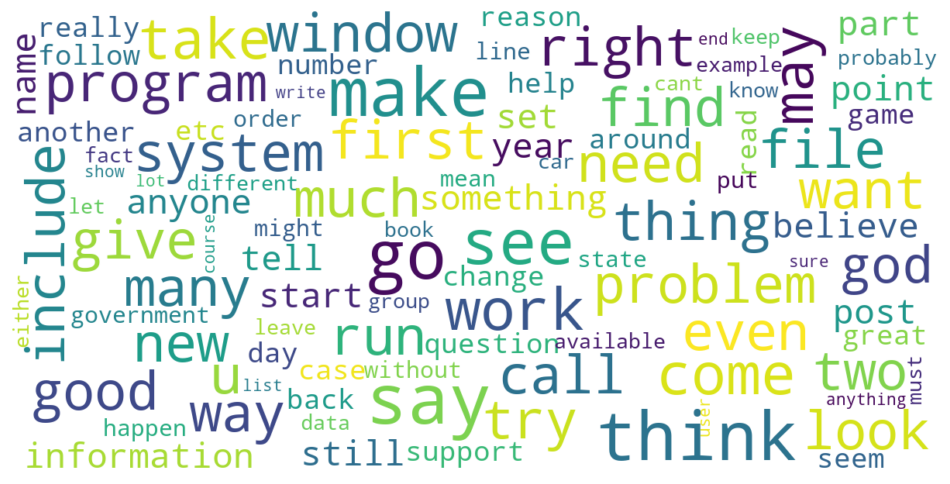

In [40]:
from wordcloud import WordCloud, STOPWORDS as workcloud_stopwords_20newsgroups

stopwords = set(STOPWORDS)

def show_wordcloud(data):
    #Combining the list of strings into one single string (if it not already)
    if isinstance(data, pd.Series):
        text = ' '.join(data.astype(str))
    elif isinstance(data, list):
        text = ' '.join(data)
    else:
        text = str(data)

    
    #Configuring the WordCloud
    wordcloud = WordCloud(
        background_color='white',
        stopwords=workcloud_stopwords_20newsgroups,
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1
    )

    #Generating the word cloud
    wordcloud.generate(text)

    #Plotting the image
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    plt.imshow(wordcloud, interpolation='bilinear') 
    plt.show()

#Calling the function with the corpus
show_wordcloud(corpus_20newsgroups)

##### Inserting custom words in the stopwords & removing them from 20newsgroups

In [41]:
#Defining custom filler words for adding in stopwords (found while running wordcloud & before adjusting in td-if max_df & min_df)
custom_words_to_ignore = [
    'many', 'take', 'need', 'say', 'may', 'much', 'find', 'thing', 
    'think', 'make', 'go', 'let', 'even', 'bit', 'way', 'quite', 
    'possible', 'enough', 'first', 'u', 'often', 'sometimes','iii10','reusss',
    'want','give','try','look','call','etc','example', 'something', 'anything',   
    'probably', 'seem', 'tell', 'want', 'good', 'right', 'know', 'really',
    'well', 'also', 'would', 'could', 'sure', 'lot','anyone'
]

#Updating the existing NLTK STOPWORDS set with the custom_words_to_ignore
stopwords = set(STOPWORDS)
STOPWORDS.update(custom_words_to_ignore)

#Creating an upgraded cleaning function
def remove_stopwords_and_numbers(text):
    """Custom function to remove stopwords, numbers, and single characters"""
    cleaned_words = []
    for word in str(text).split():
        #Skipping if the word is in the updated stopword list
        if word in STOPWORDS:
            continue
            
        #Skipping if the word is only 1 character long ('u', '1' etc)
        if len(word) <= 1:
            continue
        
        #Skipping any word that isn't 100% alphabetical letters ('42' etc)
        if not word.isalpha():
            continue
        
        #If it passes all rules, keeping the word
        cleaned_words.append(word)
        
    return " ".join(cleaned_words)

#Re-applying the upgraded function to the final base new text column final_checked_corpus
df_sentence_20newsgroups["final_checked_corpus"] = df_sentence_20newsgroups["final_clean_corpus"].apply(remove_stopwords_and_numbers)

#Updating corpus
corpus_20newsgroups = df_sentence_20newsgroups["final_checked_corpus"].tolist()
print("Text successfully re-cleaned! Numbers, mixed junk, and custom stopwords removed.")

Text successfully re-cleaned! Numbers, mixed junk, and custom stopwords removed.


##### Re-aligning final corpus with the original labels (category and ground truth)

In [42]:
#Keeping only rows where the cleaned text of column "final_lemmatized_cleaned_sentence" has length greater than 0
df_sentence_20newsgroups = df_sentence_20newsgroups[df_sentence_20newsgroups["final_checked_corpus"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "final_lemmatized_cleaned_sentence"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_sentence_20newsgroups)}")

#Re-aligning with the original labels (category and ground truth labels)
final_df_20newsgroups = df_sentence_20newsgroups.merge(
    full_df_20newsgroups[['ground_truth_label', 'category']], 
    left_index=True, 
    right_index=True
)


#Dropping duplicates based on both text and label
duplicate_count = final_df_20newsgroups.duplicated(subset=["final_checked_corpus", "ground_truth_label"]).sum()
print(f"Number of duplicate rows dropped: {duplicate_count}")
final_df_20newsgroups.drop_duplicates(subset=["final_checked_corpus", "ground_truth_label"], inplace=True)

#Resetting index
final_df_20newsgroups.reset_index(drop=True, inplace=True)
#Final rows in cleaned column after indxexing reset
print(f"Final rows in corpus column with name final_clean_corpus is: {len(final_df_20newsgroups)}")
print(f"Final rows in final merged dataframe of 20newsgroups: {len(final_df_20newsgroups)}")
print(f"Final shape for modeling: {final_df_20newsgroups.shape}")
print(' ')

#Updating corpus
corpus_20newsgroups=final_df_20newsgroups["final_checked_corpus"]

#display(final_df_20newsgroups.head())

Rows after removing empty rows in finally cleaned text column: 1819
Number of duplicate rows dropped: 1
Final rows in corpus column with name final_clean_corpus is: 1818
Final rows in final merged dataframe of 20newsgroups: 1818
Final shape for modeling: (1818, 8)
 


##### Final Topic Modelling for 20newsgroups

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model

#Grabbing latest cleaned corpus
corpus_final_20newsgroups = corpus_20newsgroups

#Re-vectorizing the text 
tf_vectorizer = CountVectorizer(stop_words=None,
                                max_df=0.85,    #Ignoring words that appear in >85% of documents
                                min_df=2,       #Ignoring words that appear in less than 2 documents
                                token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')
    
tf = tf_vectorizer.fit_transform(corpus_final_20newsgroups)

#Re-initializing and fit the LDA model for 8 topics. 20 had awful result
lda_model = LatentDirichletAllocation(n_components=8, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Displaying the dashboard
pyLDAvis.display(panel)

##### Final Wordcloud for 20newsgroups

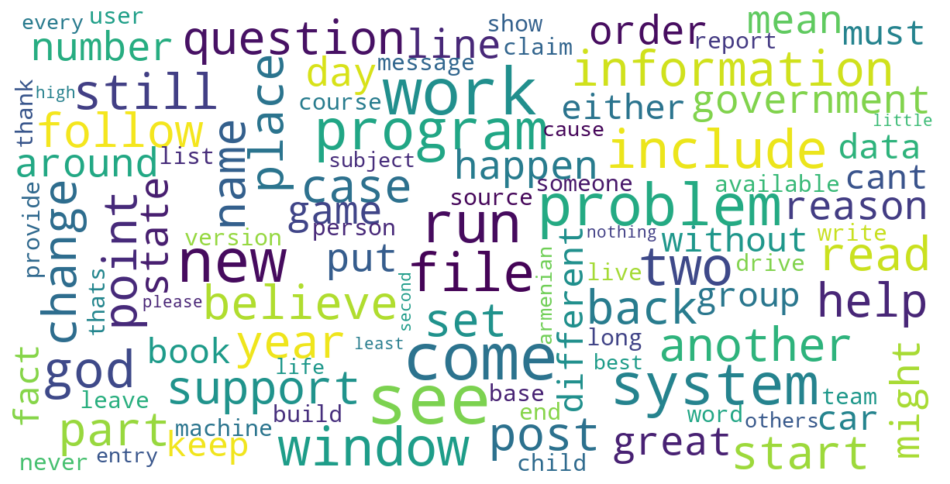

In [44]:
#Calling the function with the final corpus
show_wordcloud(corpus_20newsgroups)

##### Visualizing updated distribution of word count per final cleaned sentence for 20newsgroups

Mean Word Count: 76.00
Median Word Count: 33.00


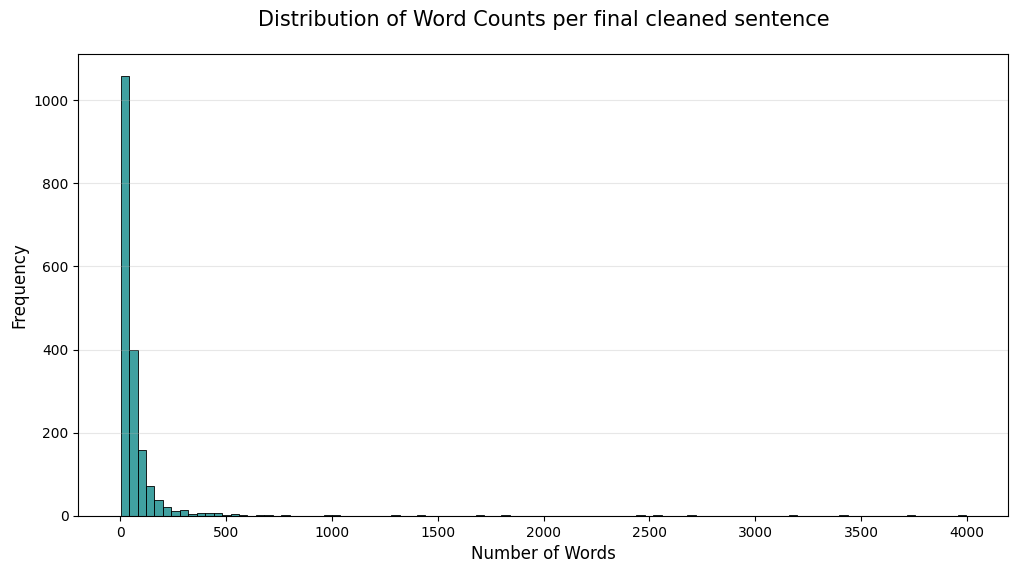

In [45]:
#Calculating updated word counts by splitting strings into lists
final_df_20newsgroups["word_count"] = final_df_20newsgroups["final_checked_corpus"].str.split().str.len()

#Calculating key statistics
mean_words = final_df_20newsgroups["word_count"].mean().round()
median_words = final_df_20newsgroups["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(final_df_20newsgroups["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per final cleaned sentence", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Visualizing updated Distribution of Article Lengths (Character Count) for 20newsgroups

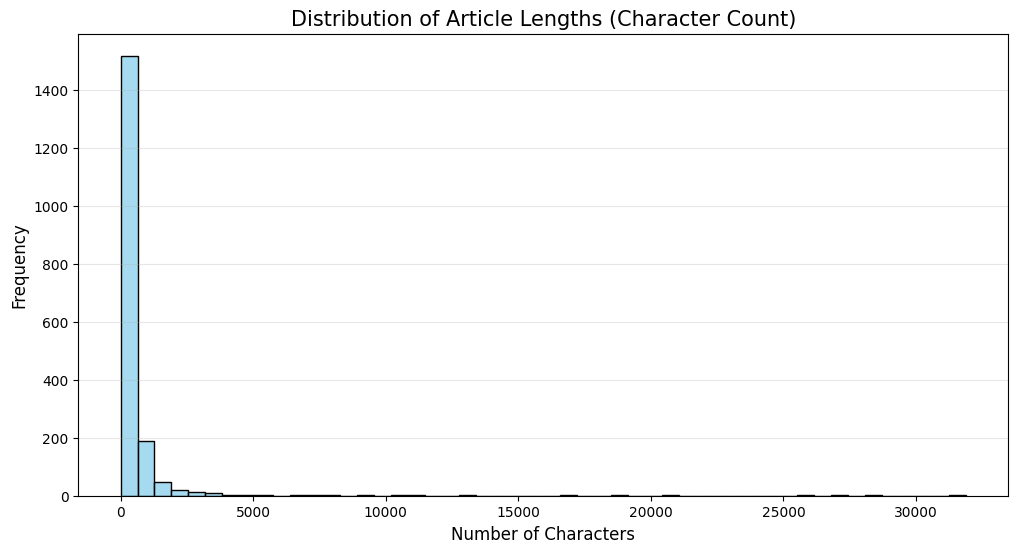

In [46]:
#Checking the number of characters present in each sentence to have a rough idea about the text headline length
#Calculating sentence lengths
final_df_20newsgroups["char_count"] = final_df_20newsgroups["final_checked_corpus"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(final_df_20newsgroups["char_count"], bins=50, color="skyblue")
plt.title("Distribution of Article Lengths (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Visualizing updated average word length in each Sentence for 20newsgroups

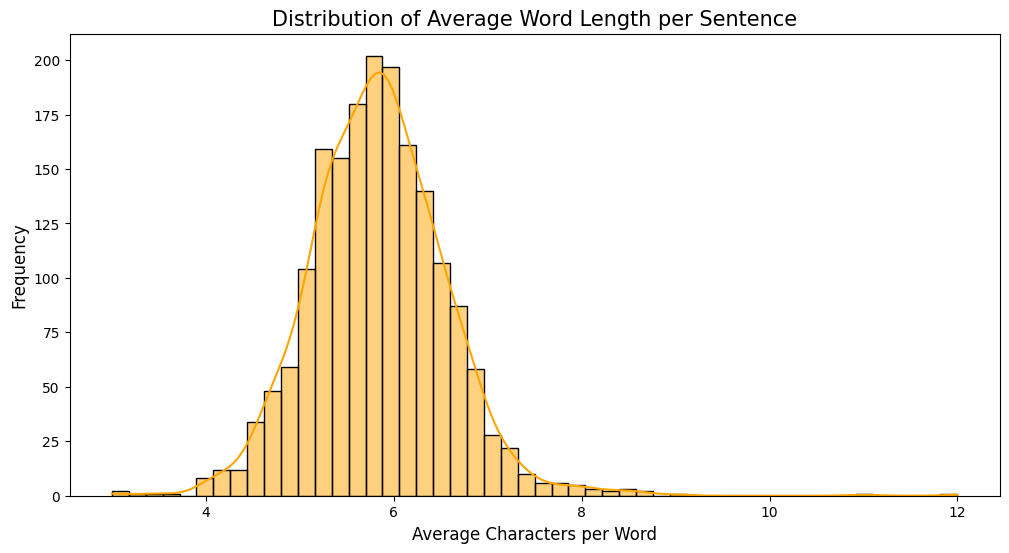

In [47]:
def get_avg_word_len(text):
    """Function to calculating average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

final_df_20newsgroups['avg_word_len'] = final_df_20newsgroups['final_checked_corpus'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(final_df_20newsgroups['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per Sentence", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

***

##### Cleaning & EDA for bbcnews dataframe

##### Selecting values from desired column "sentence" for text EDA of bbcnews

In [48]:
df_sentence_bbcnews = full_df_bbcnews[["sentence"]].copy()
df_sentence_bbcnews["sentence"] = df_sentence_bbcnews["sentence"].astype(str)
#display(full_df_bbcnews.head())

#Creating the corpus for corpus_bbcnews
corpus_bbcnews=df_sentence_bbcnews["sentence"]

##### Visualizing Sentence Count for bbcnews

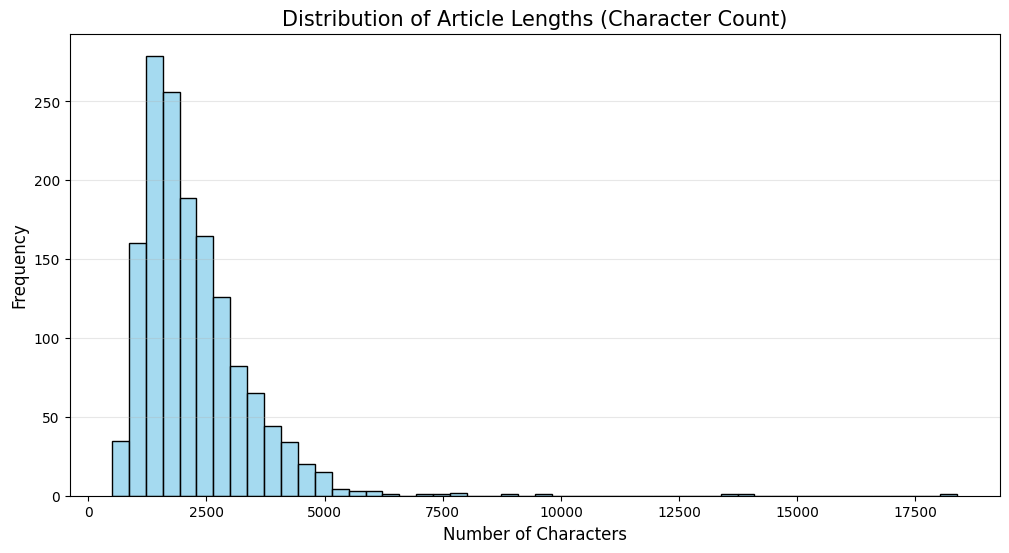

In [49]:
#Checking the number of characters present in each sentence to have a rough idea about the text headline length
#Calculating sentence lengths
df_sentence_bbcnews["char_count"] = df_sentence_bbcnews["sentence"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_sentence_bbcnews["char_count"], bins=50, color="skyblue")
plt.title("Distribution of Article Lengths (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

##### Visualizing Word Count for bbcnews

Mean Word Count: 385.00
Median Word Count: 337.00


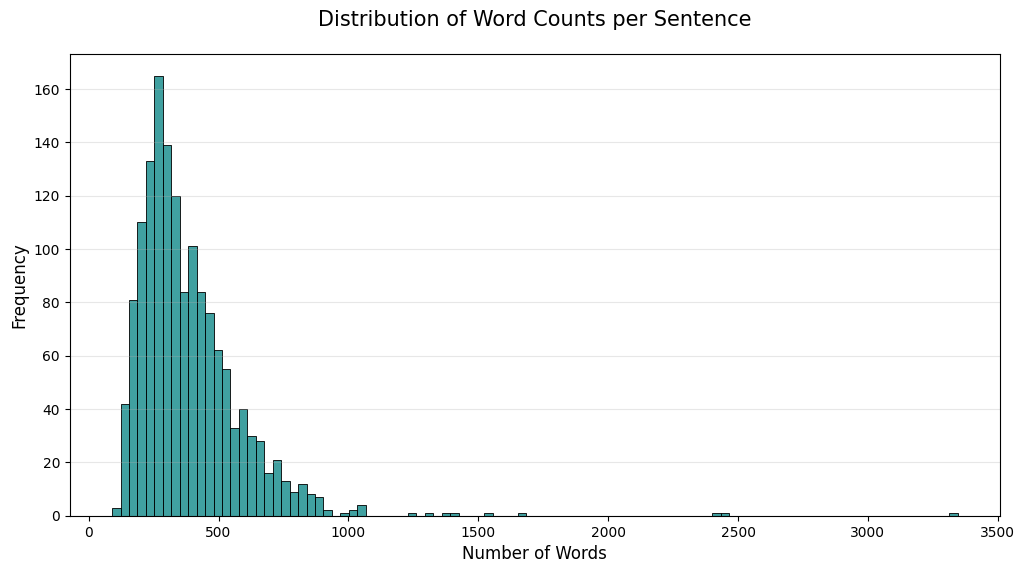

In [50]:
#Calculating word counts by splitting strings into lists
df_sentence_bbcnews["word_count"] = df_sentence_bbcnews["sentence"].str.split().str.len()

#Calculating key statistics
mean_words = df_sentence_bbcnews["word_count"].mean().round()
median_words = df_sentence_bbcnews["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_sentence_bbcnews["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per Sentence", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Visualizing average word length in each Sentence for bbcnews

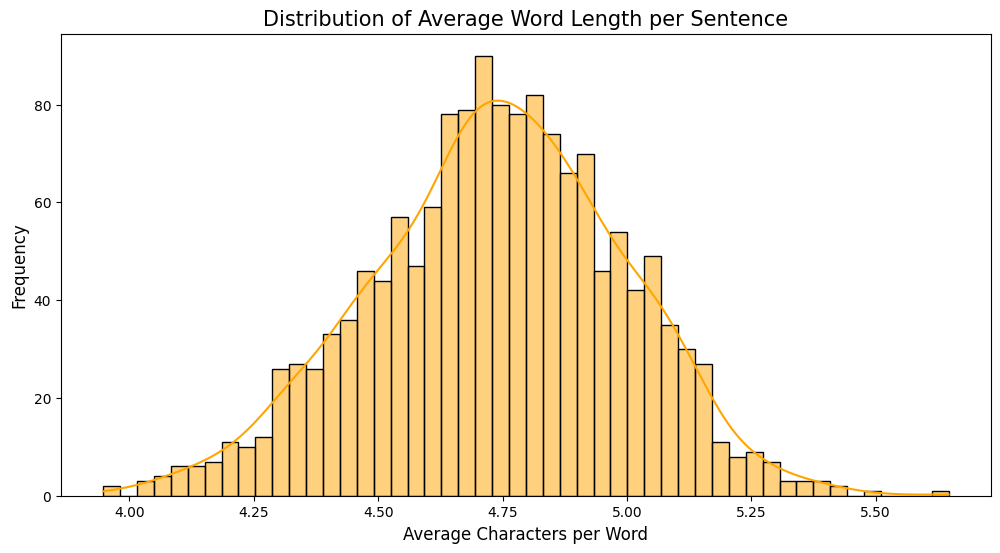

In [51]:
def get_avg_word_len(text):
    """Function to calculating average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df_sentence_bbcnews['avg_word_len'] = df_sentence_bbcnews['sentence'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_sentence_bbcnews['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per Sentence", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

##### Ngram exploration for bbcnews

In [52]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

#Initializing the raw corpus
corpus_raw_bbcnews = df_sentence_bbcnews["sentence"]

#Extracting the top 10 for different n-gram ranges
top_unigrams = get_top_ngram(corpus_raw_bbcnews, n=1)
top_bigrams = get_top_ngram(corpus_raw_bbcnews, n=2)
top_trigrams = get_top_ngram(corpus_raw_bbcnews, n=3)

print("Top 10 Unigrams (Raw):", top_unigrams)
print("Top 10 Bigrams (Raw):", top_bigrams)
print("Top 10 Trigrams (Raw):", top_trigrams)

Top 10 Unigrams (Raw): [('the', np.int64(35030)), ('to', np.int64(16665)), ('of', np.int64(13003)), ('and', np.int64(12399)), ('in', np.int64(11802)), ('for', np.int64(5805)), ('is', np.int64(5505)), ('that', np.int64(5277)), ('it', np.int64(5186)), ('on', np.int64(5098))]
Top 10 Bigrams (Raw): [('of the', np.int64(3239)), ('in the', np.int64(3231)), ('to the', np.int64(1360)), ('for the', np.int64(1250)), ('on the', np.int64(1233)), ('to be', np.int64(1136)), ('at the', np.int64(1073)), ('he said', np.int64(889)), ('and the', np.int64(886)), ('said the', np.int64(825))]
Top 10 Trigrams (Raw): [('one of the', np.int64(240)), ('in the uk', np.int64(194)), ('in the us', np.int64(192)), ('as well as', np.int64(186)), ('the end of', np.int64(171)), ('be able to', np.int64(135)), ('the prime minister', np.int64(134)), ('he said the', np.int64(125)), ('the number of', np.int64(117)), ('said it was', np.int64(115))]


##### Visualizing Top 10 Unigrams (Raw) for bbcnews

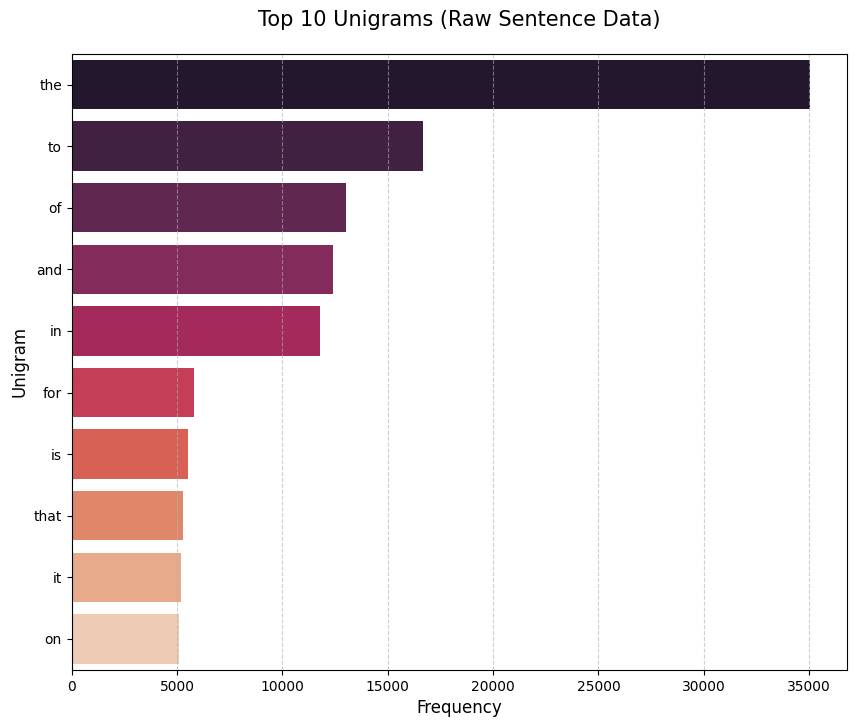

In [53]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_unigrams)

#Visualizing Top 10 Bigrams (Raw) for bbcnews
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Unigrams (Raw Sentence Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Unigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### Visualizing Top 10 Bigrams (Raw) for bbcnews

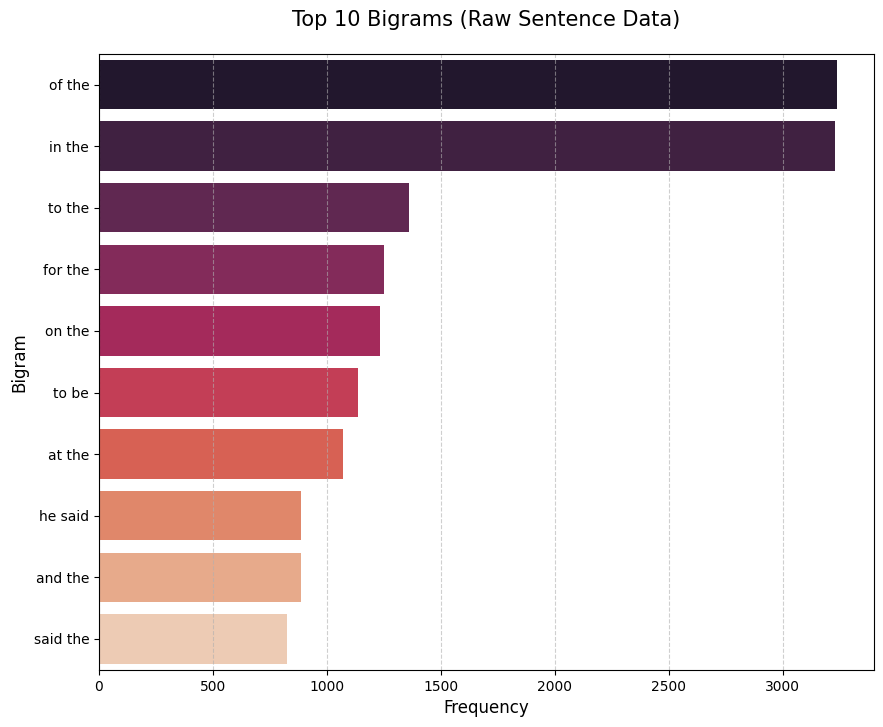

In [54]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_bigrams)

#Visualizing Top 10 Bigrams (Raw) for bbcnews
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Bigrams (Raw Sentence Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Bigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### Visualizing Top 10 Trigrams (Raw) for bbcnews

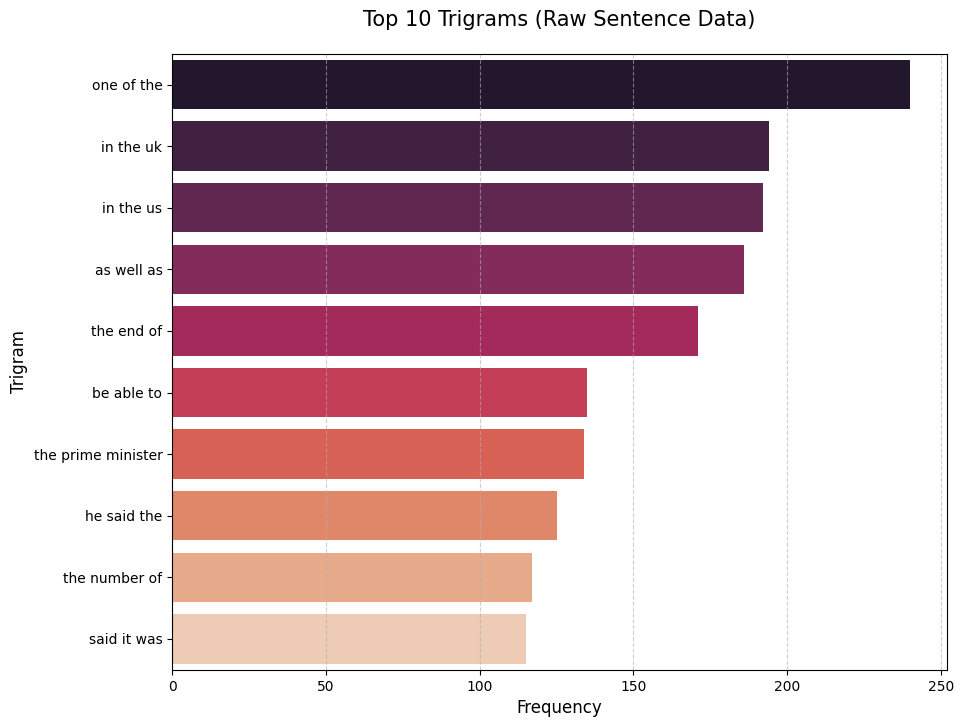

In [55]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_trigrams)

#Visualizing Top 10 Bigrams (Raw) for bbcnews
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Trigrams (Raw Sentence Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Trigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### Topic modeling exploration (Raw) for bbcnews

In [56]:
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model
from pyLDAvis import prepare

#Vectorizing the raw corpus
corpus_raw_bbcnews = df_sentence_bbcnews["sentence"]
tf_vectorizer = CountVectorizer(stop_words=None)
tf = tf_vectorizer.fit_transform(corpus_raw_bbcnews)

#Initializing and fitting LDA
#Chose initial n_components=20 to have 5 broad topics,as ground truth is 5 categories 
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Displaying the dashboard
pyLDAvis.display(panel)

##### Removal of HTML Tags like <'p> or <br'> & translating them into text in bbcnews raw text rows

In [57]:
from bs4 import BeautifulSoup

def remove_html_tags(text):
    """
    Removes HTML tags using BeautifulSoup. 
    If no tags are present, it returns the original text intact.
    """
    #check to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Parsing the text and extracting only the string content
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ", strip=True)

df_sentence_bbcnews["sentence_no_html"] = df_sentence_bbcnews["sentence"].apply(remove_html_tags)

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["sentence_no_html"]

##### Removal of urls in bbcnews clean from htlml tags text rows

In [58]:
import re

def remove_urls(text):
    """
    Removes URLs from the text using regular expressions.
    If no URLs are present, it returns the original previous text intact.
    """
    #Checking to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Regex pattern to match http, https, and www URLs
    url_pattern = re.compile(r'http[s]?://\S+|www\.\S+')
    
    #Replacing the matched URLs with an empty string
    return url_pattern.sub(r'', text)

#Applying the URL removal to the text that just had HTML removed
df_sentence_bbcnews["sentence_no_url"] = df_sentence_bbcnews["sentence_no_html"].apply(remove_urls)

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["sentence_no_url"]

##### Removal of Emoticons like :-) & translating them into text in bbcnews clean text rows

In [59]:
import re

#Creating a dictionary of common emoticons and their text translations
EMOTICON_DICT = {
    r':-\)': ' happy ', r':\)': ' happy ', r':-\]': ' happy ', r':\]': ' happy ',
    r':-\(': ' sad ', r':\(': ' sad ', r':-\[': ' sad ', r':\[': ' sad ',
    r':-D': ' laugh ', r':D': ' laugh ', r'XD': ' laugh ',
    r';-\)': ' wink ', r';\)': ' wink ',
    r':-P': ' playful ', r':P': ' playful '
}

def translate_emoticons(text):
    """Translates ASCII emoticons to words BEFORE punctuation is removed"""
    text = str(text)
    for emoticon, word in EMOTICON_DICT.items():
        text = re.sub(emoticon, word, text, flags=re.IGNORECASE)
    return text

#Apply this to the raw text :
df_sentence_bbcnews["after_emoticons_translation_sentence"] = df_sentence_bbcnews["sentence_no_url"].apply(translate_emoticons)

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["after_emoticons_translation_sentence"]

##### Removal of Emojis like 😀 & translating them into text in bbcnews clean text rows

In [60]:
import emoji

def translate_emoji_to_words(text):
    """Translates emojis into text aliases (e.g., 👍 becomes 'thumbs up')"""
    translated_text = emoji.demojize(str(text), delimiters=(" ", " "))
    
    #Replacing underscores with spaces so 'thumbs_up' for example becomes 'thumbs up'
    translated_text = translated_text.replace("_", " ")
    
    return translated_text

#Applying it to the latest cleaned text column
df_sentence_bbcnews["after_emojis_emoticons_translation_sentence"] = df_sentence_bbcnews["after_emoticons_translation_sentence"].apply(translate_emoji_to_words)

#Cleaning up any extra whitespace left behind
df_sentence_bbcnews["after_emojis_emoticons_translation_sentence"] = df_sentence_bbcnews["after_emojis_emoticons_translation_sentence"].str.replace(r'\s+', ' ', regex=True).str.strip()

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["after_emojis_emoticons_translation_sentence"]

# df_sentence_bbcnews.head()

##### Removal of Punctuations & implementing lower casing in column "sentence" of bbcnews

In [61]:
PUNCT_TO_REMOVE = string.punctuation

def remove_punctuation_and_lower(text):
    """Custom function to remove punctuation and lowercase text"""
    return text.lower().translate(str.maketrans('', '', PUNCT_TO_REMOVE))

#Applying the function
df_sentence_bbcnews["sentence_wo_punct_lower"] = df_sentence_bbcnews["after_emojis_emoticons_translation_sentence"].apply(remove_punctuation_and_lower)

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["sentence_wo_punct_lower"]

#display(df_sentence_bbcnews.head())

##### Removal of stopwords in column "sentence_wo_punct_lower" of cleaned text of 20newsgroups

In [62]:
CHAT_WORDS_DICT = {
    "a3": "anytime anywhere anyplace", "adih": "another day in hell", "afk": "away from keyboard",
    "afaik": "as far as i know", "asap": "as soon as possible", "asl": "age sex location",
    "atk": "at the keyboard", "atm": "at the moment", "aka": "also known as", "approx": "approximately",
    "bae": "before anyone else", "bak": "back at keyboard", "bbl": "be back later", "bbs": "be back soon",
    "bfn": "bye for now", "b4n": "bye for now", "brb": "be right back", "bruh": "bro", 
    "brt": "be right there", "bsaaw": "big smile and a wink", "btw": "by the way", "b/c": "because",
    "bwl": "bursting with laughter", "csl": "can not stop laughing", "cu": "see you", 
    "cul8r": "see you later", "cya": "see you", "dm": "direct message", "eta": "estimated time of arrival",
    "eod": "end of day", "eow": "end of week", "faq": "frequently asked questions", 
    "fc": "fingers crossed", "fimh": "forever in my heart", "fomo": "fear of missing out", 
    "fr": "for real", "fwiw": "for what its worth", "fyp": "for you page", "fyi": "for your information", 
    "g9": "genius", "gal": "get a life", "gg": "good game", "gmta": "great minds think alike",
    "gn": "good night", "goat": "greatest of all time", "gr8": "great", "hbd": "happy birthday", 
    "hbu": "how about you", "ic": "i see", "icq": "i seek you", "idc": "i do not care",
    "idk": "i do not know", "iirc": "if i recall correctly", "ifyp": "i feel your pain", 
    "ilu": "i love you", "ily": "i love you", "imho": "in my humble opinion", "imu": "i miss you",
    "imo": "in my opinion", "iow": "in other words", "irl": "in real life",
    "iykyk": "if you know you know", "jk": "just kidding", "k": "okay", "kiss": "keep it simple stupid",
    "l": "loss", "l8r": "later", "ldr": "long distance relationship", "lmk": "let me know",
    "lmao": "laughing my ass off", "lol": "laughing out loud", "ltns": "long time no see",
    "m8": "mate", "mfw": "my face when", "mid": "mediocre", "mrw": "my reaction when",
    "mte": "my thoughts exactly", "n": "and", "nvm": "never mind", "nrn": "no reply necessary",
    "npc": "non player character", "oic": "oh i see", "op": "overpowered", "ootl": "out of the loop",
    "pita": "pain in the ass", "pov": "point of view", "prt": "party", "pls": "please", "plz": "please",
    "prw": "parents are watching", "r": "are", "rofl": "rolling on the floor laughing",
    "roflol": "rolling on the floor laughing out loud", 
    "rotflmao": "rolling on the floor laughing my ass off", "rn": "right now", 
    "sk8": "skate", "stats": "your sex and age", "sus": "suspicious", "tbh": "to be honest", 
    "tba": "to be announced", "tbd": "to be determined", "tbf": "to be fair",
    "tfw": "that feeling when", "thx": "thank you", 
    "tldr": "too long did not read", "tntl": "trying not to laugh", "ttfn": "ta ta for now", 
    "ttyl": "talk to you later", "u": "you", "u2": "you too", "u4e": "yours for ever", 
    "w": "win", "w8": "wait", "wb": "welcome back", "wbu": "what about you", "wtf": "what the fuck", 
    "wtg": "way to go", "wuf": "where are you from", "wyd": "what you doing", "w/": "with", 
    "w/o": "without", "wywh": "wish you were here", "y": "why", "zzz": "sleeping bored tired"
}

In [63]:
def chat_words_conversion(text):
    """
    Expands common abbreviations into full words.
    Checks each word against the dictionary.
    """
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    return " ".join([CHAT_WORDS_DICT.get(word, word) for word in text.split()])

df_sentence_bbcnews["sentence_chat_wo_punct_lower"] = df_sentence_bbcnews["sentence_wo_punct_lower"].apply(chat_words_conversion)

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["sentence_chat_wo_punct_lower"]

##### Visualizing Top 15 Most Frequent Stopwords of bbcnews

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\roxan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


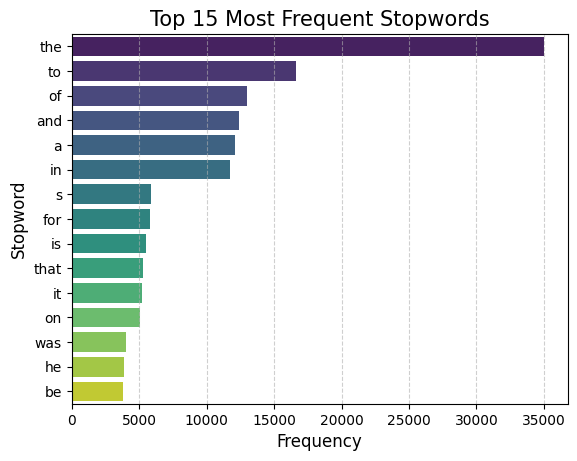

In [64]:
from nltk.corpus import stopwords
nltk.download('stopwords') #downloading list of English words
from collections import Counter

STOPWORDS = set(stopwords.words('english'))
manual_fixes = [word.replace("'", "") for word in STOPWORDS if "'" in word]
STOPWORDS.update(manual_fixes)

#Identifying which text column to analyze 
text_data = corpus_bbcnews

#Extracting and count stopwords only
stopword_list = []
for text in text_data:
    words = str(text).split()
    stopword_list.extend([word for word in words if word in STOPWORDS])

#Getting the Top 15
stopword_counts = Counter(stopword_list).most_common(15)
words, counts = zip(*stopword_counts)

#Visualizing Top 15 Most Frequent Stopwords of bbcnews
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)

plt.title("Top 15 Most Frequent Stopwords", fontsize=15)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Stopword", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

##### Removal of stopwords in column "sentence_wo_punct_lower" of bbcnews

In [65]:
def remove_stopwords(text):
    """custom function to remove the stopwords"""
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df_sentence_bbcnews["sentence_wo_stopwords_punct_lower"] = df_sentence_bbcnews["sentence_chat_wo_punct_lower"].apply(remove_stopwords)

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["sentence_wo_stopwords_punct_lower"]

#display(df_sentence_bbcnews.head())

##### Dropping not needed columns of bbcnews

In [66]:
#Dropping the two previously created columns that are no longer needed 
df_sentence_bbcnews.drop(["char_count","word_count","sentence_no_html","sentence_no_url","after_emoticons_translation_sentence","after_emojis_emoticons_translation_sentence","sentence_chat_wo_punct_lower"], axis=1, inplace=True)

##### Removal of Frequent words of bbcnews cleaned text rows

In [67]:
from collections import Counter
cnt = Counter()
for text in df_sentence_bbcnews["sentence_wo_stopwords_punct_lower"].values:
    for word in text.split():
        cnt[word] += 1
        
print(cnt.most_common(10))

#print(' ')
#print('Alternative way to find the top_10_words using pandas:')
#top_10_words = df_sentence_bbcnews["sentence_wo_stopwords_punct_lower"].str.split().explode().value_counts().head(10)
#print(top_10_words)

[('said', 4838), ('mr', 1973), ('would', 1711), ('also', 1430), ('new', 1334), ('people', 1322), ('us', 1226), ('year', 1209), ('one', 1158), ('could', 1032)]


In [68]:
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
def remove_freqwords(text):
    """custom function to remove the frequent words"""
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

df_sentence_bbcnews["sentence_wo_freq_stopwords_punct_lower"] = df_sentence_bbcnews["sentence_wo_stopwords_punct_lower"].apply(lambda text: remove_freqwords(text))

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["sentence_wo_freq_stopwords_punct_lower"]

#display(df_sentence_bbcnews.head())

##### Removal of Rare words of bbcnews cleaned text rows

In [69]:
#Defining the min_freq_threshold for removal of words appearing fewer than X times
min_freq_threshold = 2

#Identifying all words that don't meet the threshold
RAREWORDS = set([word for word, count in cnt.items() if count < min_freq_threshold])
print(f"Number of unique rare words to remove: {len(RAREWORDS)}")
print(f"Sample of words appearing only once (to be removed):")
for word in list(RAREWORDS)[:20]:
    print(f"{word}: {cnt[word]}")

#Defining the cleaning function
def remove_rarewords(text):
    """Removes words that appear fewer than the threshold frequency"""
    if pd.isna(text) or not isinstance(text, str):
        return text
    return " ".join([word for word in text.split() if word not in RAREWORDS])

df_sentence_bbcnews["sentence_wo_rare_freq_stopwords_punct_lower"] = df_sentence_bbcnews["sentence_wo_freq_stopwords_punct_lower"].apply(remove_rarewords)

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["sentence_wo_rare_freq_stopwords_punct_lower"]

#display(df_sentence_bbcnews.head())

Number of unique rare words to remove: 10824
Sample of words appearing only once (to be removed):
fuerteventura: 1
salutary: 1
100ml: 1
confiscatory: 1
multicore: 1
42yearold: 1
courvoisier: 1
wig: 1
condommaker: 1
debacle: 1
rijk: 1
herne: 1
cryptography: 1
brokaw: 1
reno: 1
metrovias: 1
eady: 1
peoplethere: 1
illatease: 1
petulance: 1


##### Lemmatization in bbcnews cleaned text rows

In [70]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
#Downloading the required WordNet data
nltk.download('wordnet', quiet=True) 
nltk.download('omw-1.4', quiet=True) 
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """Custom function to lemmatize text """
    return " ".join([lemmatizer.lemmatize(word) for word in str(text).split()])

#Applying function to the fully cleaned column and creating a new column with lematized cleaned text data
df_sentence_bbcnews["lemmatized_cleaned_sentence"] = df_sentence_bbcnews["sentence_wo_rare_freq_stopwords_punct_lower"].apply(lemmatize_text)

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["lemmatized_cleaned_sentence"]

#display(df_sentence_bbcnews[["sentence_wo_rare_freq_stopwords_punct_lower", "lemmatized_cleaned_sentence"]].head())

##### Developping lemmatization of text in bbcnews cleaned text rows by using POS tagging

In [71]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

#Downloading the required wordnet data & POS tagger model
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

#Mapping nltk POS tags to WordNet POS tags
wordnet_map = {"N": wordnet.NOUN, "V": wordnet.VERB, "J": wordnet.ADJ, "R": wordnet.ADV}

def lemmatize_words(text):
    """Custom function to develop lemmatization of text by using POS tagging"""
    pos_tagged_text = nltk.pos_tag(str(text).split())
    return " ".join([lemmatizer.lemmatize(word, wordnet_map.get(pos[0], wordnet.NOUN)) for word, pos in pos_tagged_text])

df_sentence_bbcnews["final_lemmatized_cleaned_sentence"] = df_sentence_bbcnews["sentence_wo_rare_freq_stopwords_punct_lower"].apply(lambda text: lemmatize_words(text))

#Updating corpus of bbcnews
corpus_bbcnews=df_sentence_bbcnews["final_lemmatized_cleaned_sentence"]

#Display the before and after the POS tagging in lematization
#display(df_sentence_bbcnews[["sentence_wo_rare_freq_stopwords_punct_lower", "final_lemmatized_cleaned_sentence"]].head())

#Checking all columns in df_sentence_20newsgroups
#df_sentence_bbcnews

#Dropping not needed any more columns in df_sentence_20newsgroups
df_sentence_bbcnews.drop(["sentence_wo_freq_stopwords_punct_lower", "sentence_wo_rare_freq_stopwords_punct_lower","lemmatized_cleaned_sentence"], axis=1, inplace=True)

#Checking updated columns in df_sentence_20newsgroups
#df_sentence_bbcnews

##### Checking Nulls of final cleaned column "final_lemmatized_cleaned_sentence" of bbcnews & dropping cleaned text null rows

In [72]:
#Checking for null values
null_count = df_sentence_bbcnews["final_lemmatized_cleaned_sentence"].isna().sum()
print(f"Number of null values in finally cleaned text column : {null_count}")

#Initial rows before dropping null values
print(f"Rows before dropping null values in finally cleaned text column: {len(df_sentence_bbcnews)}")

#Drupping null values
df_sentence_bbcnews.dropna(subset=["final_lemmatized_cleaned_sentence"], inplace=True)

#Rows after dropping null values and before dropping duplicate values
print(f"Rows after dropping null values and before dropping duplicate values in finally cleaned text column: {len(df_sentence_bbcnews)}")

#Keeping only rows where the cleaned text of column "final_lemmatized_cleaned_sentence" has length greater than 0
df_sentence_bbcnews = df_sentence_bbcnews[df_sentence_bbcnews["final_lemmatized_cleaned_sentence"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "final_lemmatized_cleaned_sentence"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_sentence_bbcnews)}")

#Updating corpus
corpus_bbcnews=df_sentence_bbcnews["final_lemmatized_cleaned_sentence"]

Number of null values in finally cleaned text column : 0
Rows before dropping null values in finally cleaned text column: 1490
Rows after dropping null values and before dropping duplicate values in finally cleaned text column: 1490
Rows after removing empty rows in finally cleaned text column: 1490


##### Visualizing updated Top 5 Most Frequent Stopwords of bbcnews (should be zero)

In [73]:
from nltk.corpus import stopwords
from collections import Counter

#Updating the standard set with de-punctuated versions
STOPWORDS = set(stopwords.words('english'))
manual_fixes = [word.replace("'", "") for word in STOPWORDS if "'" in word]
STOPWORDS.update(manual_fixes)

#Defining a robust cleaning function
def final_clean_check(text):
    #Ensuring string type, lowercase, and split on any whitespace
    return " ".join([word for word in str(text).lower().split() if word not in STOPWORDS])

#Re-applying to the dataframe and updating the corpus variable
df_sentence_bbcnews["sentence_final_clean"] = df_sentence_bbcnews["final_lemmatized_cleaned_sentence"].apply(final_clean_check)

#Updating corpus
corpus_bbcnews = df_sentence_bbcnews["sentence_final_clean"]

#Running the counting logic on the updated final corpus
text_data = corpus_bbcnews
stopword_list = []
for text in text_data:
    words = text.split()
    stopword_list.extend([word for word in words if word in STOPWORDS])

#Plotting the results if stopwords exist
if not stopword_list:
    print("Success! No standard stopwords detected.")
else:
    stopword_counts = Counter(stopword_list).most_common(15)
    words, counts = zip(*stopword_counts)
    plt.figure(figsize=(10, 8))
    sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)
    plt.title("Remaining Stopwords After Check", fontsize=15)
    plt.show()

Success! No standard stopwords detected.


##### Visualizing updated Top 15 Most Frequent Words of bbcnews

In [74]:
top_15_words = df_sentence_bbcnews["sentence_final_clean"].str.split().explode().value_counts().head(15)
print(top_15_words)

sentence_final_clean
make          1445
take          1152
go            1131
say           1049
game          1030
get           1014
use            965
time           962
last           894
first          892
two            816
world          809
film           806
come           773
government     771
Name: count, dtype: int64


##### Adding domain-specific noise words into the existing STOPWORDS set & removing them of bbcnews

In [75]:
#Defining domain-specific noise words found in workcloud done later
domain_stopwords = ['make', 'take', 'go', 'say', 'get', 'use', 'time', 'last',
                    'first', 'two', 'come', 'give', 'tell', 'see', 'year', 'best', 'want'
                   ]

#Adding them into the existing STOPWORDS set
STOPWORDS.update(domain_stopwords)

#Removing those noise words from the corpus 
def remove_domain_noise(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df_sentence_bbcnews["final_clean_corpus"] = df_sentence_bbcnews["sentence_final_clean"].apply(remove_domain_noise)

#Updating corpus
corpus_bbcnews = df_sentence_bbcnews["final_clean_corpus"]

##### Visualizing again updated Top 15 Most Frequent Words of bbcnews

In [76]:
top_15_words = df_sentence_bbcnews["final_clean_corpus"].str.split().explode().value_counts().head(15)
print(top_15_words)

final_clean_corpus
game          1030
world          809
film           806
government     771
show           761
uk             757
play           731
work           714
company        682
firm           675
win            650
number         621
service        617
back           587
include        578
Name: count, dtype: int64


##### Ngram exploration for Final cleaned corpus of bbcnews

In [77]:
#Extracting the top 10 for cleaned n-gram ranges
top_unigrams_clean = get_top_ngram(corpus_bbcnews, n=1)
top_bigrams_clean = get_top_ngram(corpus_bbcnews, n=2)
top_trigrams_clean = get_top_ngram(corpus_bbcnews, n=3)

#Printing the results to see the shift in content
print("Top 10 Cleaned Unigrams:", top_unigrams_clean)
print("Top 10 Cleaned Bigrams:", top_bigrams_clean)
print("Top 10 Cleaned Trigrams:", top_trigrams_clean)

Top 10 Cleaned Unigrams: [('game', np.int64(1030)), ('world', np.int64(809)), ('film', np.int64(806)), ('government', np.int64(771)), ('show', np.int64(761)), ('uk', np.int64(757)), ('play', np.int64(731)), ('work', np.int64(714)), ('company', np.int64(682)), ('firm', np.int64(675))]
Top 10 Cleaned Bigrams: [('prime minister', np.int64(222)), ('mobile phone', np.int64(145)), ('general election', np.int64(132)), ('tony blair', np.int64(130)), ('chief executive', np.int64(124)), ('bbc news', np.int64(117)), ('six nation', np.int64(114)), ('liberal democrat', np.int64(110)), ('michael howard', np.int64(83)), ('interest rate', np.int64(78))]
Top 10 Cleaned Trigrams: [('bbc news website', np.int64(60)), ('million dollar baby', np.int64(37)), ('leader michael howard', np.int64(36)), ('next general election', np.int64(28)), ('radio today programme', np.int64(27)), ('bbc radio today', np.int64(26)), ('tory leader michael', np.int64(23)), ('leader charles kennedy', np.int64(23)), ('prime minist

##### Visualizing Top 10 Unigrams (Final Cleaned corpus) for bbcnews

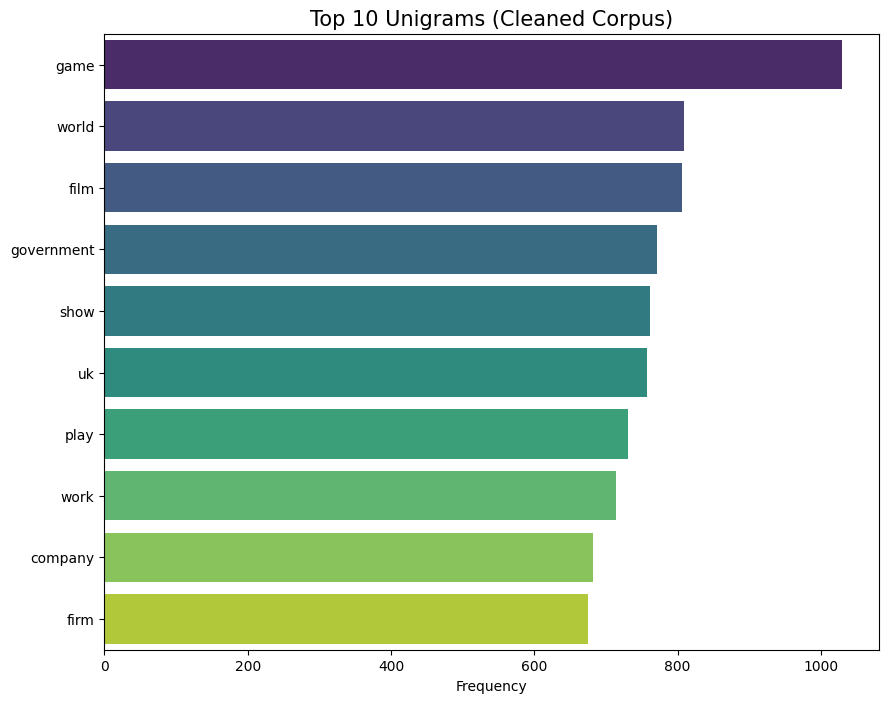

In [78]:
#Plotting Top 10 final cleaned corpus Unigrams
words, counts = zip(*top_unigrams_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)
plt.title("Top 10 Unigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Visualizing Top 10 Bigrams (Final Cleaned corpus) for bbcnews

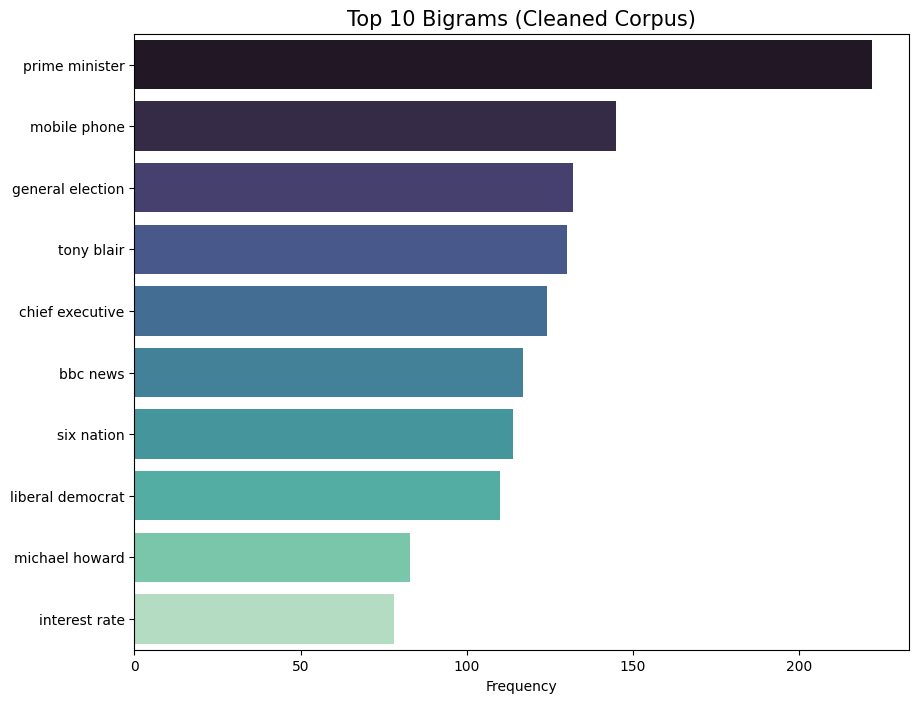

In [79]:
#Plotting Top 10 final cleaned corpus Bigrams
words, counts = zip(*top_bigrams_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="mako", legend=False)
plt.title("Top 10 Bigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Visualizing Top 10 Trigrams (Final Cleaned corpus) for bbcnews

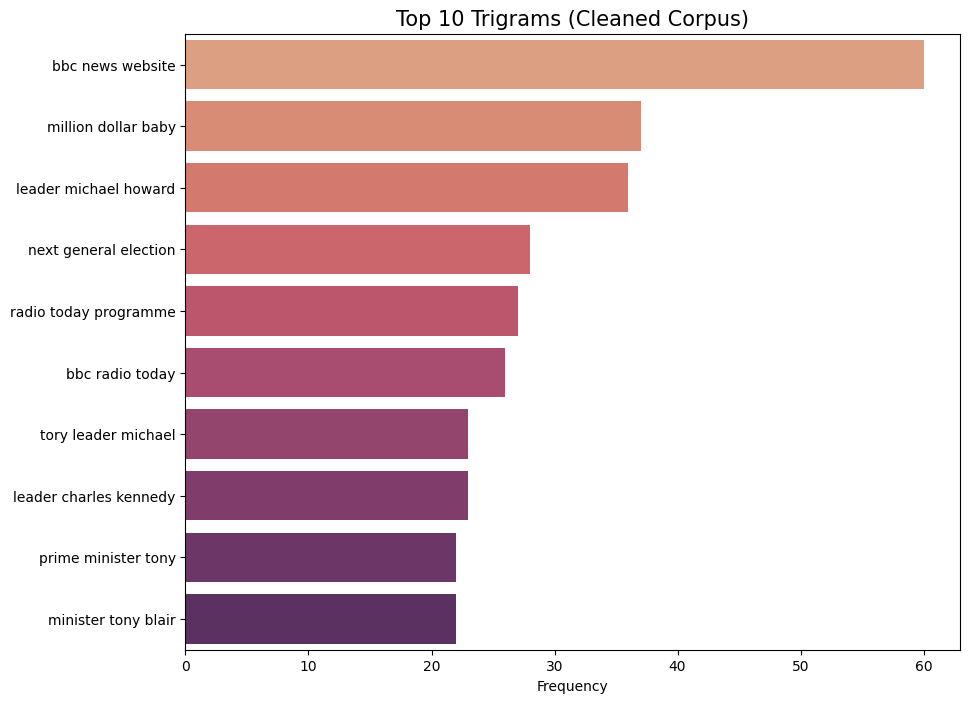

In [80]:
#Plotting Top 10 final cleaned corpus Trigrams
words, counts = zip(*top_trigrams_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="flare", legend=False)
plt.title("Top 10 Trigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Wordcloud for bbcnews

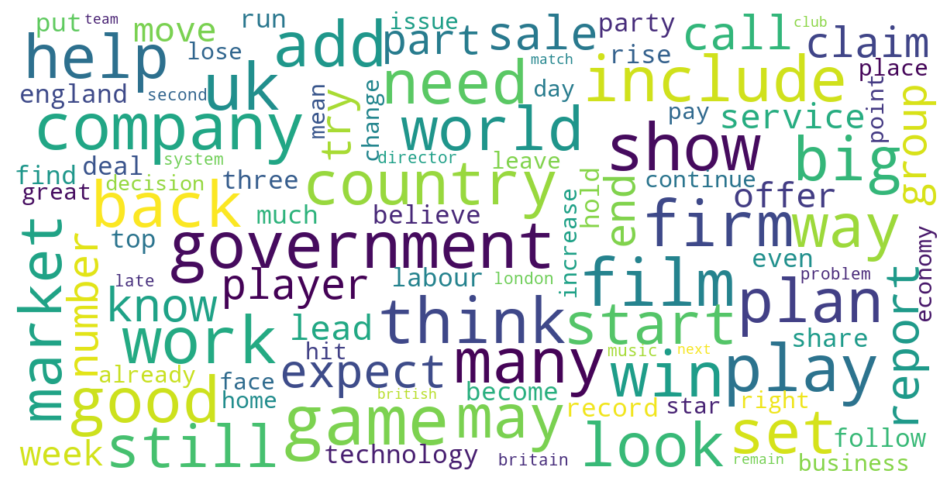

In [81]:
from wordcloud import WordCloud, STOPWORDS as workcloud_stopwords_bbcnews

stopwords = set(STOPWORDS)

def show_wordcloud(data):
    #Combining the list of strings into one single string (if it not already)
    if isinstance(data, pd.Series):
        text = ' '.join(data.astype(str))
    elif isinstance(data, list):
        text = ' '.join(data)
    else:
        text = str(data)

    
    #Configuring the WordCloud
    wordcloud = WordCloud(
        background_color='white',
        stopwords=workcloud_stopwords_bbcnews,
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1
    )

    #Generating the word cloud
    wordcloud.generate(text)

    #Plotting the image
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    plt.imshow(wordcloud, interpolation='bilinear') 
    plt.show()

#Calling the function with the corpus
show_wordcloud(corpus_bbcnews)

##### Re-aligning final corpus with the original labels (category and ground truth) for bbcnews

In [82]:
#Keeping only rows where the cleaned text of column "final_lemmatized_cleaned_sentence" has length greater than 0
df_sentence_bbcnews = df_sentence_bbcnews[df_sentence_bbcnews["final_clean_corpus"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "final_lemmatized_cleaned_sentence"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_sentence_bbcnews)}")

#Re-aligning with the original labels (category and ground truth labels)
final_df_bbcnews = df_sentence_bbcnews.merge(
    full_df_bbcnews[['category']], 
    left_index=True, 
    right_index=True
)

#Dropping duplicates based on both text and label
duplicate_count = final_df_bbcnews.duplicated(subset=["final_clean_corpus", "category"]).sum()
print(f"Number of duplicate rows dropped: {duplicate_count}")
final_df_bbcnews.drop_duplicates(subset=["final_clean_corpus", "category"], inplace=True)

#Resetting index
final_df_bbcnews.reset_index(drop=True, inplace=True)

#Final rows in cleaned column after indexing reset
print(f"Final rows in corpus column with name final_clean_corpus is: {len(final_df_bbcnews)}")
print(f"Final rows in final merged dataframe of bbcnews: {len(final_df_bbcnews)}")
print(f"Final shape for modeling: {final_df_bbcnews.shape}")
print(' ')

#Updating corpus
corpus_bbcnews = final_df_bbcnews["final_clean_corpus"]

#display(final_df_sentence_bbcnews.head())

Rows after removing empty rows in finally cleaned text column: 1490
Number of duplicate rows dropped: 54
Final rows in corpus column with name final_clean_corpus is: 1436
Final rows in final merged dataframe of bbcnews: 1436
Final shape for modeling: (1436, 8)
 


##### Topic Modelling for bbcnews

In [83]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model

#Grabbing latest cleaned corpus
corpus_final_bbcnews = corpus_bbcnews

#Re-vectorizing the text 
tf_vectorizer = CountVectorizer(stop_words=None,
                                max_df=0.85,    #Ignoring words that appear in >85% of documents
                                min_df=2,       #Ignoring words that appear in less than 2 documents
                                token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')
    
tf = tf_vectorizer.fit_transform(corpus_final_bbcnews)

#Re-initializing and fitting the LDA model for 5 topics.
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Displaying the dashboard
pyLDAvis.display(panel)

##### Visualizing updated distribution of word count per final cleaned sentence for bbcnews

Mean Word Count: 190.00
Median Word Count: 168.00


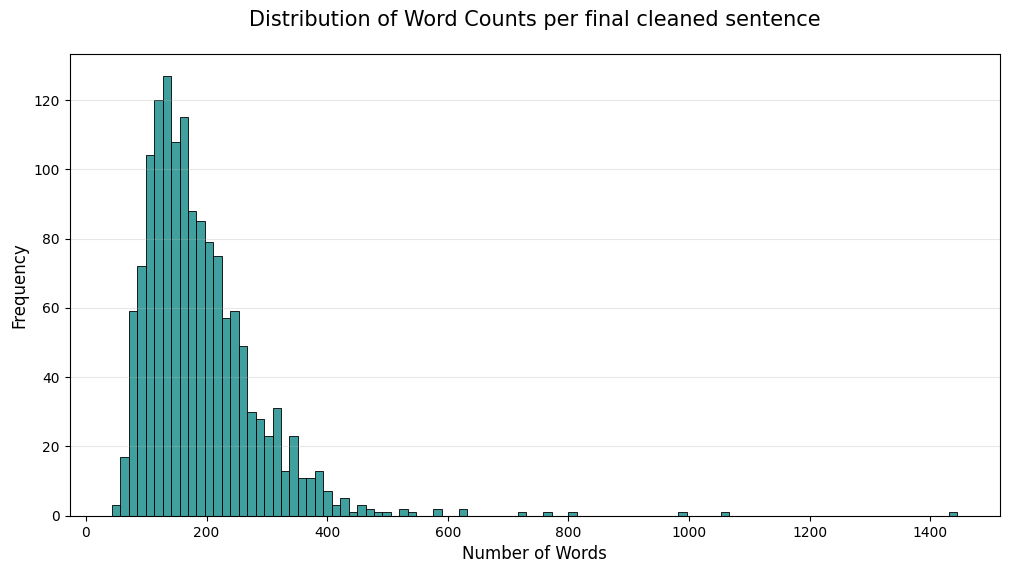

In [84]:
#Calculating updated word counts by splitting strings into lists
final_df_bbcnews["word_count"] = final_df_bbcnews["final_clean_corpus"].str.split().str.len()

#Calculating key statistics
mean_words = final_df_bbcnews["word_count"].mean().round()
median_words = final_df_bbcnews["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(final_df_bbcnews["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per final cleaned sentence", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Visualizing updated Distribution of Article Lengths (Character Count) for bbcnews

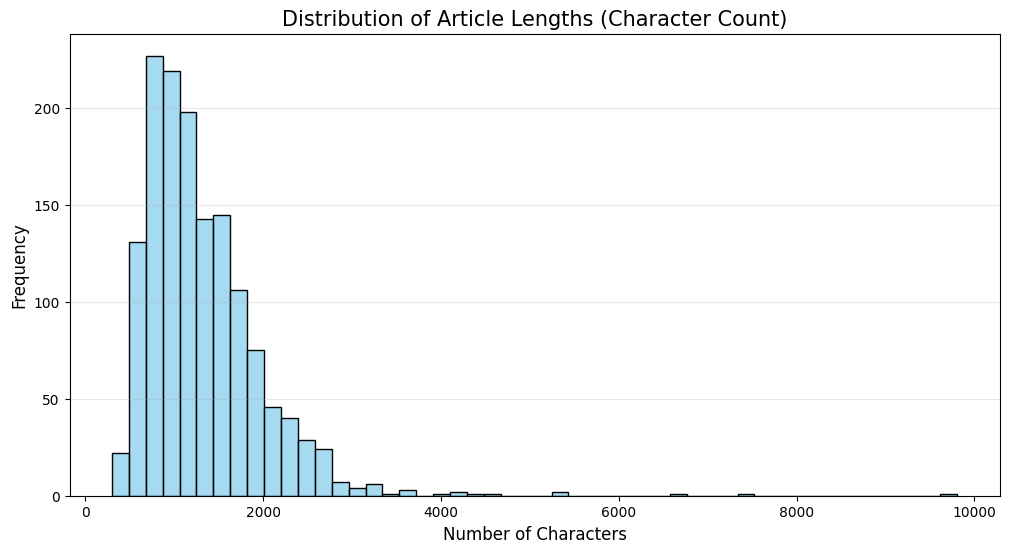

In [85]:
#Checking the number of characters present in each sentence to have a rough idea about the text headline length
#Calculating sentence lengths
final_df_bbcnews["char_count"] = final_df_bbcnews["final_clean_corpus"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(final_df_bbcnews["char_count"], bins=50, color="skyblue")
plt.title("Distribution of Article Lengths (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Visualizing updated average word length in each Sentence for bbcnews

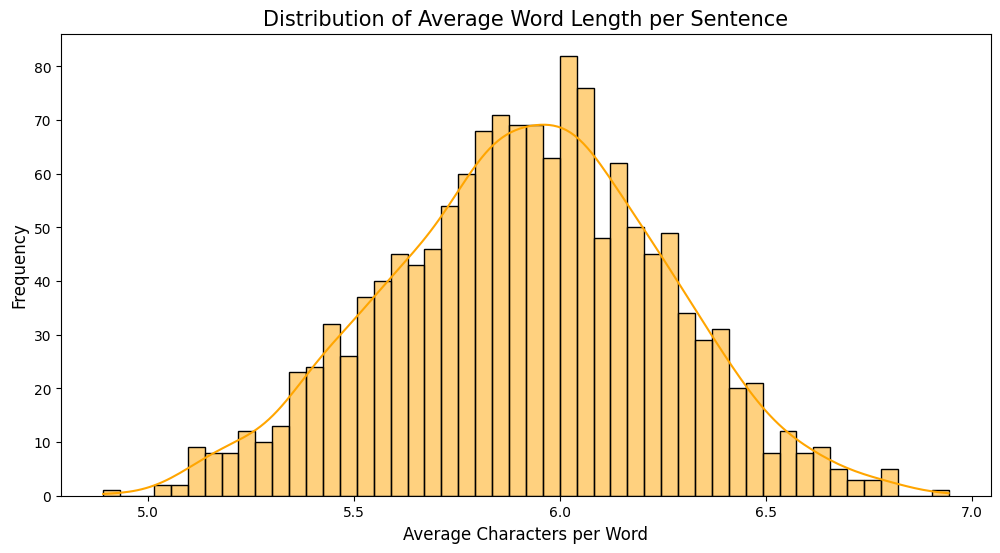

In [86]:
def get_avg_word_len(text):
    """Function to calculating average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

final_df_bbcnews['avg_word_len'] = final_df_bbcnews['final_clean_corpus'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(final_df_bbcnews['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per Sentence", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

***

#### Vectorization

##### Tokenizing the final cleaned corpus into lists of words

In [87]:
#Tokenizing the final cleaned corpus into lists of words
tokenized_corpus_20newsgroups = [doc.split() for doc in corpus_20newsgroups]

print(f"Number of documents: {len(tokenized_corpus_20newsgroups)}")
print(f"Sample tokens: {tokenized_corpus_20newsgroups[0][:10]}")

Number of documents: 1818
Sample tokens: ['current', 'moto', 'national', 'owner', 'club', 'address', 'please', 'email', 'thanks', 'advance']


##### Vectorization & Clustering for 20newsgroups dataframe

###### Vectorization for 20newsgroups dataframe with TD-IF

###### TF-IDF creates a sparse matrix where each document is a vector of weighted word scores. Words that are frequent in a doc but rare across the corpus get higher weights.

In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

#TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

#Fitting and transforming the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_20newsgroups)

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
#Output → (n_documents, feature_rows) sparse matrix that only stores the locations and values of the non-zero element

#Converting to a dense DataFrame that stores everything
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

display(tfidf_df.head())

TF-IDF Matrix Shape: (1818, 10754)


,aa,aaa,aaron,ab,abandon,abbreviationsacronyms,abc,abcs,abduct,abe,...,zeus,zilfi,zinc,zionism,zionist,zip,zone,zoom,zsh,zuni
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.033146,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


###### Vectorization for 20newsgroups dataframe with Word2Vec

In [89]:
#Word2Vec vectorizer in tokenized corpus
w2v_model = Word2Vec(
    sentences=tokenized_corpus_20newsgroups,
    vector_size=200,    #Embedding dimensions
    window=5,           #Context window size (words left & right)
    min_count=2,        #Ignoring words with fewer than 2 occurrences
    workers=4,          #Parallel threads
    sg=0,               #1 = Skip-gram, 0 = CBOW
    epochs=10,          #Training iterations
    seed=42
)

print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")
print(f"Sample vector for 'computer': {w2v_model.wv['computer'][:5]}...")  

#Most similar words check
print(w2v_model.wv.most_similar('computer', topn=5))


#Averaging the word vectors per document to get document-level embeddings
def get_w2v_document_vector(tokens, model, vector_size=200):
    """
    Averages the Word2Vec vectors for all known words in a document.
    Returns a zero vector if no words are found in the vocabulary.
    """
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

#Generating document vectors
w2v_vectors = np.array([
    get_w2v_document_vector(tokens, w2v_model, vector_size=200)
    for tokens in tokenized_corpus_20newsgroups
])

print(f"Word2Vec Document Matrix Shape: {w2v_vectors.shape}")
#Output → (n_documents, 200) sparse matrix that only stores the locations and values of the non-zero element

Word2Vec vocabulary size: 10282
Sample vector for 'computer': [ 0.47052237  0.07969937 -0.22964625 -0.01945895 -0.02809082]...
[('exportlcsmitedu', 0.9977392554283142), ('multiple', 0.9975016713142395), ('access', 0.9974826574325562), ('copy', 0.9971659779548645), ('linux', 0.9970501065254211)]
Word2Vec Document Matrix Shape: (1818, 200)


###### Vectorization for 20newsgroups dataframe with FastText

In [90]:
#FastText vectorizer on the tokenized corpus
ft_model = FastText(
    sentences=tokenized_corpus_20newsgroups,
    vector_size=200,    #Same embedding size as Word2Vec for comparability
    window=5,           #Context window size (words left & right)
    min_count=2,        #Ignoring words with fewer than 2 occurrences
    workers=4,          #Parallel threads
    sg=0,               #1 = Skip-gram, 0 = CBOW
    epochs=10,          #Training iterations
    seed=42
)

print(f"FastText vocabulary size: {len(ft_model.wv)}")

#FastText can handle OOV (out-of-vocabulary) words via subword decomposition
print(ft_model.wv.most_similar('computer', topn=5))

#Averaging the word vectors per document to get document-level embeddings
def get_ft_document_vector(tokens, model, vector_size=200):
    """
    FastText handles OOV words natively via subword info,
    so no need to check vocabulary membership explicitly.
    """
    vectors = [model.wv[word] for word in tokens]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

#Generating document vectors
ft_vectors = np.array([
    get_ft_document_vector(tokens, ft_model, vector_size=200)
    for tokens in tokenized_corpus_20newsgroups
])

print(f"FastText Document Matrix Shape: {ft_vectors.shape}")
#Output → (n_documents, 200) sparse matrix that only stores the locations and values of the non-zero element

FastText vocabulary size: 10282
[('compiler', 0.9995028376579285), ('winter', 0.9994845390319824), ('telegram', 0.9994467496871948), ('ofbmode', 0.9993185997009277), ('keycode', 0.9993138909339905)]
FastText Document Matrix Shape: (1818, 200)


In [91]:
#Storing vector representations back to the main DataFrame
final_df_20newsgroups['tfidf_vector'] = list(tfidf_matrix.toarray())
final_df_20newsgroups['w2v_vector']   = list(w2v_vectors)
final_df_20newsgroups['ft_vector']    = list(ft_vectors)

print("All three vectorizations complete and stored in final_df_20newsgroups.")
#display(final_df_20newsgroups[['final_checked_corpus', 'tfidf_vector', 'w2v_vector', 'ft_vector']].head())

All three vectorizations complete and stored in final_df_20newsgroups.


In [92]:
from sklearn.preprocessing import normalize
from scipy.sparse import issparse

#Collecting all three vectorizations with labels
vectorizations = {
    "TF-IDF":    tfidf_matrix,    #sparse matrix → shape (n_docs, 10751)
    "Word2Vec":  w2v_vectors,     #dense array  → shape (n_docs, 200)
    "FastText":  ft_vectors       #dense array  → shape (n_docs, 200)
}

#Normalizing each (L2 norm) — converting sparse to dense for clustering compatibility
normalized_vectorizations = {}

for name, matrix in vectorizations.items():
    if issparse(matrix):
        #Converting sparse TF-IDF matrix to dense before normalizing
        matrix = matrix.toarray()
    normalized_vectorizations[name] = normalize(matrix, norm='l2')
    print(f"{name} normalized shape: {normalized_vectorizations[name].shape}")

TF-IDF normalized shape: (1818, 10754)
Word2Vec normalized shape: (1818, 200)
FastText normalized shape: (1818, 200)


In [93]:
#Identifying rows where all values are 0 (empty document vectors) and removes them from the matrix and saves them in new dictionary

clean_normalized_vectorizations = {}

for vec_name, X_norm in normalized_vectorizations.items():
    #Identifying rows where ALL values are 0 (empty document vectors)
    non_zero_mask = np.any(X_norm != 0, axis=1)
    n_removed = (~non_zero_mask).sum()

    clean_normalized_vectorizations[vec_name] = {
        'matrix': X_norm[non_zero_mask],
        'mask':   non_zero_mask
    }
    print(f"{vec_name}: {n_removed} zero vectors removed → {non_zero_mask.sum()} docs remaining")


TF-IDF: 1 zero vectors removed → 1817 docs remaining
Word2Vec: 0 zero vectors removed → 1818 docs remaining
FastText: 0 zero vectors removed → 1818 docs remaining


***

#### Clustering

###### Clustering for 20newsgroups dataframe without PCA

###### Clustering for 20newsgroups dataframe with TF-IDF without PCA

###### Clustering for 20newsgroups dataframe with TF-IDF without PCA for k=20 (number of the ground truth labels)

In [94]:
#Extracting the cleaned, normalized TF-IDF matrix
tfidf_data_20newsgroups = clean_normalized_vectorizations["TF-IDF"]['matrix']

kmeans_20_20newsgroups = KMeans(
    n_clusters=20,     #number of clusters
    init='k-means++',  #initialization method ('k-means++' because it is better for convergence)
    n_init=10,         #number of initializations to run
    max_iter=300,      #maximum iterations for a single run
    tol=1e-4,          #convergence threshold
    random_state=42    #seed for reproducibility
)
kmeans_20_20newsgroups.fit(tfidf_data_20newsgroups)

#Clustering assignments
labels = kmeans_20_20newsgroups.labels_

#Clustering centers
centroids = kmeans_20_20newsgroups.cluster_centers_

#Calculating and printing the silhouette score
sil_score_20_20newsgroups = silhouette_score(
    tfidf_data_20newsgroups, 
    labels
)

#Mapping labels back to the original dataframe
#tfidf_mask_20newsgroups = clean_normalized_vectorizations["TF-IDF"]['mask']
#final_df_20newsgroups.loc[tfidf_mask_20newsgroups, 'kmeans_20_tfidf_label'] = kmeans_20_20newsgroups.labels_

print(f"Matrix shape fitted: {tfidf_data_20newsgroups.shape}")
print(f"Unique clusters assigned: {len(set(labels))}")
print(f"Silhouette Score (k=20): {sil_score_20_20newsgroups:.4f}")

Matrix shape fitted: (1817, 10754)
Unique clusters assigned: 20
Silhouette Score (k=20): 0.0065


###### Elbow plot for 20newsgroups dataframe with TF-IDF without PCA to find potential elbow points for best k 

k= 1 | Inertia: 1799.07
k= 2 | Inertia: 1791.88
k= 3 | Inertia: 1786.63
k= 4 | Inertia: 1780.55
k= 5 | Inertia: 1776.41
k= 6 | Inertia: 1771.59
k= 7 | Inertia: 1769.35
k= 8 | Inertia: 1763.85
k= 9 | Inertia: 1761.94
k=10 | Inertia: 1761.48
k=11 | Inertia: 1755.56
k=12 | Inertia: 1751.54
k=13 | Inertia: 1749.66
k=14 | Inertia: 1748.25
k=15 | Inertia: 1744.82
k=16 | Inertia: 1744.71
k=17 | Inertia: 1740.26
k=18 | Inertia: 1737.75
k=19 | Inertia: 1735.42
k=20 | Inertia: 1732.81
k=21 | Inertia: 1730.48
k=22 | Inertia: 1731.87
k=23 | Inertia: 1729.34
k=24 | Inertia: 1729.37
k=25 | Inertia: 1727.01


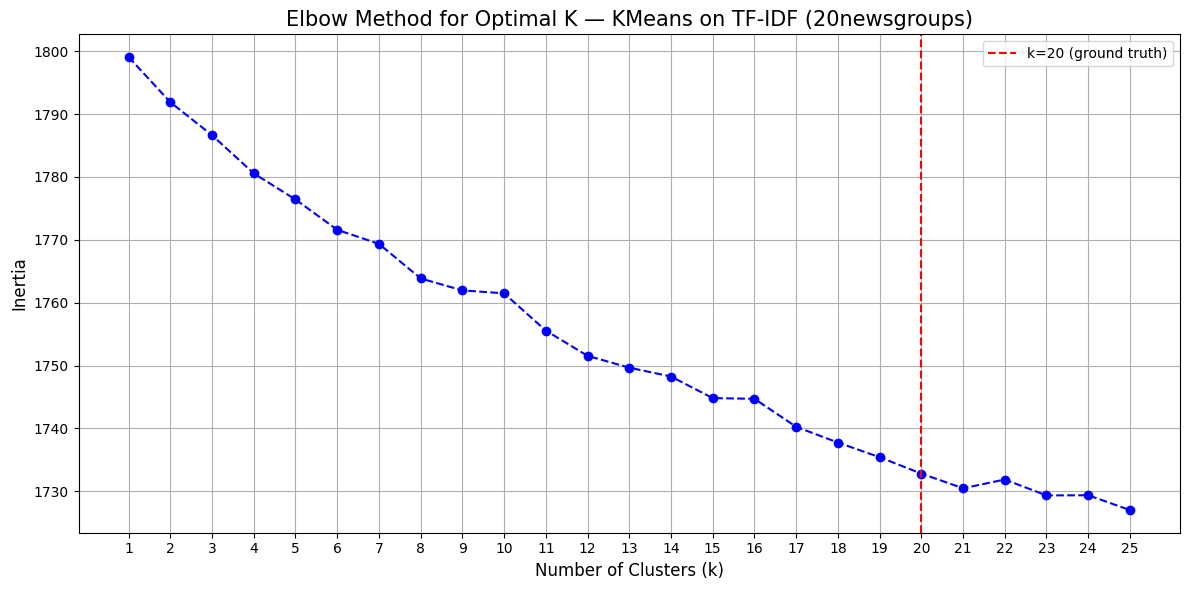

In [95]:
k_values = range(1, 26)
inertia_values = []

#Computing KMeans for each k and storing inertia
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    kmeans.fit(tfidf_data_20newsgroups)  
    inertia_values.append(kmeans.inertia_)
    print(f"k={k:2d} | Inertia: {kmeans.inertia_:.2f}") #printing inertia for each k

#Plotting the Elbow Curve
plt.figure(figsize=(12, 6))
plt.plot(k_values, inertia_values,
         marker='o',
         linestyle='--',
         color='b')

#Adding a vertical line at k=20 (ground truth number of categories)
plt.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='k=20 (ground truth)')

plt.title("Elbow Method for Optimal K — KMeans on TF-IDF (20newsgroups)", fontsize=15)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

###### Silhouette plot for 20newsgroups dataframe with TF-IDF without PCA to find optimal number of k 

k= 2 | Silhouette Score: 0.0026
k= 3 | Silhouette Score: 0.0027
k= 4 | Silhouette Score: 0.0033
k= 5 | Silhouette Score: 0.0037
k= 6 | Silhouette Score: 0.0039
k= 7 | Silhouette Score: 0.0038
k= 8 | Silhouette Score: 0.0044
k= 9 | Silhouette Score: 0.0049
k=10 | Silhouette Score: 0.0040
k=11 | Silhouette Score: 0.0053
k=12 | Silhouette Score: 0.0052
k=13 | Silhouette Score: 0.0052
k=14 | Silhouette Score: 0.0052
k=15 | Silhouette Score: 0.0057
k=16 | Silhouette Score: 0.0053
k=17 | Silhouette Score: 0.0061
k=18 | Silhouette Score: 0.0066
k=19 | Silhouette Score: 0.0063
k=20 | Silhouette Score: 0.0065
k=21 | Silhouette Score: 0.0060
k=22 | Silhouette Score: 0.0062
k=23 | Silhouette Score: 0.0066
k=24 | Silhouette Score: 0.0057
k=25 | Silhouette Score: 0.0061


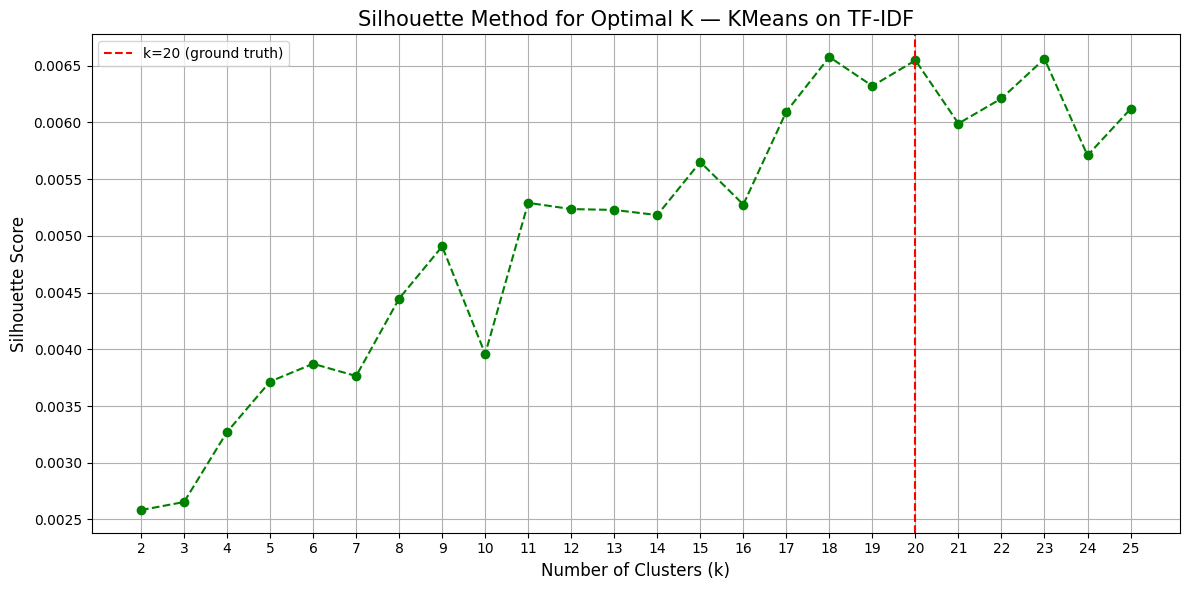

In [96]:
#Range of cluster numbers to evaluate (starting from k=2 up to 26)
k_values_sil = range(2, 26) 
silhouette_scores = []

#Computing KMeans for each k and storing the silhouette score
for k in k_values_sil:
    kmeans = KMeans(
        n_clusters=k, 
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    
    labels = kmeans.fit_predict(tfidf_data_20newsgroups)

    #Sampling 5000 to prevent memory overload
    score = silhouette_score(
        tfidf_data_20newsgroups, 
        labels, 
        sample_size=5000, 
        random_state=42
    )
    silhouette_scores.append(score)
    print(f"k={k:2d} | Silhouette Score: {score:.4f}")

#Plotting the Silhouette Score Curve
plt.figure(figsize=(12, 6))
plt.plot(k_values_sil, silhouette_scores, marker='o', linestyle='--', color='g')

#Adding a vertical line at k=20 (ground truth)
plt.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='k=20 (ground truth)')

plt.title("Silhouette Method for Optimal K — KMeans on TF-IDF", fontsize=15)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(k_values_sil)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

###### Clustering for 20newsgroups dataframe with TF-IDF without PCA for k=18 (optimal found in Silhouette plot)

###### Mapping the optimal labels for TF-IDF method back to the original dataframe for 20newsgroups

In [97]:
kmeans_18_20newsgroups = KMeans(
    n_clusters=18,     #number of clusters
    init='k-means++',  #initialization method ('k-means++' because it is better for convergence)
    n_init=10,         #number of initializations to run
    max_iter=300,      #maximum iterations for a single run
    tol=1e-4,          #convergence threshold
    random_state=42    #seed for reproducibility
)
kmeans_18_20newsgroups.fit(tfidf_data_20newsgroups)

#Clustering assignments
labels = kmeans_18_20newsgroups.labels_

#Clustering centers
centroids = kmeans_18_20newsgroups.cluster_centers_

#Calculating and printing the silhouette score
sil_score_18_20newsgroups = silhouette_score(
    tfidf_data_20newsgroups, 
    labels
)

#Mapping labels back to the original dataframe
#tfidf_mask_20newsgroups = clean_normalized_vectorizations["TF-IDF"]['mask']
#final_df_20newsgroups.loc[tfidf_mask_20newsgroups, 'kmeans_18_tfidf_label'] = labels

print(f"Matrix shape fitted: {tfidf_data_20newsgroups.shape}")
print(f"Unique clusters assigned: {len(set(labels))}")
print(f"Silhouette Score (k=18): {sil_score_18_20newsgroups:.4f}")

Matrix shape fitted: (1817, 10754)
Unique clusters assigned: 18
Silhouette Score (k=18): 0.0066


In [98]:
#Choosing as optimal not the k=18 found per silhouette plot but the k=20 which is exactly like the ground truth labels
#as the difference aslo in silhouette score is very small between these two k and the importance of the impact in terms of ground truth big.

#Mapping labels back to the original dataframe
tfidf_mask_20newsgroups = clean_normalized_vectorizations["TF-IDF"]['mask']
final_df_20newsgroups.loc[tfidf_mask_20newsgroups, 'kmeans_18_tfidf_label'] = kmeans_18_20newsgroups.labels_

###### Ground Truth Label Reference for 20newsgroups (integers conversion to category names) for 20newsgroups

In [99]:
print("GROUND TRUTH LABEL REFERENCE (integers → category names) ")
print("NOTE: These integers are ground truth IDs. KMeans cluster or other Clustering algorithm 0 ≠ category 0.\n")
category_mapping = dict(enumerate(labels_names_20newsgroups))
for num, name in category_mapping.items():
    print(f"  Ground Truth Label {num:2d} : {name}")

GROUND TRUTH LABEL REFERENCE (integers → category names) 
NOTE: These integers are ground truth IDs. KMeans cluster or other Clustering algorithm 0 ≠ category 0.

  Ground Truth Label  0 : alt.atheism
  Ground Truth Label  1 : comp.graphics
  Ground Truth Label  2 : comp.os.ms-windows.misc
  Ground Truth Label  3 : comp.sys.ibm.pc.hardware
  Ground Truth Label  4 : comp.sys.mac.hardware
  Ground Truth Label  5 : comp.windows.x
  Ground Truth Label  6 : misc.forsale
  Ground Truth Label  7 : rec.autos
  Ground Truth Label  8 : rec.motorcycles
  Ground Truth Label  9 : rec.sport.baseball
  Ground Truth Label 10 : rec.sport.hockey
  Ground Truth Label 11 : sci.crypt
  Ground Truth Label 12 : sci.electronics
  Ground Truth Label 13 : sci.med
  Ground Truth Label 14 : sci.space
  Ground Truth Label 15 : soc.religion.christian
  Ground Truth Label 16 : talk.politics.guns
  Ground Truth Label 17 : talk.politics.mideast
  Ground Truth Label 18 : talk.politics.misc
  Ground Truth Label 19 : tal

In [100]:
#Clustering size sanity check
print("Kmeans Cluster Distribution with TF-IDF (k=18)")
print(final_df_20newsgroups['kmeans_18_tfidf_label'].value_counts().sort_index())

#Crosstabing — what matters is what's inside each cluster
contingency_matrix_tfidf_18 = pd.crosstab(
    final_df_20newsgroups['category'],
    final_df_20newsgroups['kmeans_18_tfidf_label'],
    margins=True,
    margins_name='Total'
)
print("Contingency table")
print(contingency_matrix_tfidf_18)

#Normalized version (what % of each category ended up in each cluster)
contingency_normalized_tfidf_18 = pd.crosstab(
    final_df_20newsgroups['category'],
    final_df_20newsgroups['kmeans_18_tfidf_label'],
    normalize='index'
).round(2)
print("Normalized version (% of each category per cluster)")
print(contingency_normalized_tfidf_18)

Kmeans Cluster Distribution with TF-IDF (k=18)
kmeans_18_tfidf_label
0.0     387
1.0     177
2.0      55
3.0     108
4.0     194
5.0      73
6.0      66
7.0      56
8.0      60
9.0      85
10.0     68
11.0     48
12.0     42
13.0    110
14.0     51
15.0     76
16.0    103
17.0     58
Name: count, dtype: int64
Contingency table
kmeans_18_tfidf_label     0.0  1.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  9.0  \
category                                                                     
alt.atheism                15    7    4    0   22    9    2    0    0    8   
comp.graphics              25    0    4   22   16    0    4    1    0    0   
comp.os.ms-windows.misc    14    0    2   34    6    0    4    1    0    1   
comp.sys.ibm.pc.hardware   12    1    1    5    2    0    2    7    0    1   
comp.sys.mac.hardware      15    0    2    2    1    0    1    3    0    0   
comp.windows.x             25    0    3   35    7    0    1    0    0    3   
misc.forsale               25    0    2    2   

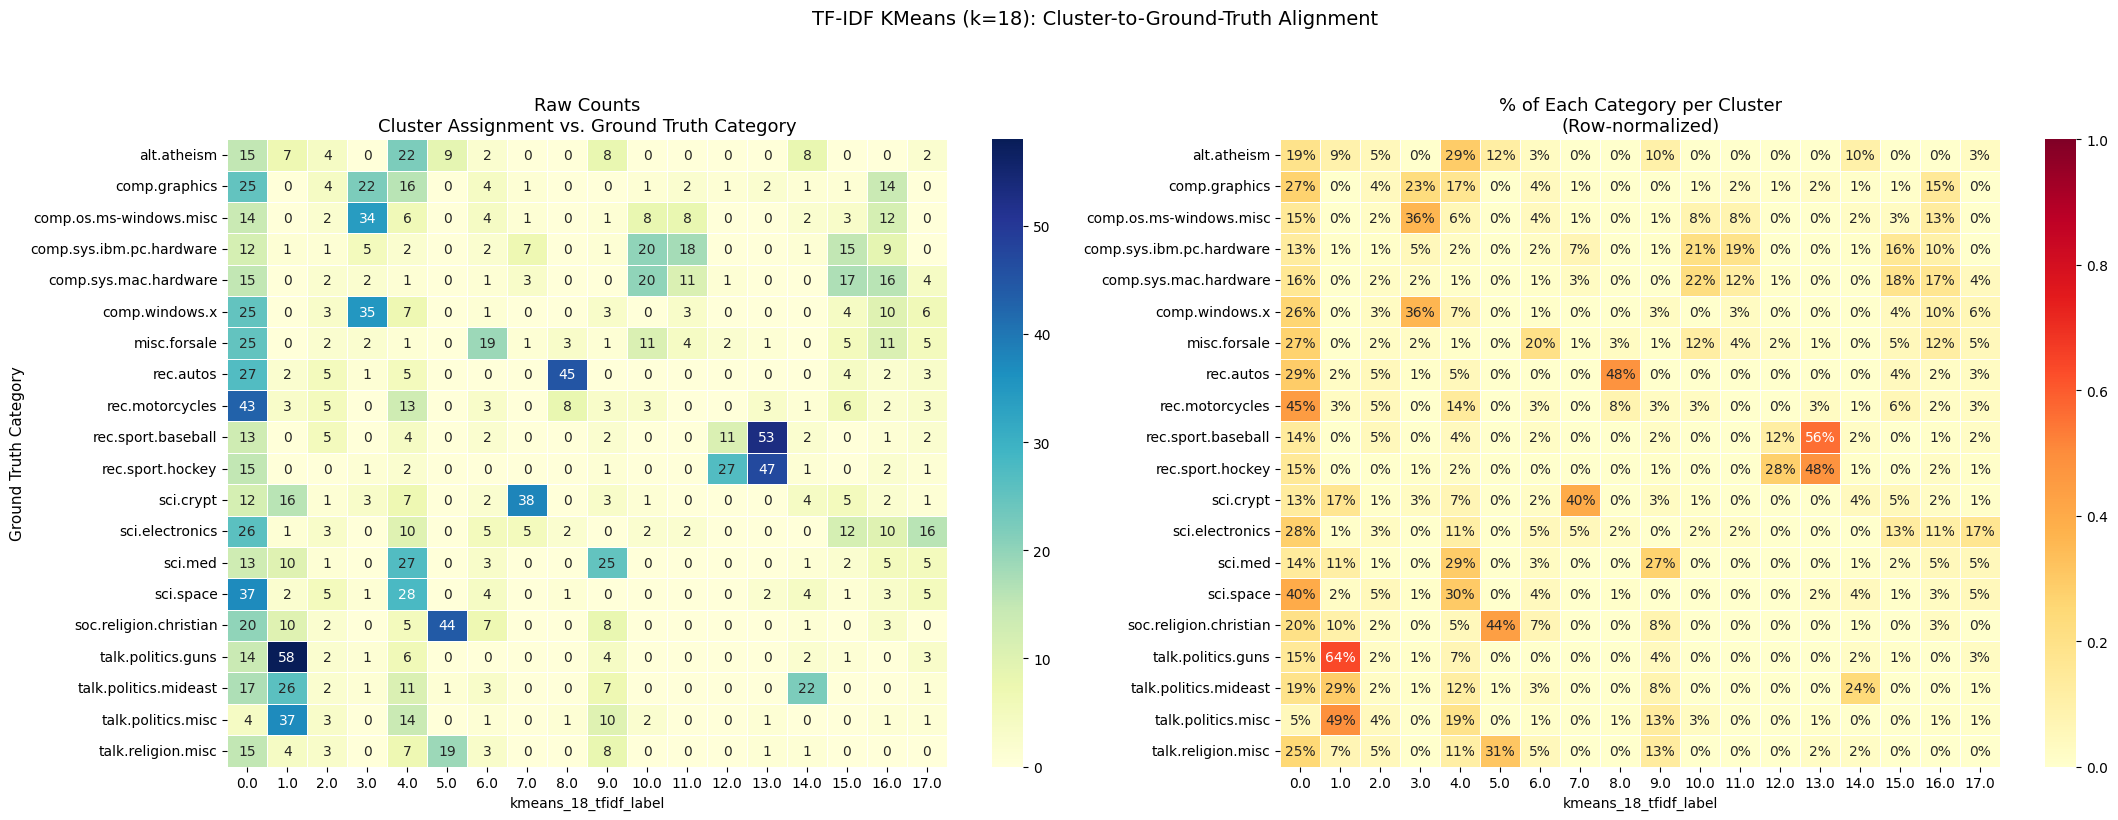

In [101]:
#Plotting both heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

#Raw counts
sns.heatmap(
    contingency_matrix_tfidf_18.iloc[:-1, :-1],
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Raw Counts\nCluster Assignment vs. Ground Truth Category", fontsize=13)
axes[0].set_ylabel("Ground Truth Category", fontsize=11)

#Normalized
sns.heatmap(
    contingency_normalized_tfidf_18,
    annot=True,
    fmt='.0%',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_title("% of Each Category per Cluster\n(Row-normalized)", fontsize=13)
axes[1].set_ylabel("")

plt.suptitle(
    "TF-IDF KMeans (k=18): Cluster-to-Ground-Truth Alignment\n",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

In [102]:
#Dominant cluster per category
print("Dominant Cluster per Category")
print("(Which cluster captured the majority of each category's documents?)\n")
dominant_tfidf_18 = contingency_normalized_tfidf_18.idxmax(axis=1).rename("dominant_cluster")
pct_tfidf_18      = contingency_normalized_tfidf_18.max(axis=1).rename("pct_in_dominant_cluster")
summary_tfidf_18  = pd.concat([dominant_tfidf_18, pct_tfidf_18], axis=1).sort_values("dominant_cluster")
print(summary_tfidf_18.to_string())

Dominant Cluster per Category
(Which cluster captured the majority of each category's documents?)

                          dominant_cluster  pct_in_dominant_cluster
category                                                           
comp.graphics                          0.0                     0.27
misc.forsale                           0.0                     0.27
sci.electronics                        0.0                     0.28
rec.motorcycles                        0.0                     0.45
sci.space                              0.0                     0.40
talk.politics.misc                     1.0                     0.49
talk.politics.mideast                  1.0                     0.29
talk.politics.guns                     1.0                     0.64
comp.os.ms-windows.misc                3.0                     0.36
comp.windows.x                         3.0                     0.36
sci.med                                4.0                     0.29
alt.atheism      

In [103]:
def get_semantic_label(dominant_names):
    """Infers a human-readable theme from dominant category names."""
    comp_count  = sum(1 for c in dominant_names if c.startswith("comp"))
    rec_count   = sum(1 for c in dominant_names if c.startswith("rec"))
    talk_count  = sum(1 for c in dominant_names if c.startswith("talk"))
    sci_count   = sum(1 for c in dominant_names if c.startswith("sci"))
    soc_count   = sum(1 for c in dominant_names if c.startswith("soc"))
    misc_count  = sum(1 for c in dominant_names if c.startswith("misc") or c.startswith("alt"))

    tags = []
    if comp_count  >= 2: tags.append("Computer/Tech")
    if rec_count   >= 2: tags.append("Recreation/Sports")
    if talk_count  >= 2: tags.append("Politics")
    if sci_count   >= 2: tags.append("Science")
    if soc_count   >= 1: tags.append("Religion/Society")
    if misc_count  >= 1: tags.append("Misc/Culture")

    return " + ".join(tags) if tags else "Mixed"

In [104]:
#Pre-computing all cluster info in one pass
DOMINANCE_THRESHOLD = 0.60
n_clusters_tfidf_18 = int(contingency_normalized_tfidf_18.columns.max()) + 1

cluster_info_tfidf_18 = {}

for cluster_id in range(n_clusters_tfidf_18):
    col            = float(cluster_id)
    cluster_series = contingency_normalized_tfidf_18[col].sort_values(ascending=False)
    dominant       = cluster_series[cluster_series >= DOMINANCE_THRESHOLD]
    dominant_names = dominant.index.tolist()

    cluster_info_tfidf_18[cluster_id] = {
        'series'         : cluster_series,
        'dominant'       : dominant,
        'dominant_names' : dominant_names,
        'semantic_label' : get_semantic_label(dominant_names),  # already defined, not redefined
        'n_dominant'     : len(dominant),
        'top5'           : dominant.head(5)
    }

#Detailed per-cluster breakdown
print("-" * 60)
print("Clusters composition for Kmeans with optimal k=18 for TF-IDF")
print("-" * 60)

for cluster_id, info in cluster_info_tfidf_18.items():
    print(f"\nCluster {cluster_id} → Top categories (≥{DOMINANCE_THRESHOLD:.0%} of their docs landed here):")
    print(f"  {'Category':<35} {'% in Cluster ' + str(cluster_id)}")
    print(f"  {'-' * 50}")

    if info['top5'].empty:
        print(f"  No category sent ≥{DOMINANCE_THRESHOLD:.0%} of its docs here.")
    else:
        for category, pct in info['top5'].items():
            print(f"  {category:<35} {pct:.0%}")

    print(f"\n  → Auto-detected theme  : [{info['semantic_label']}]")
    print(f"  → Dominant categories  : {info['n_dominant']}")

#Summary Table
print(f"\n{'-' * 60}")
print("Verdict for TF-IDF with optimal k=18 for Kmeans")
print(f"{'-' * 60}")
print(f"  {'Cluster':<12} {'Theme':<40} {'# Dominant Categories'}")
print(f"  {'-' * 65}")

for cluster_id, info in cluster_info_tfidf_18.items():
    print(f"  Cluster {cluster_id:<4} {info['semantic_label']:<40} {info['n_dominant']}")

------------------------------------------------------------
Clusters composition for Kmeans with optimal k=18 for TF-IDF
------------------------------------------------------------

Cluster 0 → Top categories (≥60% of their docs landed here):
  Category                            % in Cluster 0
  --------------------------------------------------
  No category sent ≥60% of its docs here.

  → Auto-detected theme  : [Mixed]
  → Dominant categories  : 0

Cluster 1 → Top categories (≥60% of their docs landed here):
  Category                            % in Cluster 1
  --------------------------------------------------
  talk.politics.guns                  64%

  → Auto-detected theme  : [Mixed]
  → Dominant categories  : 1

Cluster 2 → Top categories (≥60% of their docs landed here):
  Category                            % in Cluster 2
  --------------------------------------------------
  No category sent ≥60% of its docs here.

  → Auto-detected theme  : [Mixed]
  → Dominant categori

***

###### Clustering for 20newsgroups dataframe without PCA

###### Clustering for 20newsgroups dataframe with Word2Vec without PCA

###### Clustering for 20newsgroups dataframe with Word2Vec without PCA for k=20 (number of the ground truth labels)

In [105]:
#Extracting the cleaned, normalized Word2Vec matrix
w2vec_data_20newsgroups = clean_normalized_vectorizations["Word2Vec"]['matrix']

kmeans_20_20newsgroups = KMeans(
    n_clusters=20,     #number of clusters
    init='k-means++',  #initialization method ('k-means++' because it is better for convergence)
    n_init=10,         #number of initializations to run
    max_iter=300,      #maximum iterations for a single run
    tol=1e-4,          #convergence threshold
    random_state=42    #seed for reproducibility
)
kmeans_20_20newsgroups.fit(w2vec_data_20newsgroups)

#Clustering assignments
labels = kmeans_20_20newsgroups.labels_

#Clustering centers
centroids = kmeans_20_20newsgroups.cluster_centers_

#Calculating and printing the silhouette score
sil_score_20_20newsgroups = silhouette_score(
    w2vec_data_20newsgroups, 
    labels
)

#Mapping labels back to the original dataframe
#w2ec_mask_20newsgroups = clean_normalized_vectorizations["Word2Vec"]['mask']
#final_df_20newsgroups.loc[w2ec_mask_20newsgroups, 'kmeans_2_w2ec_label'] = kmeans_2_20newsgroups.labels_

print(f"Matrix shape fitted: {w2vec_data_20newsgroups.shape}")
print(f"Unique clusters assigned: {len(set(labels))}")
print(f"Silhouette Score (k=20): {sil_score_20_20newsgroups:.4f}")

Matrix shape fitted: (1818, 200)
Unique clusters assigned: 20
Silhouette Score (k=20): 0.2335


###### Elbow plot for 20newsgroups dataframe with Word2Vec without PCA to find potential elbow points for best k 

k= 1 | Inertia: 42.80
k= 2 | Inertia: 25.31
k= 3 | Inertia: 17.93
k= 4 | Inertia: 14.78
k= 5 | Inertia: 12.79
k= 6 | Inertia: 11.32
k= 7 | Inertia: 9.98
k= 8 | Inertia: 9.01
k= 9 | Inertia: 8.29
k=10 | Inertia: 7.69
k=11 | Inertia: 7.13
k=12 | Inertia: 6.65
k=13 | Inertia: 6.28
k=14 | Inertia: 5.96
k=15 | Inertia: 5.66
k=16 | Inertia: 5.38
k=17 | Inertia: 5.16
k=18 | Inertia: 4.94
k=19 | Inertia: 4.79
k=20 | Inertia: 4.65
k=21 | Inertia: 4.47
k=22 | Inertia: 4.40
k=23 | Inertia: 4.22
k=24 | Inertia: 4.13
k=25 | Inertia: 4.04


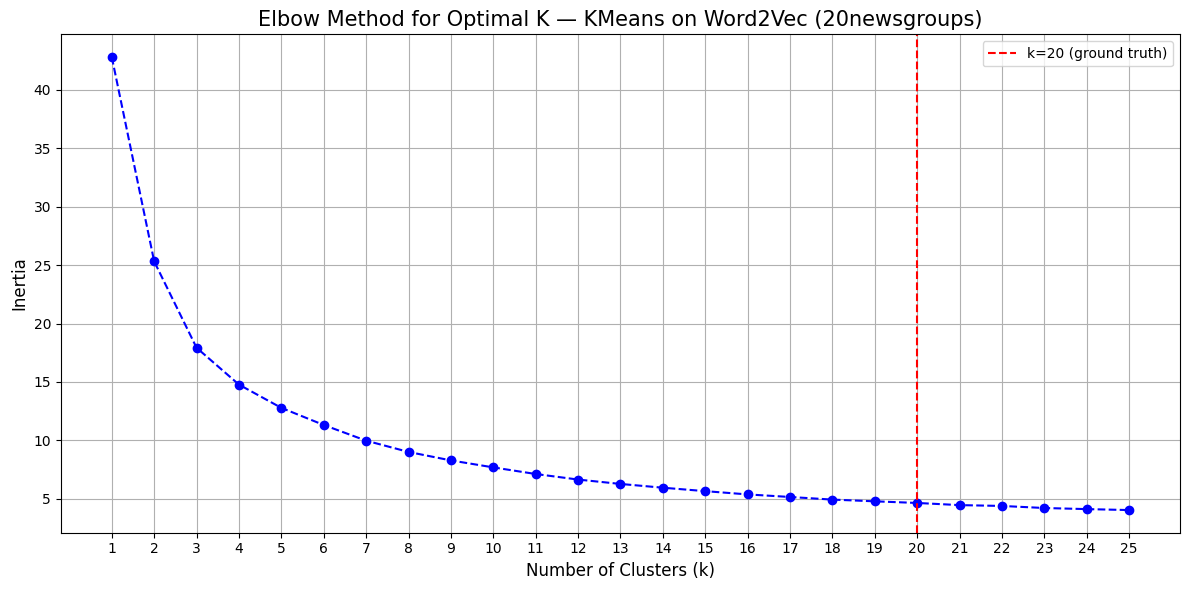

In [106]:
k_values = range(1, 26)
inertia_values = []

#Computing KMeans for each k and storing inertia
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    kmeans.fit(w2vec_data_20newsgroups)  
    inertia_values.append(kmeans.inertia_)
    print(f"k={k:2d} | Inertia: {kmeans.inertia_:.2f}") #printing inertia for each k

#Plotting the Elbow Curve
plt.figure(figsize=(12, 6))
plt.plot(k_values, inertia_values,
         marker='o',
         linestyle='--',
         color='b')

#Adding a vertical line at k=20 (ground truth number of categories)
plt.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='k=20 (ground truth)')

plt.title("Elbow Method for Optimal K — KMeans on Word2Vec (20newsgroups)", fontsize=15)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

###### Silhouette plot for 20newsgroups dataframe with Word2Vec without PCA to find optimal number of k 

k= 2 | Silhouette Score: 0.4530
k= 3 | Silhouette Score: 0.4421
k= 4 | Silhouette Score: 0.3262
k= 5 | Silhouette Score: 0.3239
k= 6 | Silhouette Score: 0.2848
k= 7 | Silhouette Score: 0.2943
k= 8 | Silhouette Score: 0.2872
k= 9 | Silhouette Score: 0.2799
k=10 | Silhouette Score: 0.2759
k=11 | Silhouette Score: 0.2768
k=12 | Silhouette Score: 0.2645
k=13 | Silhouette Score: 0.2679
k=14 | Silhouette Score: 0.2652
k=15 | Silhouette Score: 0.2539
k=16 | Silhouette Score: 0.2520
k=17 | Silhouette Score: 0.2543
k=18 | Silhouette Score: 0.2456
k=19 | Silhouette Score: 0.2458
k=20 | Silhouette Score: 0.2335
k=21 | Silhouette Score: 0.2390
k=22 | Silhouette Score: 0.2384
k=23 | Silhouette Score: 0.2247
k=24 | Silhouette Score: 0.2263
k=25 | Silhouette Score: 0.2215


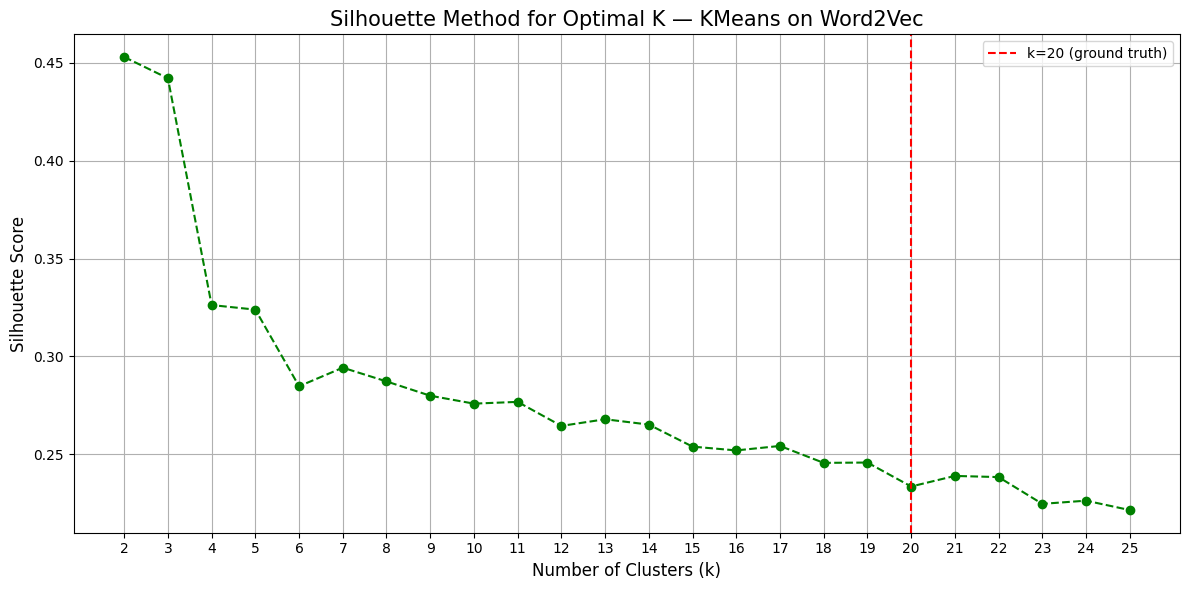

In [107]:
#Range of cluster numbers to evaluate (starting from k=2 up to 26)
k_values_sil = range(2, 26) 
silhouette_scores = []

#Computing KMeans for each k and storing the silhouette score
for k in k_values_sil:
    kmeans = KMeans(
        n_clusters=k, 
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    
    labels = kmeans.fit_predict(w2vec_data_20newsgroups)

    #Sampling 5000 to prevent memory overload
    score = silhouette_score(
        w2vec_data_20newsgroups, 
        labels, 
        sample_size=5000, 
        random_state=42
    )
    silhouette_scores.append(score)
    print(f"k={k:2d} | Silhouette Score: {score:.4f}")

#Plotting the Silhouette Score Curve
plt.figure(figsize=(12, 6))
plt.plot(k_values_sil, silhouette_scores, marker='o', linestyle='--', color='g')

#Adding a vertical line at k=20 (ground truth)
plt.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='k=20 (ground truth)')

plt.title("Silhouette Method for Optimal K — KMeans on Word2Vec", fontsize=15)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(k_values_sil)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

###### Clustering for 20newsgroups dataframe with Word2Vec without PCA for k=2 (optimal found in Silhouette plot)

In [108]:
#Extracting the cleaned, normalized Word2Vec matrix
w2vec_data_20newsgroups = clean_normalized_vectorizations["Word2Vec"]['matrix']

kmeans_2_w2ec_20newsgroups= KMeans(
    n_clusters=2,      #number of clusters
    init='k-means++',  #initialization method ('k-means++' because it is better for convergence)
    n_init=10,         #number of initializations to run
    max_iter=300,      #maximum iterations for a single run
    tol=1e-4,          #convergence threshold
    random_state=42    #seed for reproducibility
)
kmeans_2_w2ec_20newsgroups.fit(w2vec_data_20newsgroups)

#Clustering assignments
labels = kmeans_2_w2ec_20newsgroups.labels_

#Clustering centers
centroids = kmeans_2_w2ec_20newsgroups.cluster_centers_

#Calculating and printing the silhouette score
sil_score_2_20newsgroups = silhouette_score(
    w2vec_data_20newsgroups, 
    labels
)

#Mapping labels back to the original dataframe
#w2ec_mask_20newsgroups = clean_normalized_vectorizations["Word2Vec"]['mask']
#final_df_20newsgroups.loc[w2ec_mask_20newsgroups, 'kmeans_2_w2ec_label'] = labels

print(f"Matrix shape fitted: {w2vec_data_20newsgroups.shape}")
print(f"Unique clusters assigned: {len(set(labels))}")
print(f"Silhouette Score (k=2): {sil_score_2_20newsgroups:.4f}")

Matrix shape fitted: (1818, 200)
Unique clusters assigned: 2
Silhouette Score (k=2): 0.4530


###### Mapping the optimal labels for Word2Vec method back to the original dataframe for 20newsgroups

In [109]:
#Choosing as optimal k=2 found per silhouette plot but while knowing that is too far from the k=20  (ground truth labels)
#as the difference between silhouette scores are huge. This means that algorithm has Semantic Cohesion 
#as it finds two very broad, distinct semantic "islands". Therefore prioritizing internal cluster validity over external label matching

#Mapping labels back to the original dataframe
w2ec_mask_20newsgroups = clean_normalized_vectorizations["Word2Vec"]['mask']
final_df_20newsgroups.loc[w2ec_mask_20newsgroups, 'kmeans_2_w2ec_label'] = kmeans_2_w2ec_20newsgroups.labels_

###### Ground Truth Label Reference for 20newsgroups (integers conversion to category names) for 20newsgroups

In [110]:
print("GROUND TRUTH LABEL REFERENCE (integers → category names) ")
print("NOTE: These integers are ground truth IDs. KMeans cluster or other Clustering algorithm 0 ≠ category 0.\n")
category_mapping = dict(enumerate(labels_names_20newsgroups))
for num, name in category_mapping.items():
    print(f"  Ground Truth Label {num:2d} : {name}")

GROUND TRUTH LABEL REFERENCE (integers → category names) 
NOTE: These integers are ground truth IDs. KMeans cluster or other Clustering algorithm 0 ≠ category 0.

  Ground Truth Label  0 : alt.atheism
  Ground Truth Label  1 : comp.graphics
  Ground Truth Label  2 : comp.os.ms-windows.misc
  Ground Truth Label  3 : comp.sys.ibm.pc.hardware
  Ground Truth Label  4 : comp.sys.mac.hardware
  Ground Truth Label  5 : comp.windows.x
  Ground Truth Label  6 : misc.forsale
  Ground Truth Label  7 : rec.autos
  Ground Truth Label  8 : rec.motorcycles
  Ground Truth Label  9 : rec.sport.baseball
  Ground Truth Label 10 : rec.sport.hockey
  Ground Truth Label 11 : sci.crypt
  Ground Truth Label 12 : sci.electronics
  Ground Truth Label 13 : sci.med
  Ground Truth Label 14 : sci.space
  Ground Truth Label 15 : soc.religion.christian
  Ground Truth Label 16 : talk.politics.guns
  Ground Truth Label 17 : talk.politics.mideast
  Ground Truth Label 18 : talk.politics.misc
  Ground Truth Label 19 : tal

In [111]:
#Clustering size sanity check
print("Kmeans Cluster Distribution with Word2Vec (k=2)")
print(final_df_20newsgroups['kmeans_2_w2ec_label'].value_counts().sort_index())

#Crosstab — what matters is what's inside each cluster
contingency_matrix_w2ec = pd.crosstab(
    final_df_20newsgroups['category'],
    final_df_20newsgroups['kmeans_2_w2ec_label'],
    margins=True,
    margins_name='Total'
)
print("Contingency table")
print(contingency_matrix_w2ec)

#Normalized version (what % of each category ended up in each cluster)
contingency_normalized_w2ec = pd.crosstab(
    final_df_20newsgroups['category'],
    final_df_20newsgroups['kmeans_2_w2ec_label'],
    normalize='index'
).round(2)
print("Normalized version (% of each category per cluster)")
print(contingency_normalized_w2ec) 

Kmeans Cluster Distribution with Word2Vec (k=2)
kmeans_2_w2ec_label
0.0    1234
1.0     584
Name: count, dtype: int64
Contingency table
kmeans_2_w2ec_label        0.0  1.0  Total
category                                  
alt.atheism                 71    6     77
comp.graphics               27   67     94
comp.os.ms-windows.misc     20   75     95
comp.sys.ibm.pc.hardware    23   71     94
comp.sys.mac.hardware       34   59     93
comp.windows.x              16   81     97
misc.forsale                38   55     93
rec.autos                   76   18     94
rec.motorcycles             87    9     96
rec.sport.baseball          87    8     95
rec.sport.hockey            92    5     97
sci.crypt                   71   25     96
sci.electronics             54   40     94
sci.med                     81   11     92
sci.space                   72   21     93
soc.religion.christian      90   10    100
talk.politics.guns          86    5     91
talk.politics.mideast       80   11     91
talk

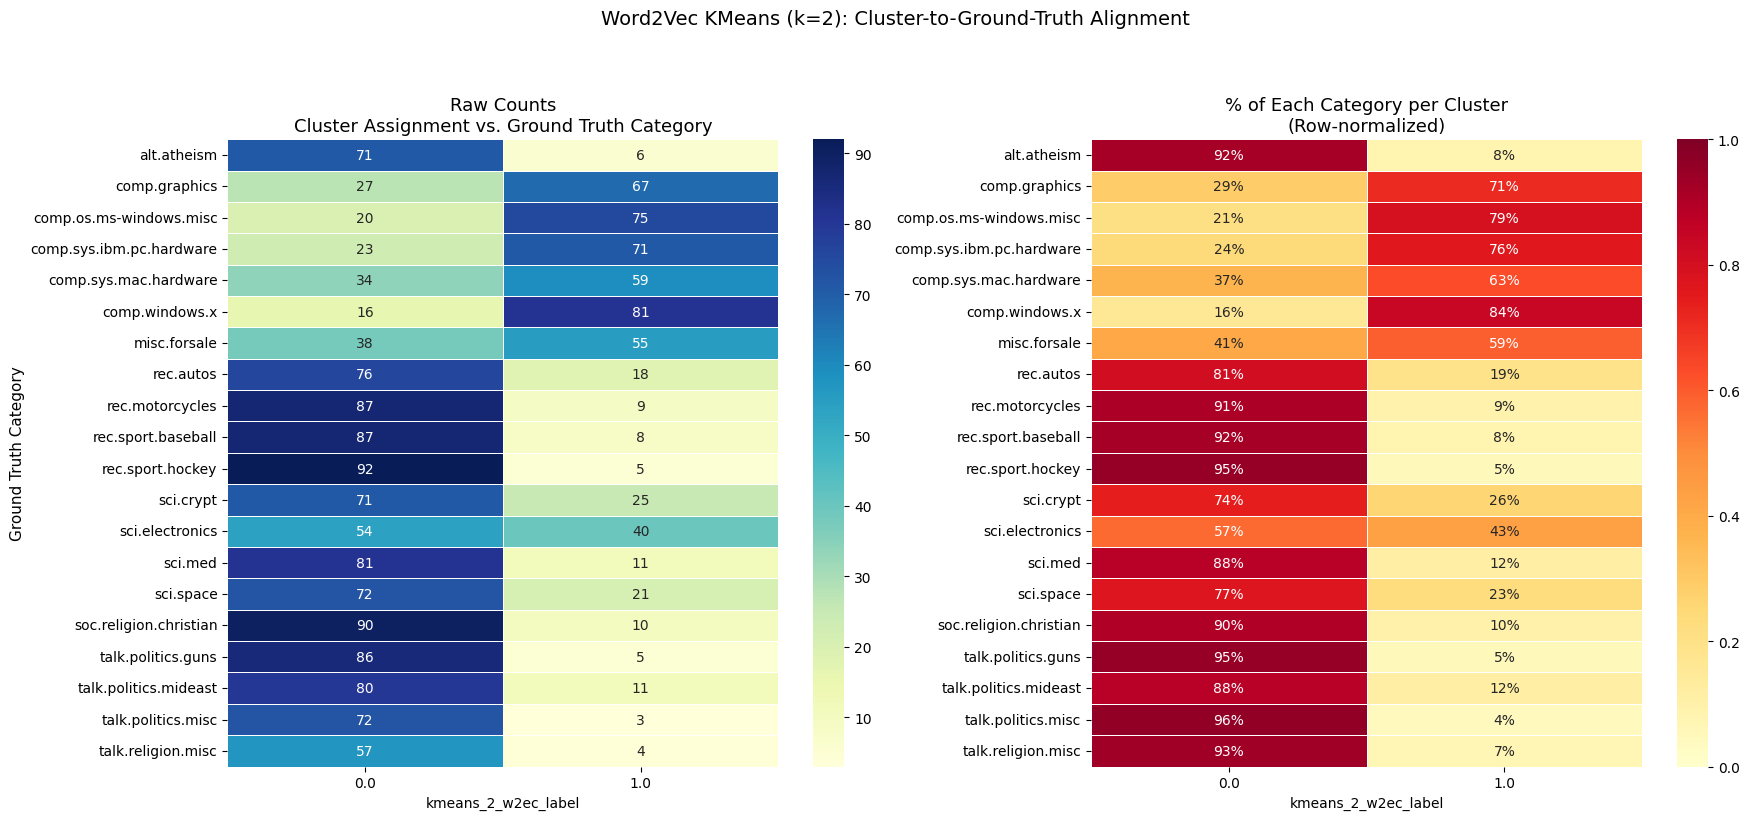

In [112]:
#Plotting both heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#Raw counts
sns.heatmap(
    contingency_matrix_w2ec.iloc[:-1, :-1],
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Raw Counts\nCluster Assignment vs. Ground Truth Category", fontsize=13)
axes[0].set_ylabel("Ground Truth Category", fontsize=11)

#Normalized
sns.heatmap(
    contingency_normalized_w2ec,
    annot=True,
    fmt='.0%',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_title("% of Each Category per Cluster\n(Row-normalized)", fontsize=13)
axes[1].set_ylabel("")

plt.suptitle(
    "Word2Vec KMeans (k=2): Cluster-to-Ground-Truth Alignment\n",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

In [113]:
#Dominant cluster per category
print("Dominant Cluster per Category")
print("(Which cluster captured the majority of each category's documents?)\n")
dominant_w2ec = contingency_normalized_w2ec.idxmax(axis=1).rename("dominant_cluster")
pct_w2ec      = contingency_normalized_w2ec.max(axis=1).rename("pct_in_dominant_cluster")
summary_w2ec  = pd.concat([dominant_w2ec, pct_w2ec], axis=1).sort_values("dominant_cluster")
print(summary_w2ec.to_string())

Dominant Cluster per Category
(Which cluster captured the majority of each category's documents?)

                          dominant_cluster  pct_in_dominant_cluster
category                                                           
alt.atheism                            0.0                     0.92
rec.autos                              0.0                     0.81
sci.med                                0.0                     0.88
sci.electronics                        0.0                     0.57
sci.crypt                              0.0                     0.74
rec.sport.hockey                       0.0                     0.95
rec.sport.baseball                     0.0                     0.92
rec.motorcycles                        0.0                     0.91
sci.space                              0.0                     0.77
soc.religion.christian                 0.0                     0.90
talk.politics.mideast                  0.0                     0.88
talk.politics.gun

In [114]:
#Pre-computing all cluster info in one pass
DOMINANCE_THRESHOLD = 0.60
n_clusters_w2ec = int(contingency_normalized_w2ec.columns.max()) + 1

cluster_info_w2ec = {}

for cluster_id in range(n_clusters_w2ec):
    col            = float(cluster_id)
    cluster_series = contingency_normalized_w2ec[col].sort_values(ascending=False)
    dominant       = cluster_series[cluster_series >= DOMINANCE_THRESHOLD]
    dominant_names = dominant.index.tolist()

    cluster_info_w2ec[cluster_id] = {
        'series'         : cluster_series,
        'dominant'       : dominant,
        'dominant_names' : dominant_names,
        'semantic_label' : get_semantic_label(dominant_names),  # already defined, not redefined
        'n_dominant'     : len(dominant),
        'top5'           : dominant.head(5)
    }

#Detailed per-cluster breakdown
print("-" * 60)
print("Clusters composition for Kmeans with optimal k=2 for Word2Vec")
print("-" * 60)

for cluster_id, info in cluster_info_w2ec.items():
    print(f"\nCluster {cluster_id} → Top categories (≥{DOMINANCE_THRESHOLD:.0%} of their docs landed here):")
    print(f"  {'Category':<35} {'% in Cluster ' + str(cluster_id)}")
    print(f"  {'-' * 50}")

    if info['top5'].empty:
        print(f"  No category sent ≥{DOMINANCE_THRESHOLD:.0%} of its docs here.")
    else:
        for category, pct in info['top5'].items():
            print(f"  {category:<35} {pct:.0%}")

    print(f"\n  → Auto-detected theme  : [{info['semantic_label']}]")
    print(f"  → Dominant categories  : {info['n_dominant']}")

#Summary Table
print(f"\n{'-' * 60}")
print("Verdict for Word2Vec with optimal k=2 for Kmeans")
print(f"{'-' * 60}")
print(f"  {'Cluster':<12} {'Theme':<40} {'# Dominant Categories'}")
print(f"  {'-' * 65}")

for cluster_id, info in cluster_info_w2ec.items():
    print(f"  Cluster {cluster_id:<4} {info['semantic_label']:<40} {info['n_dominant']}")

------------------------------------------------------------
Clusters composition for Kmeans with optimal k=2 for Word2Vec
------------------------------------------------------------

Cluster 0 → Top categories (≥60% of their docs landed here):
  Category                            % in Cluster 0
  --------------------------------------------------
  talk.politics.misc                  96%
  rec.sport.hockey                    95%
  talk.politics.guns                  95%
  talk.religion.misc                  93%
  rec.sport.baseball                  92%

  → Auto-detected theme  : [Recreation/Sports + Politics + Science + Religion/Society + Misc/Culture]
  → Dominant categories  : 13

Cluster 1 → Top categories (≥60% of their docs landed here):
  Category                            % in Cluster 1
  --------------------------------------------------
  comp.windows.x                      84%
  comp.os.ms-windows.misc             79%
  comp.sys.ibm.pc.hardware            76%
  comp.grap

***

###### Clustering for 20newsgroups dataframe without PCA

###### Clustering for 20newsgroups dataframe with FastText without PCA

###### Clustering for 20newsgroups dataframe withFastText without PCA for k=20 (number of the ground truth labels)

In [115]:
#Extracting the cleaned, normalized Word2Vec matrix
fasttext_data_20newsgroups = clean_normalized_vectorizations["FastText"]['matrix']

kmeans_20_20newsgroups = KMeans(
    n_clusters=20,     #number of clusters
    init='k-means++',  #initialization method ('k-means++' because it is better for convergence)
    n_init=10,         #number of initializations to run
    max_iter=300,      #maximum iterations for a single run
    tol=1e-4,          #convergence threshold
    random_state=42    #seed for reproducibility
)
kmeans_20_20newsgroups.fit(fasttext_data_20newsgroups)

#Clustering assignments
labels = kmeans_20_20newsgroups.labels_

#Clustering centers
centroids = kmeans_20_20newsgroups.cluster_centers_

#Calculating and printing the silhouette score
sil_score_20_20newsgroups = silhouette_score(
    fasttext_data_20newsgroups, 
    labels
)

#Mapping labels back to the original dataframe
#fasttext_mask_20newsgroups = clean_normalized_vectorizations["FastText"]['mask']
#final_df_20newsgroups.loc[fasttext_mask_20newsgroups, 'kmeans_2_fasttext_label'] = kmeans_2_20newsgroups.labels_

print(f"Matrix shape fitted: {fasttext_data_20newsgroups.shape}")
print(f"Unique clusters assigned: {len(set(labels))}")
print(f"Silhouette Score (k=20): {sil_score_20_20newsgroups:.4f}")

Matrix shape fitted: (1818, 200)
Unique clusters assigned: 20
Silhouette Score (k=20): 0.2478


###### Elbow plot for 20newsgroups dataframe with FastText without PCA to find potential elbow points for best k 

k= 1 | Inertia: 24.97
k= 2 | Inertia: 13.09
k= 3 | Inertia: 9.17
k= 4 | Inertia: 7.15
k= 5 | Inertia: 6.11
k= 6 | Inertia: 5.30
k= 7 | Inertia: 4.76
k= 8 | Inertia: 4.27
k= 9 | Inertia: 3.97
k=10 | Inertia: 3.68
k=11 | Inertia: 3.48
k=12 | Inertia: 3.30
k=13 | Inertia: 3.09
k=14 | Inertia: 2.97
k=15 | Inertia: 2.80
k=16 | Inertia: 2.65
k=17 | Inertia: 2.54
k=18 | Inertia: 2.45
k=19 | Inertia: 2.31
k=20 | Inertia: 2.23
k=21 | Inertia: 2.14
k=22 | Inertia: 2.08
k=23 | Inertia: 2.01
k=24 | Inertia: 1.96
k=25 | Inertia: 1.90


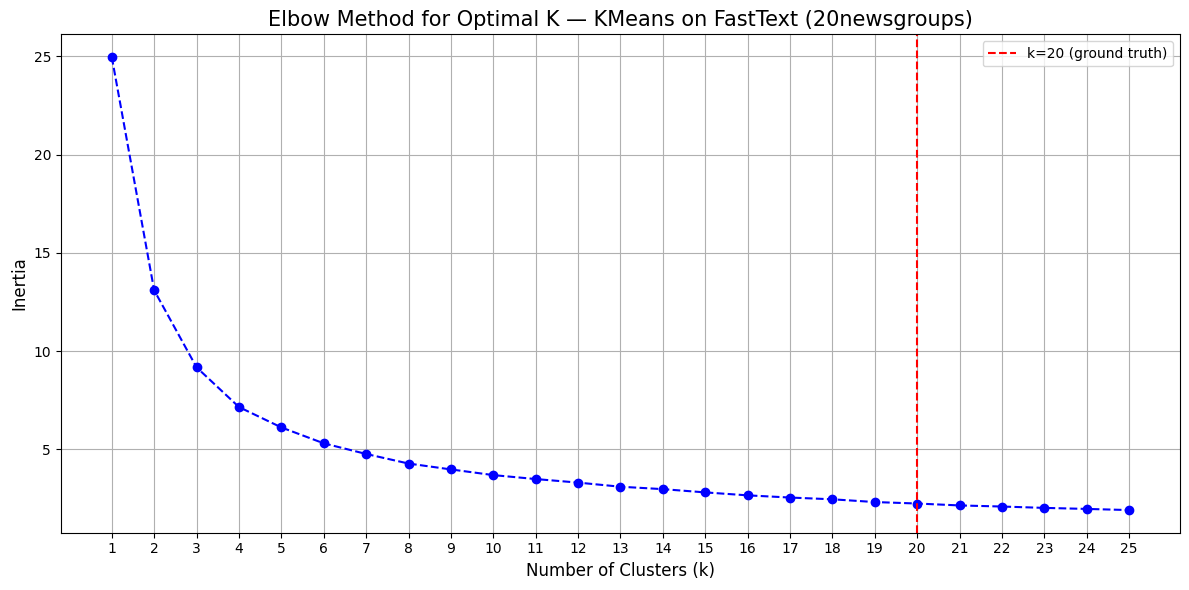

In [116]:
k_values = range(1, 26)
inertia_values = []

#Computing KMeans for each k and storing inertia
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    kmeans.fit(fasttext_data_20newsgroups)  
    inertia_values.append(kmeans.inertia_)
    print(f"k={k:2d} | Inertia: {kmeans.inertia_:.2f}") #printing inertia for each k

#Plotting the Elbow Curve
plt.figure(figsize=(12, 6))
plt.plot(k_values, inertia_values,
         marker='o',
         linestyle='--',
         color='b')

#Adding a vertical line at k=20 (ground truth number of categories)
plt.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='k=20 (ground truth)')

plt.title("Elbow Method for Optimal K — KMeans on FastText (20newsgroups)", fontsize=15)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

###### Silhouette plot for 20newsgroups dataframe with FastText without PCA to find optimal number of k 

k= 2 | Silhouette Score: 0.4774
k= 3 | Silhouette Score: 0.3993
k= 4 | Silhouette Score: 0.3583
k= 5 | Silhouette Score: 0.3052
k= 6 | Silhouette Score: 0.2973
k= 7 | Silhouette Score: 0.3025
k= 8 | Silhouette Score: 0.2916
k= 9 | Silhouette Score: 0.2777
k=10 | Silhouette Score: 0.2733
k=11 | Silhouette Score: 0.2779
k=12 | Silhouette Score: 0.2725
k=13 | Silhouette Score: 0.2708
k=14 | Silhouette Score: 0.2504
k=15 | Silhouette Score: 0.2548
k=16 | Silhouette Score: 0.2564
k=17 | Silhouette Score: 0.2456
k=18 | Silhouette Score: 0.2498
k=19 | Silhouette Score: 0.2537
k=20 | Silhouette Score: 0.2478
k=21 | Silhouette Score: 0.2558
k=22 | Silhouette Score: 0.2509
k=23 | Silhouette Score: 0.2465
k=24 | Silhouette Score: 0.2431
k=25 | Silhouette Score: 0.2411


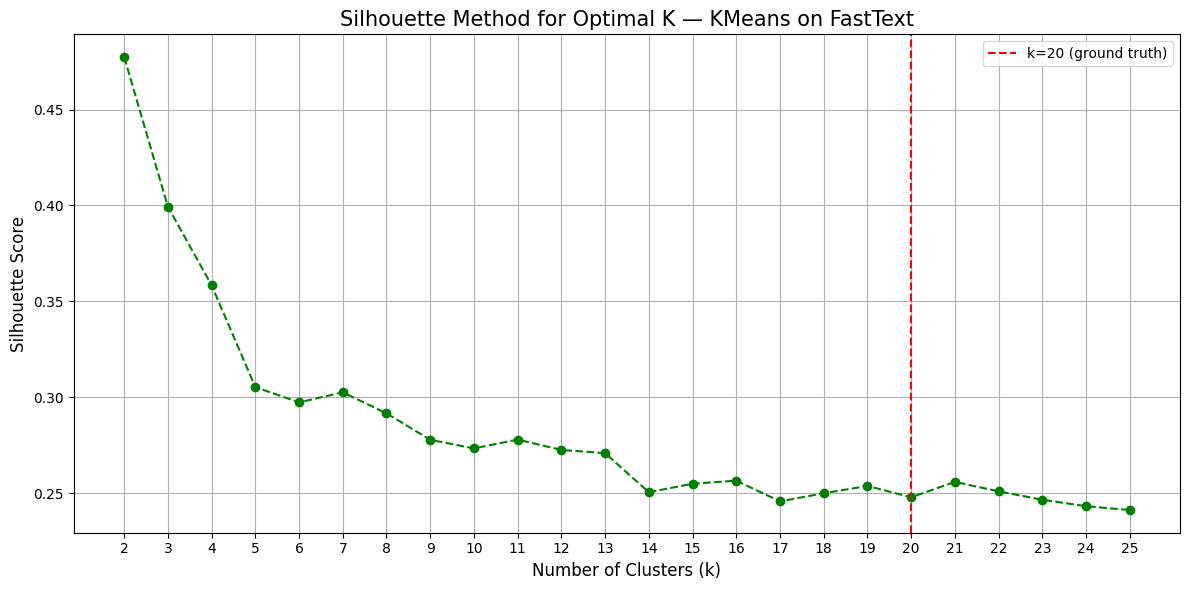

In [117]:
#Range of cluster numbers to evaluate (starting from k=2 up to 26)
k_values_sil = range(2, 26) 
silhouette_scores = []

#Computing KMeans for each k and storing the silhouette score
for k in k_values_sil:
    kmeans = KMeans(
        n_clusters=k, 
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    
    labels = kmeans.fit_predict(fasttext_data_20newsgroups)

    #Sampling 5000 to prevent memory overload
    score = silhouette_score(
        fasttext_data_20newsgroups, 
        labels, 
        sample_size=5000, 
        random_state=42
    )
    silhouette_scores.append(score)
    print(f"k={k:2d} | Silhouette Score: {score:.4f}")

#Plotting the Silhouette Score Curve
plt.figure(figsize=(12, 6))
plt.plot(k_values_sil, silhouette_scores, marker='o', linestyle='--', color='g')

#Adding a vertical line at k=20 (ground truth)
plt.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='k=20 (ground truth)')

plt.title("Silhouette Method for Optimal K — KMeans on FastText", fontsize=15)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(k_values_sil)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

###### Clustering for 20newsgroups dataframe with FastText without PCA for k=2 (optimal found in Silhouette plot)

In [118]:
kmeans_2_fasttext_20newsgroups  = KMeans(
    n_clusters=2,      #number of clusters
    init='k-means++',  #initialization method ('k-means++' because it is better for convergence)
    n_init=10,         #number of initializations to run
    max_iter=300,      #maximum iterations for a single run
    tol=1e-4,          #convergence threshold
    random_state=42    #seed for reproducibility
)
kmeans_2_fasttext_20newsgroups.fit(fasttext_data_20newsgroups)

#Clustering assignments
labels = kmeans_2_fasttext_20newsgroups.labels_

#Clustering centers
centroids = kmeans_2_fasttext_20newsgroups.cluster_centers_

#Calculating and printing the silhouette score
sil_score_2_20newsgroups = silhouette_score(
    fasttext_data_20newsgroups, 
    labels
)

#Mapping labels back to the original dataframe
#fasttext_mask_20newsgroups = clean_normalized_vectorizations["FastText"]['mask']
#final_df_20newsgroups.loc[fasttext_mask_20newsgroups, 'kmeans_2_fasttext_label'] = \
#kmeans_2_fasttext_20newsgroups.labels_

print(f"Matrix shape fitted: {fasttext_data_20newsgroups.shape}")
print(f"Unique clusters assigned: {len(set(labels))}")
print(f"Silhouette Score (k=2): {sil_score_2_20newsgroups:.4f}")

Matrix shape fitted: (1818, 200)
Unique clusters assigned: 2
Silhouette Score (k=2): 0.4774


###### Mapping the optimal labels for FastText method back to the original dataframe for 20newsgroups

In [119]:
#Choosing as optimal k=2 found per silhouette plot but while knowing that is too far from the k=20  (ground truth labels)
#as the difference between silhouette scores are huge. This means that algorithm has Semantic Cohesion 
#as it finds two very broad, distinct semantic "islands". Therefore prioritizing internal cluster validity over external label matching

#Mapping labels back to the original dataframe

fasttext_mask_20newsgroups = clean_normalized_vectorizations["FastText"]['mask']
final_df_20newsgroups.loc[fasttext_mask_20newsgroups, 'kmeans_2_fasttext_label'] = \
    kmeans_2_fasttext_20newsgroups.labels_

###### Ground Truth Label Reference for 20newsgroups (integers conversion to category names) for 20newsgroups

In [120]:
print("GROUND TRUTH LABEL REFERENCE (integers → category names) ")
print("NOTE: These integers are ground truth IDs. KMeans cluster or other Clustering algorithm 0 ≠ category 0.\n")
category_mapping = dict(enumerate(labels_names_20newsgroups))
for num, name in category_mapping.items():
    print(f"  Ground Truth Label {num:2d} : {name}")

GROUND TRUTH LABEL REFERENCE (integers → category names) 
NOTE: These integers are ground truth IDs. KMeans cluster or other Clustering algorithm 0 ≠ category 0.

  Ground Truth Label  0 : alt.atheism
  Ground Truth Label  1 : comp.graphics
  Ground Truth Label  2 : comp.os.ms-windows.misc
  Ground Truth Label  3 : comp.sys.ibm.pc.hardware
  Ground Truth Label  4 : comp.sys.mac.hardware
  Ground Truth Label  5 : comp.windows.x
  Ground Truth Label  6 : misc.forsale
  Ground Truth Label  7 : rec.autos
  Ground Truth Label  8 : rec.motorcycles
  Ground Truth Label  9 : rec.sport.baseball
  Ground Truth Label 10 : rec.sport.hockey
  Ground Truth Label 11 : sci.crypt
  Ground Truth Label 12 : sci.electronics
  Ground Truth Label 13 : sci.med
  Ground Truth Label 14 : sci.space
  Ground Truth Label 15 : soc.religion.christian
  Ground Truth Label 16 : talk.politics.guns
  Ground Truth Label 17 : talk.politics.mideast
  Ground Truth Label 18 : talk.politics.misc
  Ground Truth Label 19 : tal

In [121]:
#Clustering size sanity check
print("Kmeans Cluster Distribution with FastText (k=2)")
print(final_df_20newsgroups['kmeans_2_fasttext_label'].value_counts().sort_index())

#Crosstabing — what matters is what's inside each cluster
contingency_matrix_fasttext = pd.crosstab(
    final_df_20newsgroups['category'],
    final_df_20newsgroups['kmeans_2_fasttext_label'],
    margins=True,
    margins_name='Total'
)
print("Contingency table")
print(contingency_matrix_fasttext)

#Normalized version (what % of each category ended up in each cluster)
contingency_normalized_fasttext = pd.crosstab(
    final_df_20newsgroups['category'],
    final_df_20newsgroups['kmeans_2_fasttext_label'],
    normalize='index'
).round(2)
print("Normalized version (% of each category per cluster)")
print(contingency_normalized_fasttext)

Kmeans Cluster Distribution with FastText (k=2)
kmeans_2_fasttext_label
0.0    1290
1.0     528
Name: count, dtype: int64
Contingency table
kmeans_2_fasttext_label    0.0  1.0  Total
category                                  
alt.atheism                 68    9     77
comp.graphics               29   65     94
comp.os.ms-windows.misc     26   69     95
comp.sys.ibm.pc.hardware    45   49     94
comp.sys.mac.hardware       45   48     93
comp.windows.x              23   74     97
misc.forsale                45   48     93
rec.autos                   77   17     94
rec.motorcycles             86   10     96
rec.sport.baseball          89    6     95
rec.sport.hockey            93    4     97
sci.crypt                   68   28     96
sci.electronics             63   31     94
sci.med                     78   14     92
sci.space                   75   18     93
soc.religion.christian      93    7    100
talk.politics.guns          85    6     91
talk.politics.mideast       77   14     91


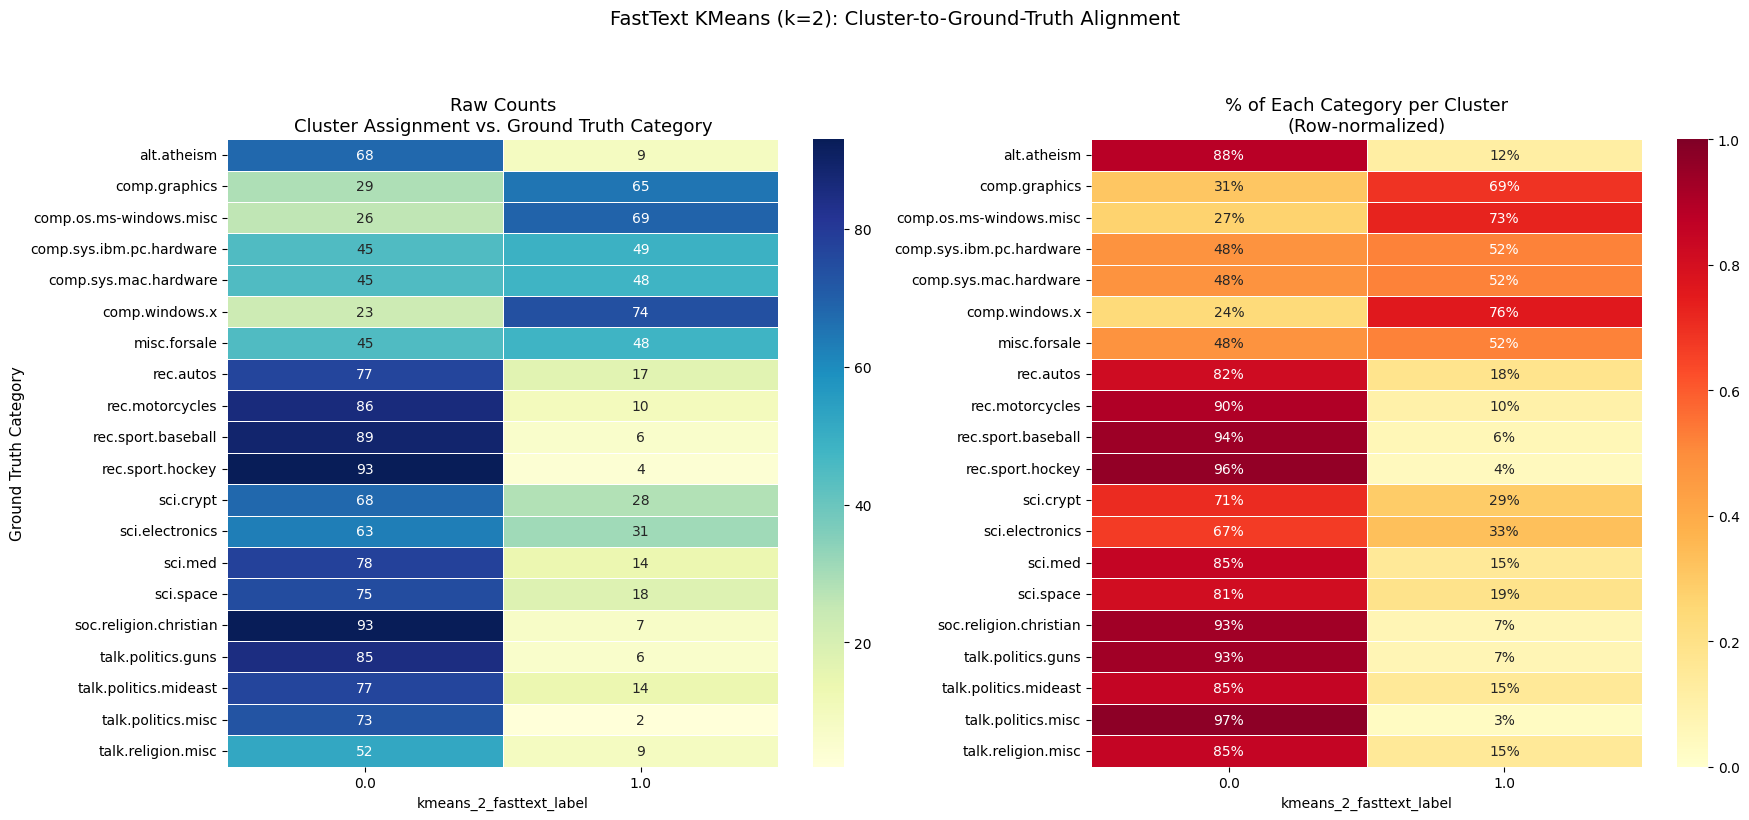

In [122]:
#Plotting both heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#Raw counts
sns.heatmap(
    contingency_matrix_fasttext.iloc[:-1, :-1],
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Raw Counts\nCluster Assignment vs. Ground Truth Category", fontsize=13)
axes[0].set_ylabel("Ground Truth Category", fontsize=11)

#Normalized
sns.heatmap(
    contingency_normalized_fasttext,
    annot=True,
    fmt='.0%',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_title("% of Each Category per Cluster\n(Row-normalized)", fontsize=13)
axes[1].set_ylabel("")

plt.suptitle(
    "FastText KMeans (k=2): Cluster-to-Ground-Truth Alignment\n",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

In [123]:
#Dominant cluster per category
print("Dominant Cluster per Category")
print("(Which cluster captured the majority of each category's documents?)\n")
dominant_fasttext = contingency_normalized_fasttext.idxmax(axis=1).rename("dominant_cluster")
pct_fasttext      = contingency_normalized_fasttext.max(axis=1).rename("pct_in_dominant_cluster")
summary_fasttext  = pd.concat([dominant_fasttext, pct_fasttext], axis=1).sort_values("dominant_cluster")
print(summary_fasttext.to_string())

Dominant Cluster per Category
(Which cluster captured the majority of each category's documents?)

                          dominant_cluster  pct_in_dominant_cluster
category                                                           
alt.atheism                            0.0                     0.88
rec.autos                              0.0                     0.82
sci.med                                0.0                     0.85
sci.electronics                        0.0                     0.67
sci.crypt                              0.0                     0.71
rec.sport.hockey                       0.0                     0.96
rec.sport.baseball                     0.0                     0.94
rec.motorcycles                        0.0                     0.90
sci.space                              0.0                     0.81
soc.religion.christian                 0.0                     0.93
talk.politics.mideast                  0.0                     0.85
talk.politics.gun

In [124]:
#Pre-computing all cluster info in one pass
DOMINANCE_THRESHOLD = 0.60
n_clusters_fasttext = int(contingency_normalized_fasttext.columns.max()) + 1

cluster_info_fasttext = {}

for cluster_id in range(n_clusters_fasttext):
    col            = float(cluster_id)
    cluster_series = contingency_normalized_fasttext[col].sort_values(ascending=False)
    dominant       = cluster_series[cluster_series >= DOMINANCE_THRESHOLD]
    dominant_names = dominant.index.tolist()

    cluster_info_fasttext[cluster_id] = {
        'series'         : cluster_series,
        'dominant'       : dominant,
        'dominant_names' : dominant_names,
        'semantic_label' : get_semantic_label(dominant_names),
        'n_dominant'     : len(dominant),
        'top5'           : dominant.head(5)
    }

#Detailed per-cluster breakdown
print("-" * 60)
print("Clusters composition for Kmeans with optimal k=2 for FastText")
print("-" * 60)

for cluster_id, info in cluster_info_fasttext.items():
    print(f"\nCluster {cluster_id} → Top categories (≥{DOMINANCE_THRESHOLD:.0%} of their docs landed here):")
    print(f"  {'Category':<35} {'% in Cluster ' + str(cluster_id)}")
    print(f"  {'-' * 50}")

    if info['top5'].empty:
        print(f"  No category sent ≥{DOMINANCE_THRESHOLD:.0%} of its docs here.")
    else:
        for category, pct in info['top5'].items():
            print(f"  {category:<35} {pct:.0%}")

    print(f"\n  → Auto-detected theme  : [{info['semantic_label']}]")
    print(f"  → Dominant categories  : {info['n_dominant']}")

# Summary Table
print(f"\n{'-' * 60}")
print("Verdict for FastText with optimal k=2 for Kmeans")
print(f"{'-' * 60}")
print(f"  {'Cluster':<12} {'Theme':<40} {'# Dominant Categories'}")
print(f"  {'-' * 65}")

for cluster_id, info in cluster_info_fasttext.items():
    print(f"  Cluster {cluster_id:<4} {info['semantic_label']:<40} {info['n_dominant']}")

------------------------------------------------------------
Clusters composition for Kmeans with optimal k=2 for FastText
------------------------------------------------------------

Cluster 0 → Top categories (≥60% of their docs landed here):
  Category                            % in Cluster 0
  --------------------------------------------------
  talk.politics.misc                  97%
  rec.sport.hockey                    96%
  rec.sport.baseball                  94%
  soc.religion.christian              93%
  talk.politics.guns                  93%

  → Auto-detected theme  : [Recreation/Sports + Politics + Science + Religion/Society + Misc/Culture]
  → Dominant categories  : 14

Cluster 1 → Top categories (≥60% of their docs landed here):
  Category                            % in Cluster 1
  --------------------------------------------------
  comp.windows.x                      76%
  comp.os.ms-windows.misc             73%
  comp.graphics                       69%

  → Auto-d

###### Evaluating & Interpreting Results for 20newsgroups KMeans (Best Models per Vectorization Method)

-------------------------------------------------------
  CLUSTERING EVALUATION — 20newsgroups (Best Models)
-------------------------------------------------------

───────────────────────────────────────────────────────
  KMeans | TF-IDF | Best k=18
───────────────────────────────────────────────────────
  NMI (Normalized Mutual Info)  : 0.3020
  ARI (Adjusted Rand Index)     : 0.1036
  AMI (Adjusted Mutual Info)    : 0.2774

───────────────────────────────────────────────────────
  KMeans | Word2Vec | Best k=2
───────────────────────────────────────────────────────
  NMI (Normalized Mutual Info)  : 0.1086
  ARI (Adjusted Rand Index)     : 0.0281
  AMI (Adjusted Mutual Info)    : 0.1060

───────────────────────────────────────────────────────
  KMeans | FastText | Best k=2
───────────────────────────────────────────────────────
  NMI (Normalized Mutual Info)  : 0.0819
  ARI (Adjusted Rand Index)     : 0.0194
  AMI (Adjusted Mutual Info)    : 0.0792

----------------------------------

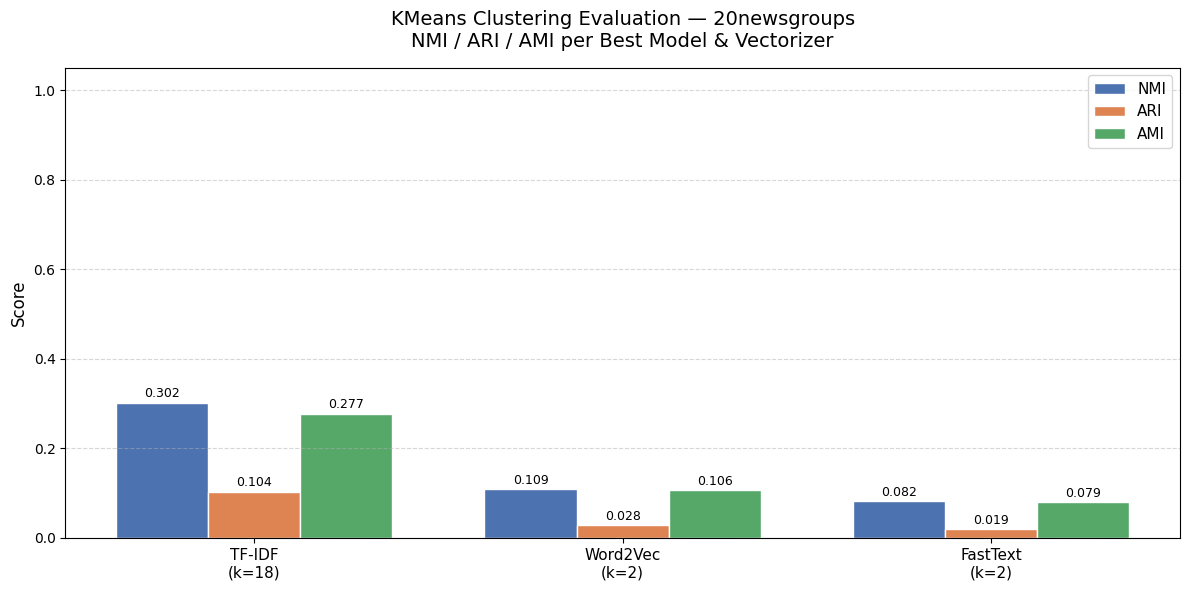

In [125]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score

#Getting ground truth labels aligned with each vectorizer mask

#Ground truth for TF-IDF (uses tfidf_mask)
gt_tfidf = final_df_20newsgroups.loc[
    clean_normalized_vectorizations["TF-IDF"]['mask'],
    'ground_truth_label'
].values

#Ground truth for Word2Vec (uses w2ec_mask)
gt_w2ec = final_df_20newsgroups.loc[
    clean_normalized_vectorizations["Word2Vec"]['mask'],
    'ground_truth_label'
].values

#Ground truth for FastText (uses fasttext_mask)
gt_fasttext = final_df_20newsgroups.loc[
    clean_normalized_vectorizations["FastText"]['mask'],
    'ground_truth_label'
].values

#Getting predicted labels from best models of Kmeans for each vectorization method
#pred_tfidf_18   = kmeans_18_20newsgroups.labels_   # TF-IDF   best k=18
#pred_w2ec_2     = kmeans_2_20newsgroups.labels_    # Word2Vec  best k=2  ← will be overwritten warning: see note below
#pred_fasttext_2 = kmeans_2_20newsgroups.labels_    # FastText  best k=2

# NOTE: kmeans_2_20newsgroups was last fitted on FastText data.
# For Word2Vec we need to refit or store labels earlier.
# Best practice — store labels explicitly right after each fit:
# (already done above via .labels_ from the correct model object,
#  but since both Word2Vec and FastText share the same variable name
#  kmeans_2_20newsgroups, we should use the mask-filtered column instead)

#Pulling predicted labels directly from the dataframe column that is already mapped for each vectorization method
pred_tfidf_18   = final_df_20newsgroups.loc[
    clean_normalized_vectorizations["TF-IDF"]['mask'],
    'kmeans_18_tfidf_label'
].values.astype(int)

pred_w2ec_2     = final_df_20newsgroups.loc[
    clean_normalized_vectorizations["Word2Vec"]['mask'],
    'kmeans_2_w2ec_label'
].values.astype(int)

pred_fasttext_2 = final_df_20newsgroups.loc[
    clean_normalized_vectorizations["FastText"]['mask'],
    'kmeans_2_fasttext_label'
].values.astype(int)

#Computing NMI, ARI, AMI for each best model ──────────────────────
def compute_metrics(ground_truth, predicted, model_name, vectorizer, best_k):
    """Computes NMI, ARI, AMI and returns a result dict."""
    nmi = normalized_mutual_info_score(ground_truth, predicted)
    ari = adjusted_rand_score(ground_truth, predicted)
    ami = adjusted_mutual_info_score(ground_truth, predicted)

    print(f"\n{'─' * 55}")
    print(f"  {model_name} | {vectorizer} | Best k={best_k}")
    print(f"{'─' * 55}")
    print(f"  NMI (Normalized Mutual Info)  : {nmi:.4f}")
    print(f"  ARI (Adjusted Rand Index)     : {ari:.4f}")
    print(f"  AMI (Adjusted Mutual Info)    : {ami:.4f}")

    return {
        'Model'      : model_name,
        'Vectorizer' : vectorizer,
        'Best_k'     : best_k,
        'NMI'        : round(nmi, 4),
        'ARI'        : round(ari, 4),
        'AMI'        : round(ami, 4)
    }

print("-" * 55)
print("  CLUSTERING EVALUATION — 20newsgroups (Best Models)")
print("-" * 55)

results = []

results.append(compute_metrics(gt_tfidf,   pred_tfidf_18,   'KMeans', 'TF-IDF',   18))
results.append(compute_metrics(gt_w2ec,    pred_w2ec_2,     'KMeans', 'Word2Vec',  2))
results.append(compute_metrics(gt_fasttext, pred_fasttext_2, 'KMeans', 'FastText',  2))

#Storing results in a DataFrame 
results_df_20newsgroups = pd.DataFrame(results)
results_df_20newsgroups['Dataset'] = '20newsgroups'

print(f"\n{'-' * 55}")
print("  RESULTS SUMMARY TABLE")
print(f"{'-' * 55}")
print(results_df_20newsgroups.to_string(index=False))

#Bar plot comparing NMI, ARI, AMI across best models of Kmeans for 20newsgroups
metrics     = ['NMI', 'ARI', 'AMI']
models      = results_df_20newsgroups['Vectorizer'].tolist()
x           = np.arange(len(models))
bar_width   = 0.25
colors      = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(
        x + i * bar_width,
        results_df_20newsgroups[metric],
        width=bar_width,
        label=metric,
        color=color,
        edgecolor='white'
    )
    #Adding value labels on top of each bar
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha='center', va='bottom', fontsize=9
        )

ax.set_xticks(x + bar_width)
ax.set_xticklabels(
    [f"{row['Vectorizer']}\n(k={row['Best_k']})" for _, row in results_df_20newsgroups.iterrows()],
    fontsize=11
)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title(
    "KMeans Clustering Evaluation — 20newsgroups\nNMI / ARI / AMI per Best Model & Vectorizer",
    fontsize=14, pad=15
)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###### Clustering for 20newsgroups dataframe with PCA

###### Clustering for 20newsgroups dataframe with TF-IDF with PCA

###### Clustering for 20newsgroups dataframe with TF-IDF with PCA for k=20 (number of the ground truth labels)

###### Elbow plot for 20newsgroups dataframe with TF-IDF with PCA to find potential elbow points for best k 

###### Silhouette plot for 20newsgroups dataframe with TF-IDF with PCA to find optimal number of k 